In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense,LSTM, Dropout,Input, Concatenate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import math




# Este dataframe contiene la cantidad Viajes realizados aperturados por tipo de pasaje, por Estacion, por linea , por hora y por dia en el año 2014. 

**CARGA DEL DATASET ORIGINAL PROPORCIONADO POR EL CLIENTE**

In [2]:
df=pd.read_csv("historico_2014.csv", encoding='latin1')

**EXPLORACION Y COMPRENDIMIENTO DEL DATASET**

In [3]:
df.head(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ID_ESTACION,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL
0,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_E_TURN02,20.0,FLORIDA,7.0,NaN,NaN,7
1,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_E_TURN03,20.0,FLORIDA,9.0,NaN,NaN,9
2,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_O_TURN01,20.0,FLORIDA,14.0,NaN,2.0,16
3,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_O_TURN02,20.0,FLORIDA,18.0,NaN,NaN,18
4,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_O_TURN03,20.0,FLORIDA,12.0,NaN,NaN,12


In [4]:
df.tail(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ID_ESTACION,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL
10857239,2014-04-09,09:15:00,09:29:00,B,LINEA_B_LACROZE_S_TURN01,66.0,FEDERICO LACROZE,11.0,NaN,1.0,12
10857240,2014-04-09,09:15:00,09:29:00,B,LINEA_B_LACROZE_S_TURN02,66.0,FEDERICO LACROZE,5.0,NaN,NaN,5
10857241,2014-04-09,09:15:00,09:29:00,B,LINEA_B_LACROZE_S_TURN03,66.0,FEDERICO LACROZE,8.0,NaN,3.0,11
10857242,2014-04-09,09:15:00,09:29:00,B,LINEA_B_LACROZE_S_TURN04,66.0,FEDERICO LACROZE,6.0,NaN,NaN,6
10857243,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_E_TURN01,20.0,FLORIDA,3.0,NaN,NaN,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10857244 entries, 0 to 10857243
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   FECHA            object 
 1   DESDE            object 
 2   HASTA            object 
 3   LINEA            object 
 4   MOLINETE         object 
 5   ID_ESTACION      float64
 6   ESTACION         object 
 7   PAX_PAGO         float64
 8   PAX_PASES_PAGOS  float64
 9   PAX_FRANQ        float64
 10  PAX_TOTAL        int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 911.2+ MB


In [6]:
df.describe()


,ID_ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL
count,1.049240e+07,1.066628e+07,2.089344e+06,6.340512e+06,1.085724e+07
mean,4.243905e+01,2.263576e+01,8.296695e-01,1.895142e+00,2.350409e+01
std,2.479389e+01,2.697639e+01,1.017306e+00,1.957406e+00,2.772856e+01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+01,4.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00
50%,4.000000e+01,1.300000e+01,1.000000e+00,1.000000e+00,1.400000e+01
75%,6.600000e+01,3.100000e+01,1.000000e+00,2.000000e+00,3.300000e+01
max,8.300000e+01,1.453700e+04,6.500000e+01,9.900000e+01,1.453800e+04


**En esta instancia se puede observar que en la feature PAX_PAGO existe un OUTLIER. Lo podemos ver en el valor maximo**

- El siguiente codigo, cuenta cuántos valores faltantes (NaN) hay en total en todo el DataFrame df.

In [7]:
print(df.isna().sum().sum())

13840437


- El siguiente código muestra cuántos valores nulos (vacíos o NaN) hay en cada columna del DataFrame df.

In [8]:
df.isnull().sum()

FECHA                    0
DESDE                    0
HASTA                    0
LINEA                    0
MOLINETE                 0
ID_ESTACION         364840
ESTACION                 0
PAX_PAGO            190965
PAX_PASES_PAGOS    8767900
PAX_FRANQ          4516732
PAX_TOTAL                0
dtype: int64

- El siguiente código cuenta cuántas filas duplicadas hay en el DataFrame df.

In [9]:
df.duplicated().sum()


0

 - El siguiente código identifica qué filas están repetidas (comparando cada fila completa con las anteriores).

In [10]:
duplicados = df[df.duplicated()]
print(duplicados.head(10))

Empty DataFrame
Columns: [FECHA, DESDE, HASTA, LINEA, MOLINETE, ID_ESTACION, ESTACION, PAX_PAGO, PAX_PASES_PAGOS, PAX_FRANQ, PAX_TOTAL]
Index: []


- El siguiente código identifica las columnas del DataFrame duplicados en las que no todos los valores son únicos, es decir, donde hay al menos un valor repetido.
- Esto ayuda a entender qué campos están aportando a la duplicación.

In [11]:
# Obtiene las columnas que contienen valores duplicados
columnas_duplicadas = duplicados.columns[duplicados.nunique() != duplicados.shape[0]]
print(columnas_duplicadas)  # Muestra las columnas que contienen valores duplicados


Index([], dtype='object')


- El siguiente codgo, muestra el tipo de dato de cada columna del DataFrame df.
- •	Por ejemplo: int64 para enteros, float64 para decimales, object para texto, datetime64 para fechas, etc.

- Es útil para verificar que los datos estén correctamente tipados antes de analizarlos o procesarlos.

In [12]:
df.dtypes

FECHA               object
DESDE               object
HASTA               object
LINEA               object
MOLINETE            object
ID_ESTACION        float64
ESTACION            object
PAX_PAGO           float64
PAX_PASES_PAGOS    float64
PAX_FRANQ          float64
PAX_TOTAL            int64
dtype: object

In [13]:
df.columns


Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ID_ESTACION',
       'ESTACION', 'PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL'],
      dtype='object')

- El siguiente codigo, selecciona 5 filas aleatorias del DataFrame df.
1. Es útil para explorar datos de manera rápida sin necesidad de revisar todo el conjunto.
2. Ideal para verificar la estructura general y valores típicos del dataset.

- Muestra una pequeña muestra aleatoria de 5 registros del DataFrame.

In [14]:
df.sample(5)



,FECHA,DESDE,HASTA,LINEA,MOLINETE,ID_ESTACION,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL
6328859,2014-11-05,16:30:00,16:44:00,C,LINEA_C_INDEPEN_TURN03,18.0,INDEPENDENCIA,19.0,2.0,3.0,24
1983523,2014-06-03,11:30:00,11:44:00,D,LINEA_D_CONGRESOTUC_N_TURN03,71.0,CONGRESO DE TUCUMAN,34.0,NaN,1.0,35
1687838,2014-06-30,08:00:00,08:14:00,A,LINEA_A_CONGRESO_S_ASC01,35.0,CONGRESO,2.0,NaN,NaN,2
9249710,2014-02-26,15:45:00,15:59:00,B,LINEA_B_PASTEUR_S_TURN03,24.0,PASTEUR,40.0,NaN,4.0,44
5814927,2014-11-02,11:30:00,11:44:00,B,LINEA_B_GALLARDO_N_TURN03,28.0,ANGEL GALLARDO,0.0,NaN,0.0,0


**NORMALIZACION, LIMPIEZA Y PREPARACION DEL NUEVO DATASET PARA UTILIZAR EN LOS ANALISIS**

In [15]:
#CREO UN NUEVO DATAFRAME PARA REALIZAR LOS ANALISIS EXPLORATORIO Y NO USAR EL ORIGINAL
dfanalisis = df

- El siguiente codigo, convierte todos los nombres de columnas del DataFrame "dfanalisis" a mayúsculas.

- Esto evita errores por diferencias en el formato de nombres al trabajar con columnas en otras operaciones o comparaciones.

In [16]:
#CONVERSION NOMBRES DE COLUMNAS A MAYUSCULAS POR LAS DUDAS HAYA ALGUNA EN MINUSCULA.
#Me aseguro de que todas esten en mayusculas
dfanalisis.columns = dfanalisis.columns.str.upper()

In [17]:
dfanalisis.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ID_ESTACION',
       'ESTACION', 'PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL'],
      dtype='object')

**ELIMINACION DE DUPLICADOS Y REEMPLAZO DE VALORES NULOS POR LA MEDIA**

**El siguiente codigo, se debera HABILITAR DE SER NECESARIO eliminar algun otro duplicado. Luego EJECUTAR EL PROCESO**

- Para este dataframe NO es necesario habilitarlo.

In [18]:
#Eliminacion de DUPLICADOS POR FEATURE.
#dfanalisis = dfanalisis.drop('FECHA', axis=1)
#dfanalisis = dfanalisis.drop('DESDE', axis=1)
#dfanalisis = dfanalisis.drop('HASTA', axis=1)
#dfanalisis = dfanalisis.drop('ID_ESTACION', axis=1)

#ELIMINACION DE DUPLICADOS POR FILA COMPLETA
#dfanalisis = dfanalisis.drop_duplicates()

In [19]:
dfanalisis.duplicated().sum()

0

In [20]:
dfanalisis.isnull().sum()

FECHA                    0
DESDE                    0
HASTA                    0
LINEA                    0
MOLINETE                 0
ID_ESTACION         364840
ESTACION                 0
PAX_PAGO            190965
PAX_PASES_PAGOS    8767900
PAX_FRANQ          4516732
PAX_TOTAL                0
dtype: int64

El siguiente código busca y muestra las filas del DataFrame "dfanalisis" en las que hay valores nulos (NaN) en las siguientes columnas:

Esto permite inspeccionar los registros con datos faltantes en esas columnas clave, lo cual es útil para análisis de calidad de datos o decisiones de limpieza.

**HABILITAR LA LINEA DE CODIGO DE LA COLUMNA QUESE DESEA VER LOS VALORES NULOS**

In [21]:
#print(dfanalisis.loc[dfanalisis['FECHA'].isnull()])
#print(dfanalisis.loc[dfanalisis['DESDE'].isnull()])
#print(dfanalisis.loc[dfanalisis['HASTA'].isnull()])
#print(dfanalisis.loc[dfanalisis['LINEA'].isnull()])
#print(dfanalisis.loc[dfanalisis['MOLINETE'].isnull()])
#print(dfanalisis.loc[dfanalisis['ESTACION'].isnull()])
print(dfanalisis.loc[dfanalisis['PAX_PAGO'].isnull()])
print(dfanalisis.loc[dfanalisis['PAX_PASES_PAGOS'].isnull()])
print(dfanalisis.loc[dfanalisis['PAX_FRANQ'].isnull()])
#print(dfanalisis.loc[dfanalisis['PAX_TOTAL'].isnull()])

               FECHA     DESDE     HASTA LINEA                     MOLINETE  \
419       2014-04-09  10:00:00  10:14:00     B       LINEA_B_PUEYR_N_TURN04   
436       2014-04-09  10:00:00  10:14:00     B      LINEA_B_URUGUAY_N_ASC01   
563       2014-04-09  10:15:00  10:29:00     B      LINEA_B_URUGUAY_N_ASC01   
751       2014-04-09  10:45:00  10:59:00     B     LINEA_B_LACROZE_O_TURN05   
1127      2014-04-09  11:30:00  11:44:00     B     LINEA_B_LACROZE_E_TURN06   
...              ...       ...       ...   ...                          ...   
10856480  2014-04-09  07:45:00  07:59:00     B     LINEA_B_LACROZE_E_TURN06   
10856540  2014-04-09  07:45:00  07:59:00     B       LINEA_B_PUEYR_S_TURN04   
10856678  2014-04-09  08:00:00  08:14:00     B     LINEA_B_URUGUAY_N_TURN02   
10856783  2014-04-09  08:15:00  08:29:00     B       LINEA_B_PUEYR_N_TURN04   
10857200  2014-04-09  09:15:00  09:29:00     B  LINEA_B_PELLEGRINI_E_TURN02   

          ID_ESTACION           ESTACION  PAX_PAGO 

**TRATAMIENTO DE DATOS FALTANTES**


**HABILITAR DE SER NECESARIO Y EJECUTAR EL PROCESO**

- #OPCION 1
- ELIMINACION DE FILAS CON VALORES NULOS
- Habilitar solo si se quiere eliminar TODAS las filas con valores nulos.

In [22]:
#dfanalisis = dfanalisis.dropna()

In [23]:
dfanalisis.describe()

,ID_ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL
count,1.049240e+07,1.066628e+07,2.089344e+06,6.340512e+06,1.085724e+07
mean,4.243905e+01,2.263576e+01,8.296695e-01,1.895142e+00,2.350409e+01
std,2.479389e+01,2.697639e+01,1.017306e+00,1.957406e+00,2.772856e+01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+01,4.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00
50%,4.000000e+01,1.300000e+01,1.000000e+00,1.000000e+00,1.400000e+01
75%,6.600000e+01,3.100000e+01,1.000000e+00,2.000000e+00,3.300000e+01
max,8.300000e+01,1.453700e+04,6.500000e+01,9.900000e+01,1.453800e+04


- #OPCION 2.

- Reemplazo de valores nulos por la media.
- MODIFICAR LOS NOMBRES DE LAS COLUMNAS Y CHEQUEAR QUE COINCIDAN CON LAS .columns

In [24]:
#mean
#dfanalisis['PAX_PAGOS'] = dfanalisis['PAX_PAGOS'].fillna(dfanalisis['PAX_PAGOS'].mean())
#dfanalisis['PAX_PASES_PAGOS'] = dfanalisis['PAX_PASES_PAGOS'].fillna(dfanalisis['PAX_PASES_PAGOS'].mean())
#dfanalisis['PAX_FRANQ'] = dfanalisis['PAX_FRANQ'].fillna(dfanalisis['PAX_FRANQ'].mean())

#Reemplazo de valores nulos por el percentil.
#75%
dfanalisis['PAX_PAGO'] = dfanalisis['PAX_PAGO'].fillna(dfanalisis['PAX_PAGO'].quantile(0.75))
dfanalisis['PAX_PASES_PAGOS'] = dfanalisis['PAX_PASES_PAGOS'].fillna(dfanalisis['PAX_PASES_PAGOS'].quantile(0.75))
dfanalisis['PAX_FRANQ'] = dfanalisis['PAX_FRANQ'].fillna(dfanalisis['PAX_FRANQ'].quantile(0.75))


- NUEVO TOTAL.

- CREO UNA NUEVA COLUMNA 'TOTAL' QUE SUMA LOS PAX_PASES_PAGOS, PAX_PAGO Y PAX_FRANQ INCORPORANDO LOS VALORES NUEVOS DE LAS CELDAS QUE CONTENIAN VALORES NULOS.
- DE ESTA FORMA OBTENGO EL NUEVO TOTAL DE PASAJEROS QUE UTILIZARON EL SERVICIO DE LA ESTACION PARA CADA UNA DE LOS MOLINETES

In [25]:
dfanalisis['TOTAL']= dfanalisis['PAX_PASES_PAGOS'] + dfanalisis['PAX_PAGO'] + dfanalisis['PAX_FRANQ']

In [26]:
#HABILITAR SOLO SI SE NECESITA CREAR UNA NUEVA COLUMNA CON LOS DATOS DE OTRA.
#CREO UNA NUEVA COLUMNA EQUIVALETE A "PAX_FREQ" PERO CON EL NOMBRE "PAX_FRANQ" PARA QUE SEA IGUAL AL RESTO DE LOS DATASETS DE LOS AÑOS.
#dfanalisis['PAX_FRANQ'] = dfanalisis['PAX_FREQ']

In [27]:
dfanalisis.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ID_ESTACION',
       'ESTACION', 'PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL',
       'TOTAL'],
      dtype='object')

In [28]:
#HABILITAR SOLO SISE NECESITA RENOMBRAR UNA COLUMNA.

#RENOMBRO LA COLUMNA PARA QUE COINCIDAN CON LOS DATASETS DE LOS AÑOS ANTERIORES.
#dfanalisis = dfanalisis.rename(columns={'PAX_TOTAL': 'TOTAL'})

In [29]:
dfanalisis.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ID_ESTACION',
       'ESTACION', 'PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL',
       'TOTAL'],
      dtype='object')

- El siguiente codigo, aplica la función math.ceil a las columnas indicadas, y redondea hacia arriba todos los valores numéricos a su entero más próximo.

In [30]:
#REDONDEO DE DECIMALES

#Redondeo de las columnas que cotengan valores decimales. Los redondea hacia arriba.
#Utilizo la funcion math.ceil() de la libreria math para redondear hacia arriba.
dfanalisis['PAX_PASES_PAGOS']= dfanalisis['PAX_PASES_PAGOS'].apply(math.ceil)
dfanalisis['PAX_PAGO']= dfanalisis['PAX_PAGO'].apply(math.ceil)
dfanalisis['PAX_FRANQ']= dfanalisis['PAX_FRANQ'].apply(math.ceil)
dfanalisis['TOTAL']= dfanalisis['TOTAL'].apply(math.ceil)


#ACLARACION: AL REDONDEAR LOS VALORES HACIA ARRIBA, SE GENERAN VALORES ENTEROS, POR LO QUE VA A HABER UNA DIFERENCIA ENTRE LA SUMA DE LOS VALORES DE LAS COLUMNAS Y LA SUMA DE LOS VALORES REDONDEADOS.
# ESTO SE VA A VER REFLEJADO EN LA DIFERENCIA DE LOS VALORES DE LAS COLUMNAS 'PAX_PASES_PAGOS', 'PAX_PAGOS' Y 'PAX_FRANQ' CON LOS VALORES DE LAS COLUMNAS 'PAX_PASES_PAGOS', 'PAX_PAGOS' Y 'PAX_FRANQ' REDONDEADOS.
# EN LA ETAPA DE VISUALIZACION DE LOS DATOS, SE VA A PODER OBSERVAR ESTA DIFERENCIA.

In [31]:
dfanalisis.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ID_ESTACION,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
1917361,2014-06-17,17:00:00,17:14:00,C,LINEA_C_MORENO_S_TURN03,17.0,MARIANO MORENO,107,1,4,111,112
7065666,2014-12-22,16:30:00,16:44:00,A,LINEA_A_PERU_S_ASC01,31.0,PERU,4,1,0,4,5
109675,2014-04-24,14:00:00,14:14:00,B,LINEA_B_FLORIDA_E_TURN03,20.0,FLORIDA,32,1,2,32,35
9743053,2014-03-07,16:30:00,16:44:00,A,LINEA_A_CBARROS_N_TURN03,40.0,CASTRO BARROS,23,1,3,26,27
7134674,2014-12-30,09:00:00,09:14:00,A,LINEA_A_PJUNTA_S_TURN03,43.0,PRIMERA JUNTA,8,1,2,10,11


**TRATAMIENTO DEL FORMATO DE LAS FEATURES (NOMBRE DE COLUMNAS)**

- El siguiente código reemplaza valores inconsistentes en la columna 'LINEA', donde algunos nombres están escritos con mayúsculas y minúsculas mezcladas (ej. 'LineaA'). 

- Se estandarizan todos a mayúsculas con guión bajo (ej. 'LINEA_A'), lo cual:

1. Mejora la consistencia de los datos.
2. Facilita agrupamientos, análisis y visualizaciones sin errores por diferencias de formato.

In [32]:
#COMO EN ALGUNOS DATAFRAMES LAS (FEATURES=Nombre de Columna) "LINEA" TIENE VALORES CON MINUSCULAS Y MAYUSCULAS, CONVIERTO LAS LINEAS MINUSCULAS A MAYUSCULAS asi LAS UNIFICO PARA PODER ANALIZARLAS.
dfanalisis['LINEA'] = dfanalisis['LINEA'].replace({'LineaA':'LINEA_A','LineaB':'LINEA_B','LineaC':'LINEA_C','LineaD':'LINEA_D','LineaE':'LINEA_E','LineaH':'LINEA_H'})

- El siguiente codigo,  elimina el prefijo 'LINEA_' de todos los valores en la columna 'LINEA'. 
- Por ejemplo:
1.  	'LINEA_A' → 'A'
2.  	'LINEA_B' → 'B'

- Deja solo la letra correspondiente a la línea, lo cual simplifica la visualización y el posterior análisis.

In [33]:
#ME ASEGURO QUE EN LA FEATURE 'LINEA' FIGURE SOLAMENTE LA LETRA DE LA LINEA.

# #COMO LOS VALORES DE LA FEATURE 'LINEA' dice "LINEA_A, LINEA_B, LINEA_C, LINEA_D",DECIDO ELIMINAR EL PREFIJO "LINEA_" PARA QUE QUEDE SOLO LA LETRA DE LA LINEA.
#DE ESTA MANERA UNIFICAMOS LLOS CRITERIOS CON LOS DEMAS DATASETS
dfanalisis['LINEA'] = dfanalisis['LINEA'].str.replace('LINEA_', '')


In [34]:
#COMPRUEBO QUE SE HAYA CREADO LA NUEVA COLUMNA
dfanalisis.isnull().sum()

FECHA                   0
DESDE                   0
HASTA                   0
LINEA                   0
MOLINETE                0
ID_ESTACION        364840
ESTACION                0
PAX_PAGO                0
PAX_PASES_PAGOS         0
PAX_FRANQ               0
PAX_TOTAL               0
TOTAL                   0
dtype: int64

- El siguiente codigo, elimina la columna 'ID_ESTACION' del DataFrame "dfanalisis".
1. •	Elimino los valores null.
2. •    Ya existe otra columna 'ESTACION', que contiene el nombre descriptivo y contiene la totalidad de los datos.

- Esto hace que el DataFrame conserve solo las columnas que aportan valor al estudio, favoreciendo una estructura más limpia y eficiente.

In [35]:
#EN ESTE CASO, DECIDO ELIMINAR LA COLUMNA 'ID_ESTACION' YA QUE A MI CRITERIO, al CONTAR CON UNA FEATURE 'ESTACION',  NO APORTA INFORMACION RELEVANTE PARA EL ANALISIS.
dfanalisis = dfanalisis.drop('ID_ESTACION', axis=1)

In [36]:
dfanalisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10857244 entries, 0 to 10857243
Data columns (total 11 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   FECHA            object
 1   DESDE            object
 2   HASTA            object
 3   LINEA            object
 4   MOLINETE         object
 5   ESTACION         object
 6   PAX_PAGO         int64 
 7   PAX_PASES_PAGOS  int64 
 8   PAX_FRANQ        int64 
 9   PAX_TOTAL        int64 
 10  TOTAL            int64 
dtypes: int64(5), object(6)
memory usage: 911.2+ MB


In [37]:
#CHEQUEO LOS CAMBIOS REALIZADOS
dfanalisis.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
2880420,2014-07-09,08:15:00,08:29:00,D,LINEA_D_CALLAOD_S_TURN02,CALLAO.,4,1,1,5,6
2090308,2014-06-19,13:00:00,13:14:00,D,LINEA_D_CATEDRAL_O_TURN04,CATEDRAL,40,1,2,41,43
5580481,2014-10-22,08:15:00,08:29:00,D,LINEA_D_FMEDICINA_N_TURN03,FACULTAD DE MEDICINA,60,1,2,60,63
4864247,2014-09-09,22:30:00,22:44:00,H,LINEA_H_ONCE_SUR_TURN02,ONCE,2,1,2,2,5
1310017,2014-05-06,05:30:00,05:44:00,D,LINEA_D_PALERMO_TURN04,PALERMO,3,1,2,3,6


- El sguiente codigo, guarda el DataFrame dfanalisis en un archivo CSV llamado 'df2014.csv'.
- Deja listo el dataset limpio y preprocesado para futuros modelos de Deep Learning o Machine Learning.

- Esto genera un archivo estructurado, liviano y fácilmente reutilizable en otros entornos o proyectos.

In [38]:
#DECIDO GRABAR EL NUEVO DATAFRAME EN UN NUEVO ARCHIVO PRA FUTUROS ANALISIS DE DEEP LEARNING.
dfanalisis.to_csv('df2014.csv', index=False)

**CREO EL DATAFRAME "dfnumerico" DONDE TODOS LAS DATOS ALFANUMERICOS LOS CONVIERTO A VALORES NUMERICOS, PARA PODER UTILIZARLO EN EL ANALISIS DE SERIES TEMPORALES**

In [39]:
dfnumerico = dfanalisis

In [40]:
dfnumerico.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
10441944,2014-03-30,20:30:00,20:44:00,D,LINEA_D_CONGRESOTUC_S_TURN01,CONGRESO DE TUCUMAN,17,1,1,18,19
10361056,2014-03-18,10:00:00,10:14:00,D,LINEA_D_AGUERO_TURN04,AGUERO,10,1,3,13,14
9113662,2014-02-08,18:45:00,18:59:00,B,LINEA_B_JMROSAS_OESTE_TURN02,ROSAS,11,1,2,11,14
7256016,2014-12-14,06:15:00,06:29:00,B,LINEA_B_FLORIDA_O_TURN03,FLORIDA,0,1,2,0,3
5798227,2014-10-28,10:15:00,10:29:00,H,LINEA_H_INCLAN_SUR_TURN01,INCLAN,12,1,1,14,14


- El siguiente código convierte los datos categóricos y temporales en formatos numéricos.
- Esto es clave para alimentar los modelos de Machine Learning o Deep Learning que realizaremos mas adelante.


- Habilitar el codigo con las columnas que se desea convertir.

In [41]:
#LETRAS A NUMEROS.

#Convierto las columnas a numericas para poder analizarlas.

dfnumerico['LINEA_NUMERICA'] = pd.factorize(dfnumerico['LINEA'])[0]
dfnumerico['MOLINETE_NUMERICO'] = pd.factorize(dfnumerico['MOLINETE'])[0]
dfnumerico['ESTACION_NUMERICA'] = pd.factorize(dfnumerico['ESTACION'])[0]

#dfnumerico['LINEA_NUMERICA']=pd.Categorical(dfnumerico['LINEA']).codes
#dfnumerico['MOLINETE_NUMERICO']=pd.Categorical(dfnumerico['MOLINETE']).codes
#dfnumerico['ESTACION_NUMERICA']=pd.Categorical(dfnumerico['ESTACION']).codes

#Convertimos el formato FECHA para poder analizar.
##dfnumerico['DESDE_NUMERICA'] = pd.to_datetime(df['DESDE'],dayfirst=False)
##dfnumerico['HASTA_NUMERICA'] = pd.to_datetime(df['HASTA'],dayfirst=False)

#SI DA ERROR, ES POR EL TIPO DE FORMATO DE FECHA, CAMBIAR dayfirst=TRUE O FALSE SEGUN EL FORMATO DE LA FECHA.


#SI EL FORMATO DE LA FECHA ES MIXTO, SE DEBE UTILIZAR EL PARAMETRO FORMAT='mixed' PARA QUE PUEDA CONVERTIR LA FECHA CORRECTAMENTE.
##dfnumerico['FECHA_NUMERICA'] = pd.to_datetime(df['FECHA'],format='mixed')    

dfnumerico['FECHA_NUMERICA'] = pd.to_datetime(dfnumerico['FECHA']).dt.strftime('%Y%m%d')
dfnumerico['FECHA_NUMERICA']= pd.to_numeric(dfnumerico['FECHA_NUMERICA'])

dfnumerico['DESDE_NUMERICA'] = pd.to_datetime(dfnumerico['DESDE'], format='%H:%M:%S')
dfnumerico['HASTA_NUMERICA'] = pd.to_datetime(dfnumerico['HASTA'], format='%H:%M:%S')
dfnumerico['DESDE_NUMERICA'] = dfnumerico['DESDE_NUMERICA'].dt.hour * 100 + dfnumerico['DESDE_NUMERICA'].dt.minute
dfnumerico['HASTA_NUMERICA'] = dfnumerico['HASTA_NUMERICA'].dt.hour * 100 + dfnumerico['HASTA_NUMERICA'].dt.minute



In [42]:
#COMPRUEBO LOS CAMBIOS REALIZADOS ANTERIORMENTE.
dfnumerico.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
4919475,2014-10-02,11:00:00,11:14:00,A,LINEA_A_PERU_S_TURN02,PERU,44,1,3,47,48,5,491,80,20141002,1100,1114
2863130,2014-07-06,15:15:00,15:29:00,D,LINEA_D_AGUERO_TURN01,AGUERO,12,1,1,13,14,2,261,30,20140706,1515,1529
8872612,2014-02-02,17:30:00,17:44:00,A,LINEA_A_CONGRESO_S_TURN03,CONGRESO,15,1,3,18,19,5,426,71,20140202,1730,1744
692828,2014-05-01,14:30:00,14:44:00,H,LINEA_H_ONCE_NORTE_TURN03,ONCE,4,1,2,4,7,4,398,60,20140501,1430,1444
2165879,2014-06-01,21:30:00,21:44:00,E,LINEA_E_VIRREYES_TURN02,PZA. DE LOS VIRREYES,1,1,2,3,4,3,329,43,20140601,2130,2144


- El siguiente codigo, visualizo los nombres originales de las líneas ('LINEA') y sus valores numéricos correspondientes ('LINEA_NUMERICA'), asignados previamente con pd.factorize().

In [43]:
#VISUALIZACION DE LOS VALORES ASIGNADOS A LAS LINEAS.
print(dict(zip(dfnumerico['LINEA'].unique(), dfnumerico['LINEA_NUMERICA'].unique())))

{'B': 0, 'C': 1, 'D': 2, 'E': 3, 'H': 4, 'A': 5}


In [44]:
#COMPRUEBO QUE LAS COLUMNAS SE HAYAN CONVERTIDO A NUMERICAS POR EL TIPO DE DATO.
dfnumerico.dtypes


FECHA                object
DESDE                object
HASTA                object
LINEA                object
MOLINETE             object
ESTACION             object
PAX_PAGO              int64
PAX_PASES_PAGOS       int64
PAX_FRANQ             int64
PAX_TOTAL             int64
TOTAL                 int64
LINEA_NUMERICA        int64
MOLINETE_NUMERICO     int64
ESTACION_NUMERICA     int64
FECHA_NUMERICA        int64
DESDE_NUMERICA        int32
HASTA_NUMERICA        int32
dtype: object

In [45]:
dfnumerico.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
1136932,2014-05-28,12:30:00,12:44:00,A,LINEA_A_SANPEDRITO_OESTE_TURN06,SAN PEDRITO,20,1,2,20,23,5,544,78,20140528,1230,1244
10546833,2014-03-07,10:30:00,10:44:00,H,LINEA_H_CASEROS_NORTE_TURN02,CASEROS,9,1,1,10,11,4,402,57,20140307,1030,1044
9721779,2014-03-04,18:15:00,18:29:00,A,LINEA_A_CONGRESO_N_TURN03,CONGRESO,1,1,2,1,4,5,425,71,20140304,1815,1829
2038439,2014-06-11,12:30:00,12:44:00,D,LINEA_D_JURAMENTO_ESTE_TURN01,JURAMENTO,24,1,2,26,27,2,270,32,20140611,1230,1244
5257310,2014-10-23,15:45:00,15:59:00,B,LINEA_B_MEDRANO_N_TURN01,MEDRANO,65,2,6,73,73,0,27,4,20141023,1545,1559


In [46]:
#DE SER NECESARIO, CONVERTIR LAS COLUMNAS DE FECHAS Y HORAS A TIPO INT64 (NUMEROS) PARA PODER ANALIZARLAS
#dfnumerico['FECHA_NUMERICA'] = dfnumerico['FECHA_NUMERICA'].astype('int64')
#dfnumerico['DESDE_NUMERICA'] = dfnumerico['DESDE_NUMERICA'].astype('int64')
#dfnumerico['HASTA_NUMERICA'] = dfnumerico['HASTA_NUMERICA'].astype('int64')

In [47]:
#COMPRUEBO LAS TRES FEATURES DE TIEMPO QUE SE HAYAN CONVERTIDO A VALORES NUMERICOS.(FECHAS Y HORARIOS)
dfnumerico[['FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA']].sample(10)

,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
4025377,20140827,600,614
6208448,20141119,1245,1259
805541,20140508,745,759
10621428,20140404,1345,1359
6101027,20141107,915,929
7131147,20141230,530,544
10402243,20140324,1945,1959
1037696,20140514,1145,1159
8220788,20140110,745,759
7495212,20141219,1615,1629


**SELECCION DE FEATURES A UTILIZAR PARA EL ANALISIS EXPLORATORIO Y MODELOS PREDICTIVOS**

- Habilitar de ser necesario.

In [48]:
#Selecciono las columnas que me interesan para el analisis.
#ESTAS COLUMNAS (FEATURESSON LAS MISMAS QUE SELECCIONO EN TODOS LOS DATASETS PARA PODER UNIFICAR LOS CRITERIOS DE ANALISIS.)
#dfnumerico = dfnumerico[['PAX_PAGO','PAX_PASES_PAGOS','PAX_FRANQ','TOTAL','LINEA_NUMERICA','MOLINETE_NUMERICO','ESTACION_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA']]


In [49]:
#COMPRUEBO QUE LAS COLUMNAS SE HAYAN SELECCIONADO CORRECTAMENTE Y SEAN FORMATO int64/32.
dfnumerico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10857244 entries, 0 to 10857243
Data columns (total 17 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   FECHA              object
 1   DESDE              object
 2   HASTA              object
 3   LINEA              object
 4   MOLINETE           object
 5   ESTACION           object
 6   PAX_PAGO           int64 
 7   PAX_PASES_PAGOS    int64 
 8   PAX_FRANQ          int64 
 9   PAX_TOTAL          int64 
 10  TOTAL              int64 
 11  LINEA_NUMERICA     int64 
 12  MOLINETE_NUMERICO  int64 
 13  ESTACION_NUMERICA  int64 
 14  FECHA_NUMERICA     int64 
 15  DESDE_NUMERICA     int32 
 16  HASTA_NUMERICA     int32 
dtypes: int32(2), int64(9), object(6)
memory usage: 1.3+ GB


**ETAPA DE ANALISIS Y VISUALIZACION DE DATOS** 

**KDE CMPRENSION DE LOS DATOS e IDENTIFICACION DE OUTLIERS**

**ANALISIS SEGUN LINEAS**

In [50]:
dfnumerico.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'PAX_PAGO',
       'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA'],
      dtype='object')

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL) en cada línea.

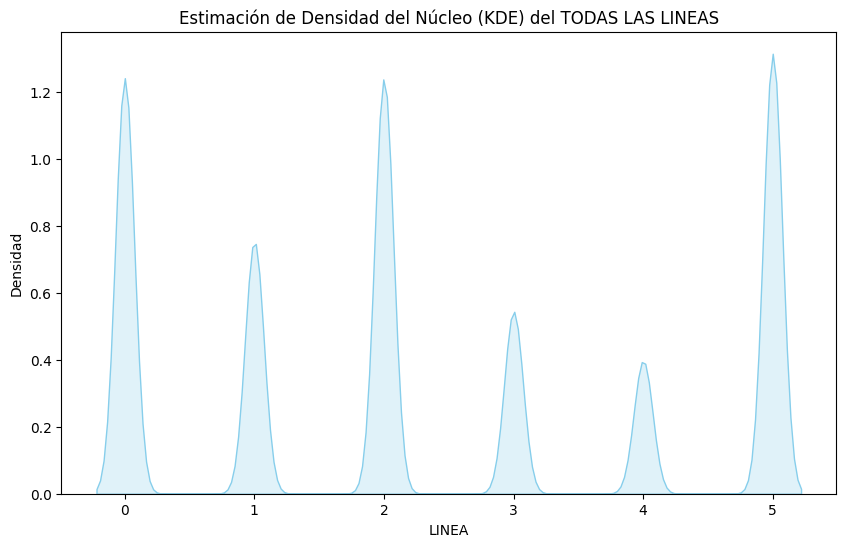

B:0, C:1, D:2, E:3, H:4, A:5


In [51]:
#GRAFICO  KDE (Kernel Density Estimation) para la columna TOTAL por LINEA
plt.figure(figsize=(10, 6))
sns.kdeplot(dfnumerico['LINEA_NUMERICA'], fill=True, color='skyblue')
plt.title('Estimación de Densidad del Núcleo (KDE) del TODAS LAS LINEAS')
plt.xlabel('LINEA')
plt.ylabel('Densidad')
plt.show()

print('B:0, C:1, D:2, E:3, H:4, A:5')


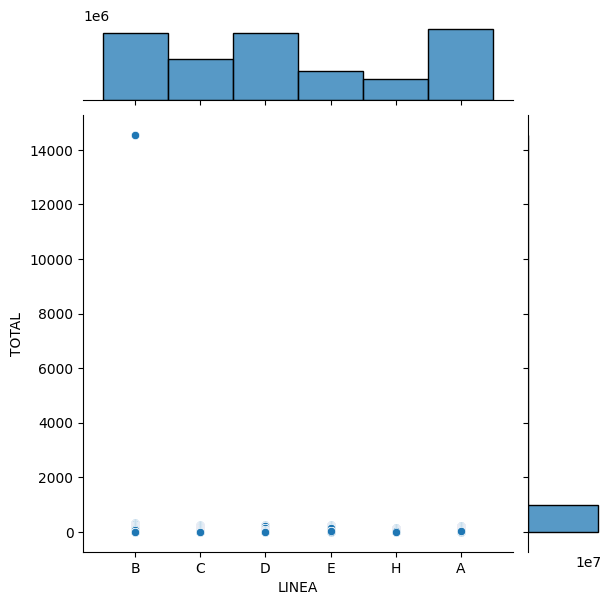

In [52]:
#GRAFICO UN JOINTPLOT PARA ANALIZAR LA RELACION ENTRE LA LINEA Y EL TOTAL DE PASAJEROS QUE UTILIZARON EL SERVICIO.
sns.jointplot(data=dfanalisis, x='LINEA', y='TOTAL', kind='scatter', marginal_kws=dict(bins=15, fill=True))
plt.show()

Se puede observar claramente el OUTLIER detectado al principio.

**ANALISIS SEGUN MOLNETES**

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL) en todos los molinetes.

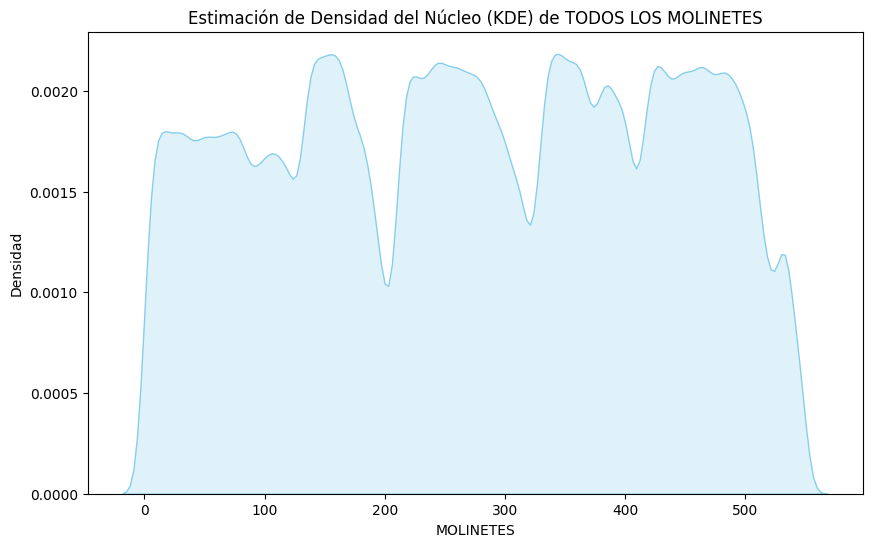

In [53]:
#GRAFICO  KDE (Kernel Density Estimation) para la columna TOTAL por MOLINETE
plt.figure(figsize=(10, 6))
sns.kdeplot(dfnumerico['MOLINETE_NUMERICO'], fill=True, color='skyblue')
plt.title('Estimación de Densidad del Núcleo (KDE) de TODOS LOS MOLINETES')
plt.xlabel('MOLINETES')
plt.ylabel('Densidad')
plt.show()



-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL) en todos los molinetes APERTURADO POR LINEA.

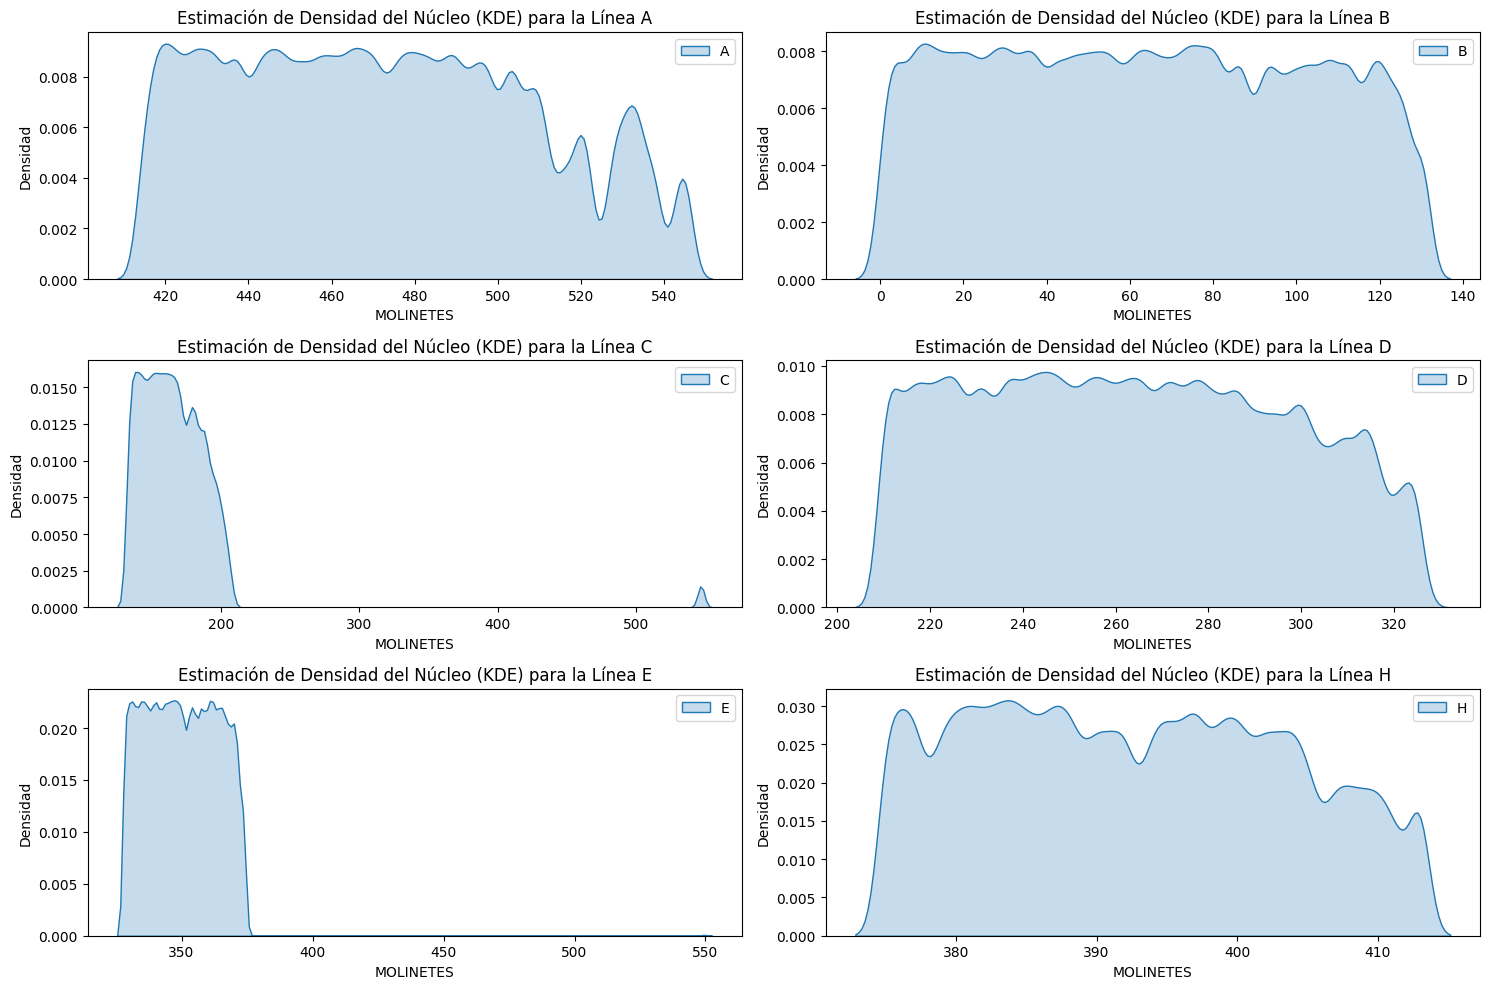

In [54]:

LINEAS = ['A','B','C','D','E','H']

fig, axs = plt.subplots(3, 2, figsize=(15, 10))  # Cro una figura con 3x2 subfiguras

for i, LINEA in enumerate(LINEAS):  # Itera sobre las líneas
    subset = dfanalisis[dfanalisis['LINEA'] == LINEA]  # Filtra los datos para la línea actual
    
    ax = axs[i // 2, i % 2]  # Selecciona la subfigura actual
    
    sns.kdeplot(subset['MOLINETE_NUMERICO'], fill=True, label=LINEA, ax=ax)  # Crea el KDE para la línea
    
    ax.set_title(f'Estimación de Densidad del Núcleo (KDE) para la Línea {LINEA}')  # Título para cada subfigura
    ax.set_xlabel('MOLINETES')  # Etiqueta para el eje x
    ax.set_ylabel('Densidad')  # Etiqueta para el eje y
    ax.legend()  # Muestra la leyenda con las líneas

plt.tight_layout()  # Ajusta el espacio entre las subfiguras
plt.show()  # Muestra la figura


- GRAFICO UN JOINTPLOT PARA ANALIZAR LA RELACION ENTRE LOS MOLINETES Y EL TOTAL DE PASAJEROS QUE UTILIZARON EL SERVICIO.

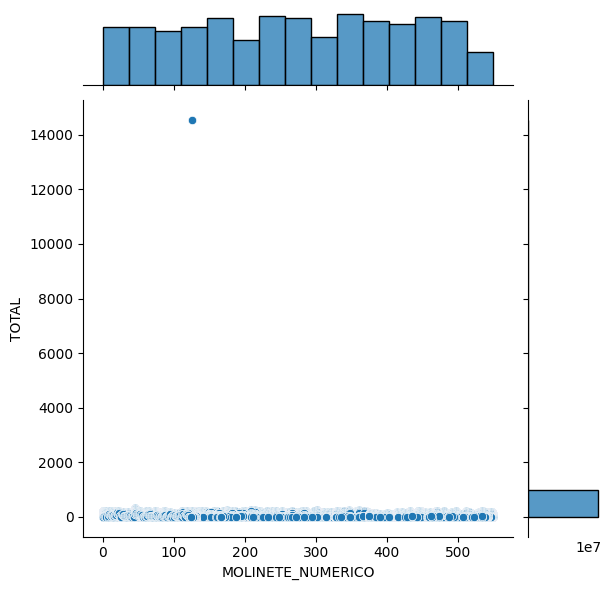

In [55]:
#GRAFICO UN JOINTPLOT PARA ANALIZAR LA RELACION ENTRE LOS MOLINETES Y EL TOTAL DE PASAJEROS QUE UTILIZARON EL SERVICIO.
sns.jointplot(data=dfanalisis, x='MOLINETE_NUMERICO', y='TOTAL', kind='scatter', marginal_kws=dict(bins=15, fill=True))
plt.show()

**ANALISIS SEGUN ESTACION**

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL) en todas las ESTACIONES.

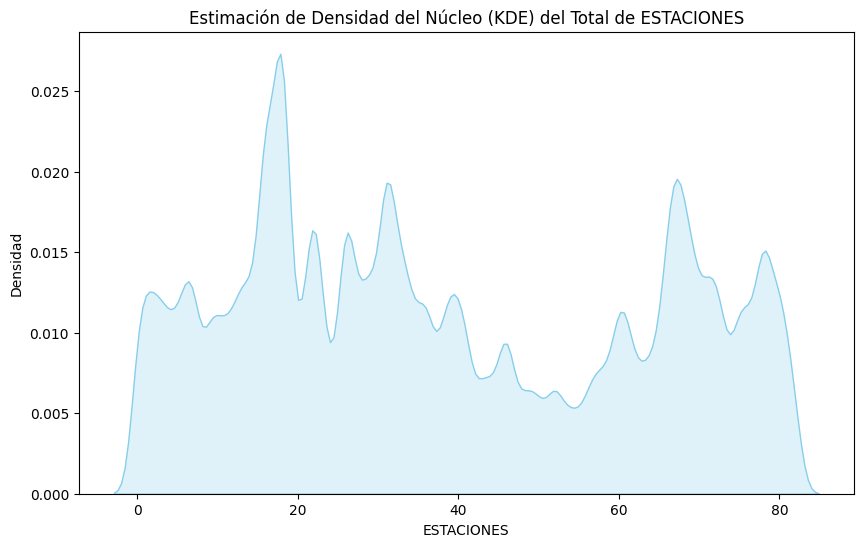

In [56]:
#GRAFICO  KDE (Kernel Density Estimation) para la columna TOTAL por ESTACION
plt.figure(figsize=(10, 6))
sns.kdeplot(dfnumerico['ESTACION_NUMERICA'], fill=True, color='skyblue')
plt.title('Estimación de Densidad del Núcleo (KDE) del Total de ESTACIONES')
plt.xlabel('ESTACIONES')
plt.ylabel('Densidad')
plt.show()

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL) en todas las ESTACIONES aperturado POR LINEA.

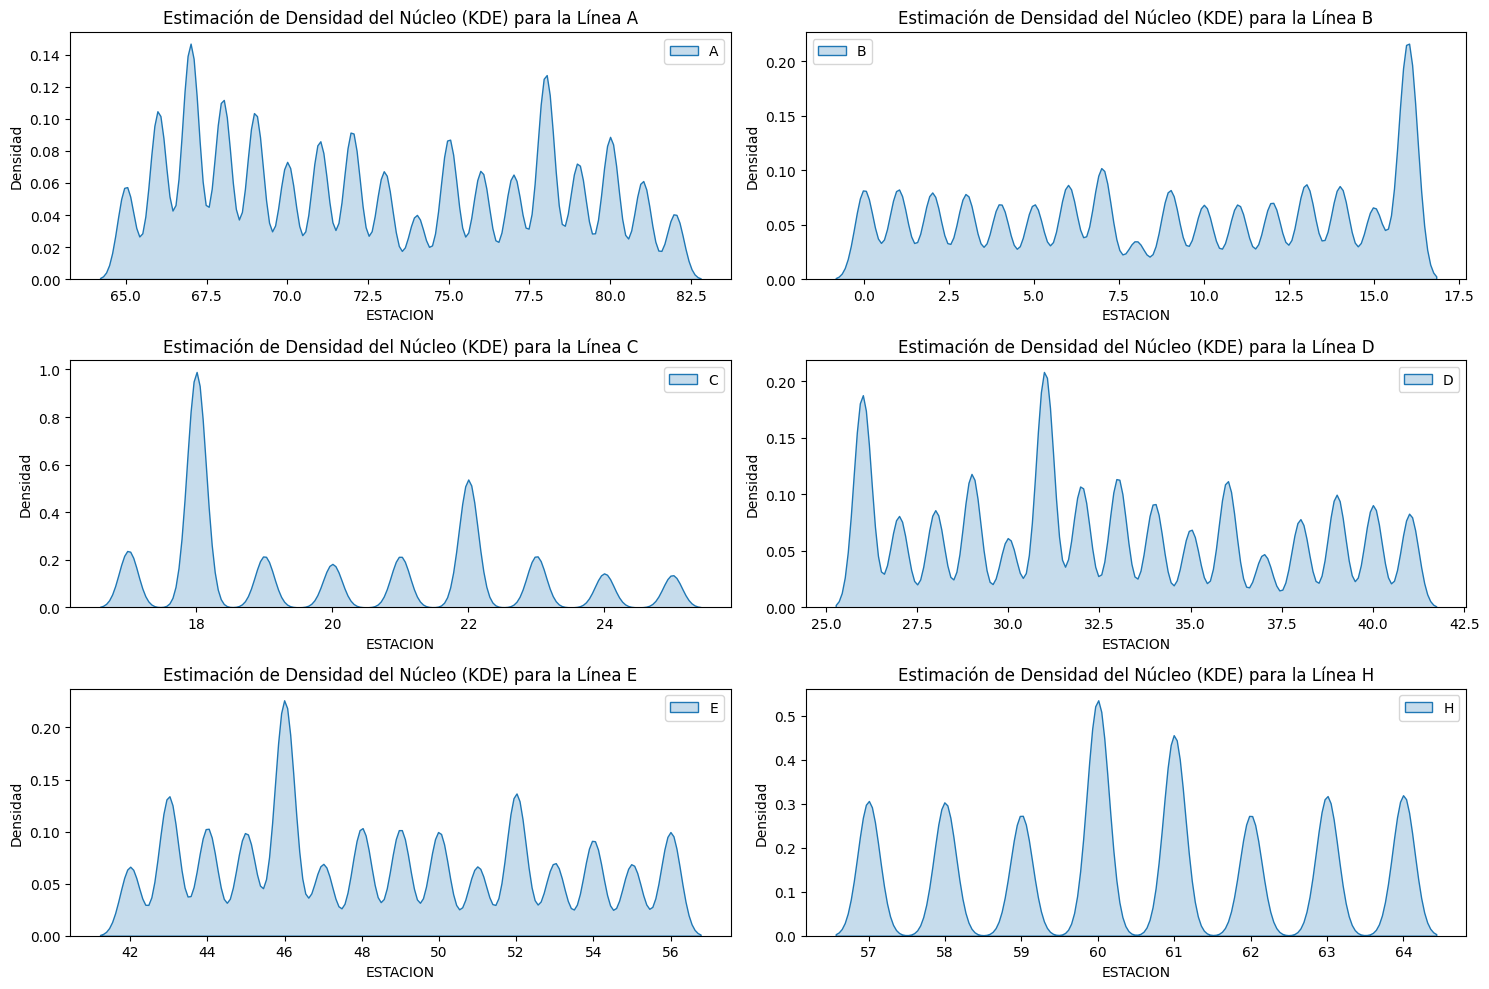

In [57]:
LINEAS = ['A','B','C','D','E','H']

fig, axs = plt.subplots(3, 2, figsize=(15, 10))  # Crea una figura con 3x2 subfiguras

for i, LINEA in enumerate(LINEAS):  # Itera sobre las líneas
    subset = dfanalisis[dfanalisis['LINEA'] == LINEA]  # Filtra los datos para la línea actual
    
    ax = axs[i // 2, i % 2]  # Selecciona la subfigura actual
    
    sns.kdeplot(subset['ESTACION_NUMERICA'], fill=True, label=LINEA, ax=ax)  # Crea el KDE para la línea
    
    ax.set_title(f'Estimación de Densidad del Núcleo (KDE) para la Línea {LINEA}')  # Título para cada subfigura
    ax.set_xlabel('ESTACION')  # Etiqueta para el eje x
    ax.set_ylabel('Densidad')  # Etiqueta para el eje y
    ax.legend()  # Muestra la leyenda con las líneas

plt.tight_layout()  # Ajusta el espacio entre las subfiguras
plt.show()  # Muestra la figura


- GRAFICO UN JOINTPLOT PARA ANALIZAR LA RELACION ENTRE LA ESTACION Y EL TOTAL DE PASAJEROS QUE UTILIZARON EL SERVICIO.

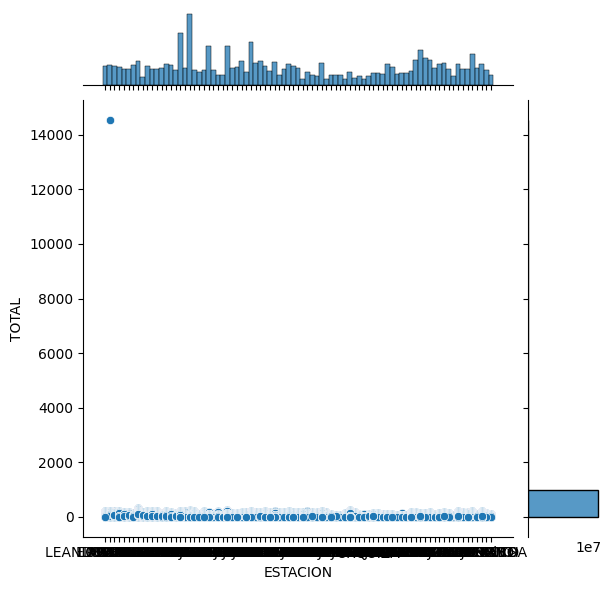

In [58]:
#GRAFICO UN JOINTPLOT PARA ANALIZAR LA RELACION ENTRE LA ESTACION Y EL TOTAL DE PASAJEROS QUE UTILIZARON EL SERVICIO.
sns.jointplot(data=dfanalisis, x='ESTACION', y='TOTAL', kind='scatter', marginal_kws=dict(bins=15, fill=True))
plt.show()

- Este código identifica el valor máximo en la columna TOTAL, que representa un posible outlier. 
- Luego muestra la estación y la fila completa asociadas a ese valor. 
- Esto sirve para detectar eventos atípicos o errores en los datos.

In [59]:
#IDENTIFICACION DE OUTLIERS
max_pax = dfanalisis['TOTAL'].max()
outlier_estacion = dfanalisis[dfanalisis['TOTAL'] == max_pax]['ESTACION'].values[0]

print(f"El outlier es: {max_pax} en la estación {outlier_estacion}")
print()
print()
max_pax = dfanalisis['TOTAL'].max()
outlier_fila = dfanalisis[dfanalisis['TOTAL'] == max_pax]
print(outlier_fila)

El outlier es: 14539 en la estación LEANDRO N. ALEM


              FECHA     DESDE     HASTA LINEA               MOLINETE  \
2569691  2014-07-08  17:00:00  17:14:00     B  LINEA_B_ALEM_N_TURN02   

                ESTACION  PAX_PAGO  PAX_PASES_PAGOS  PAX_FRANQ  PAX_TOTAL  \
2569691  LEANDRO N. ALEM     14537                1          1      14538   

         TOTAL  LINEA_NUMERICA  MOLINETE_NUMERICO  ESTACION_NUMERICA  \
2569691  14539               0                126                  1   

         FECHA_NUMERICA  DESDE_NUMERICA  HASTA_NUMERICA  
2569691        20140708            1700            1714  


In [60]:
#COMPROBACION DEL OUTLIER EN EL VALOR = max. 
estadisticas = dfanalisis['TOTAL'].describe()
print(estadisticas)


count    1.085724e+07
mean     2.568886e+01
std      2.723842e+01
min      0.000000e+00
25%      7.000000e+00
50%      1.600000e+01
75%      3.400000e+01
max      1.453900e+04
Name: TOTAL, dtype: float64


In [61]:
dfanalisismax = dfanalisis.sort_values(by='TOTAL', ascending=False)
dfanalisismax[['PAX_PAGO','PAX_PASES_PAGOS','PAX_FRANQ','TOTAL']].head(50)


,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,TOTAL
2569691,14537,1,1,14539
5845760,316,3,7,326
5845761,317,2,2,321
5885983,303,0,3,306
5861850,295,1,2,298
5853805,292,0,1,293
5885984,287,2,3,292
5861852,287,3,0,290
5837714,286,2,2,290
5837716,285,2,2,289


COMO SE PUEDE OBSERVAR EN EL CUADRO ANTERIOR, EL OUTLIER PROVIENE DE LA COLUMNA PAX_PAGO. CORRESPONDE A LA ESTACION ALEM, (LINEA_B_ALEM_N_TURN02) LINEA B - TURNO 02.
ESTO AFECTA CONSIDERABLEMENTE A LA COLUMNA TOTAL, YA QUE SE COMPONE DE LA SUMA DE TODAS LAS CATEGORIAS DE PAX.


**AJUSTO EL LIMITE SUPERIOR DEL (EJE Y) PARA ENFOCARME EN LOS DATOS SIN EL OUTLIER Y VER SI EXISTEN OTROS**

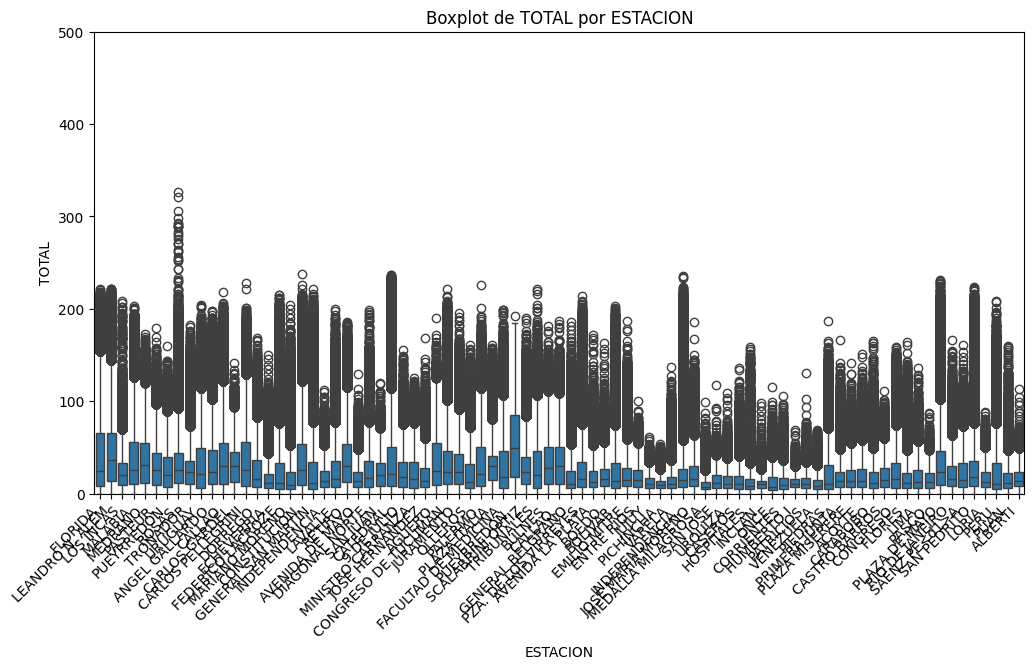

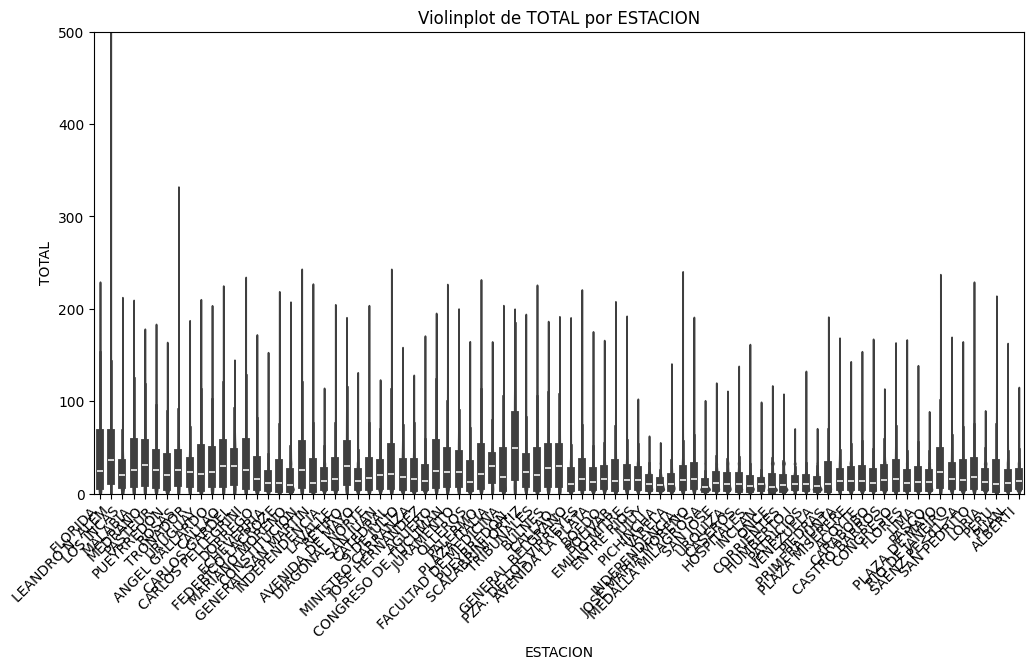

In [62]:
# CREO UN BOXPLOT PARA VISUALIZAR SI HAY MAS OUTLIERS.
plt.figure(figsize=(12, 6))  # Ajusta el tamaño según sea necesario
sns.boxplot(data=dfanalisis, x='ESTACION', y='TOTAL')
plt.title('Boxplot de TOTAL por ESTACION')
plt.xticks(rotation=45, ha='right')  # Rota las etiquetas del eje X para mejor legibilidad
plt.ylim(0, 500)
plt.show() 

# CREO UN VIOlINPLOT PARA VISUALIZAR LOS OUTLIERS
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfanalisis, x='ESTACION', y='TOTAL')
plt.title('Violinplot de TOTAL por ESTACION')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 500)
plt.show() 


- Se observa que la estación Leandro N. Alem concentra la mayor cantidad de viajes, lo cual se explica por la presencia del outlier previamente identificado. 
- Al eliminar este valor atípico, la distribución de viajes por estación se vuelve más uniforme, aunque aún se destacan dos estaciones con un mínimo claramente inferior: Pichincha y Varela.

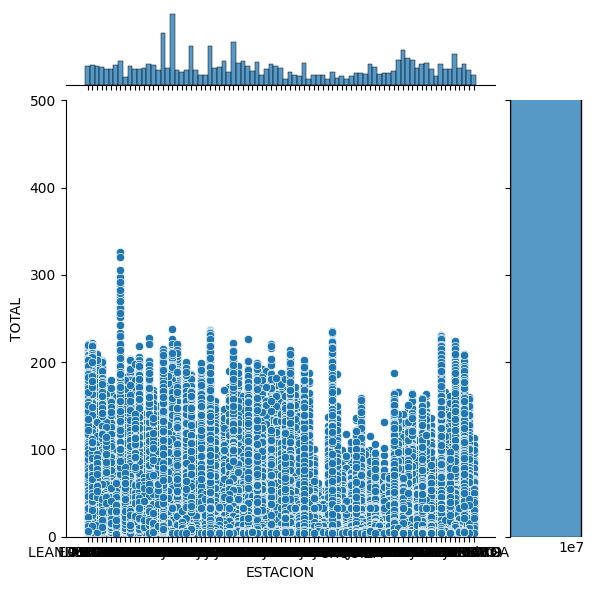

In [63]:
# CREO NUEVAMENTE EL JOINTPLOT PARA ENFOCARME EN LOS DATOS SIN EL OUTLIER, PARA ESTO AJUSTO EL LIMITE SUPERIOR DEL EJE Y
sns.jointplot(data=dfanalisis, x='ESTACION', y='TOTAL', kind='scatter', marginal_kws=dict(bins=15, fill=True))

# Ajustar el límite superior del eje Y
plt.ylim(0, 500)  # Ajusto a 350 el eje de las Y

plt.show()


**SEGUN LINEA DE SUBTE**

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL) en las LINEAS de SUBTE.

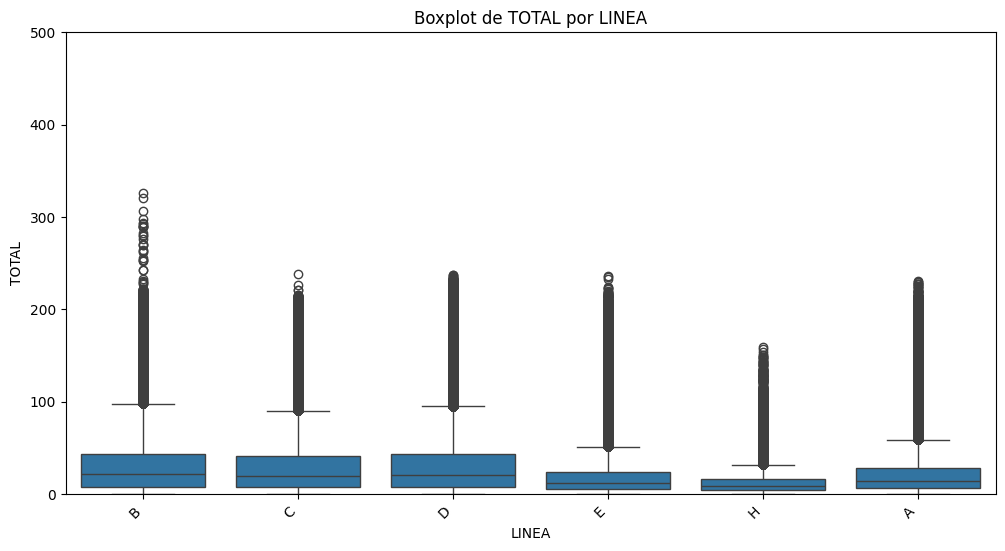

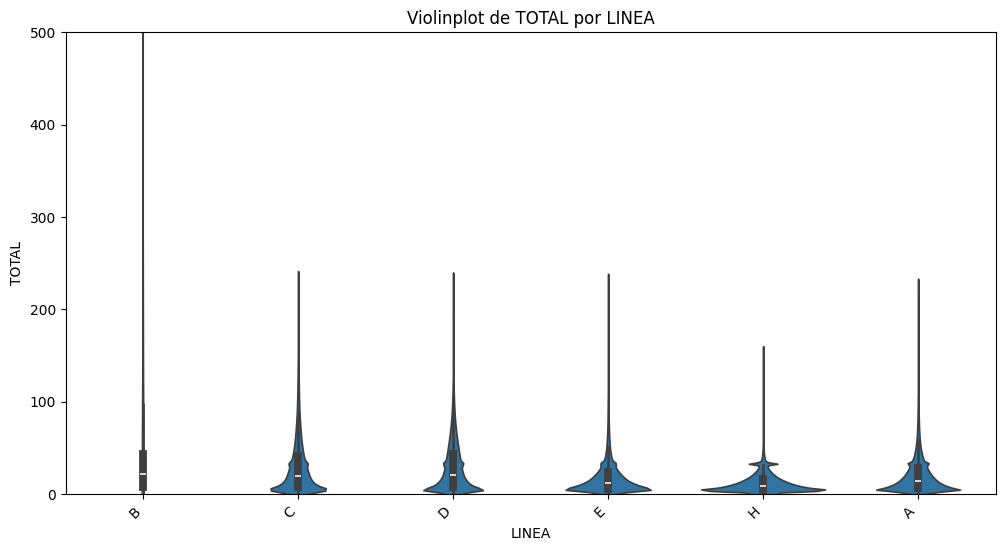

In [64]:
# CREO UN BOXPLOT PARA VISUALIZAR LOS OUTLIERS
plt.figure(figsize=(12, 6))  # Ajusta el tamaño según sea necesario
sns.boxplot(data=dfanalisis, x='LINEA', y='TOTAL')
plt.title('Boxplot de TOTAL por LINEA')
plt.xticks(rotation=45, ha='right')  # Rota las etiquetas del eje X para mejor legibilidad
plt.ylim(0, 500)
plt.show() 

# CREO UN VIOlINPLOT PARA VISUALIZAR LOS OUTLIERS
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfanalisis, x='LINEA', y='TOTAL')
plt.title('Violinplot de TOTAL por LINEA')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 500)
plt.show() 


Se puede observar como los viajes estan distribuidos por cada LINEA de subte,, con una ventaja muy grande en la LINEA B. Esto refleja claramente la presencia del OUTLIER.

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL)  ANUAL.

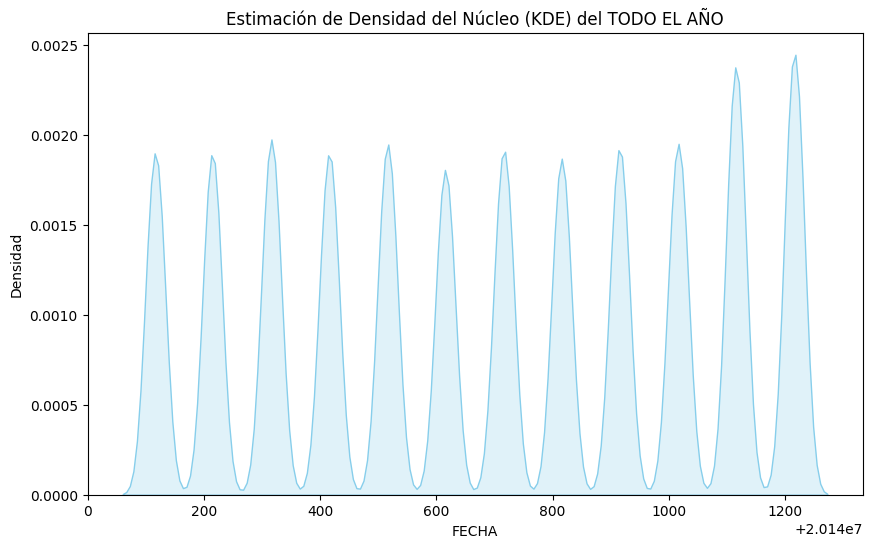

In [65]:
#GRAFICO  KDE (Kernel Density Estimation) para la columna TOTAL por FECHA.
plt.figure(figsize=(10, 6))
sns.kdeplot(dfnumerico['FECHA_NUMERICA'], fill=True, color='skyblue')
plt.title('Estimación de Densidad del Núcleo (KDE) del TODO EL AÑO')
plt.xlabel('FECHA')
plt.ylabel('Densidad')
plt.show()


Se puede observar como el comportamoento de los viajes estan distribuidos por cada mes del año, con una tendencia mas alta hacia los 2 ultimos meses del año. (Noviembre y Diciembre)

-En los siguietes graficos, se visualizaran cómo se distribuye el flujo de pasajeros (TOTAL)  aperturado POR LINEA.

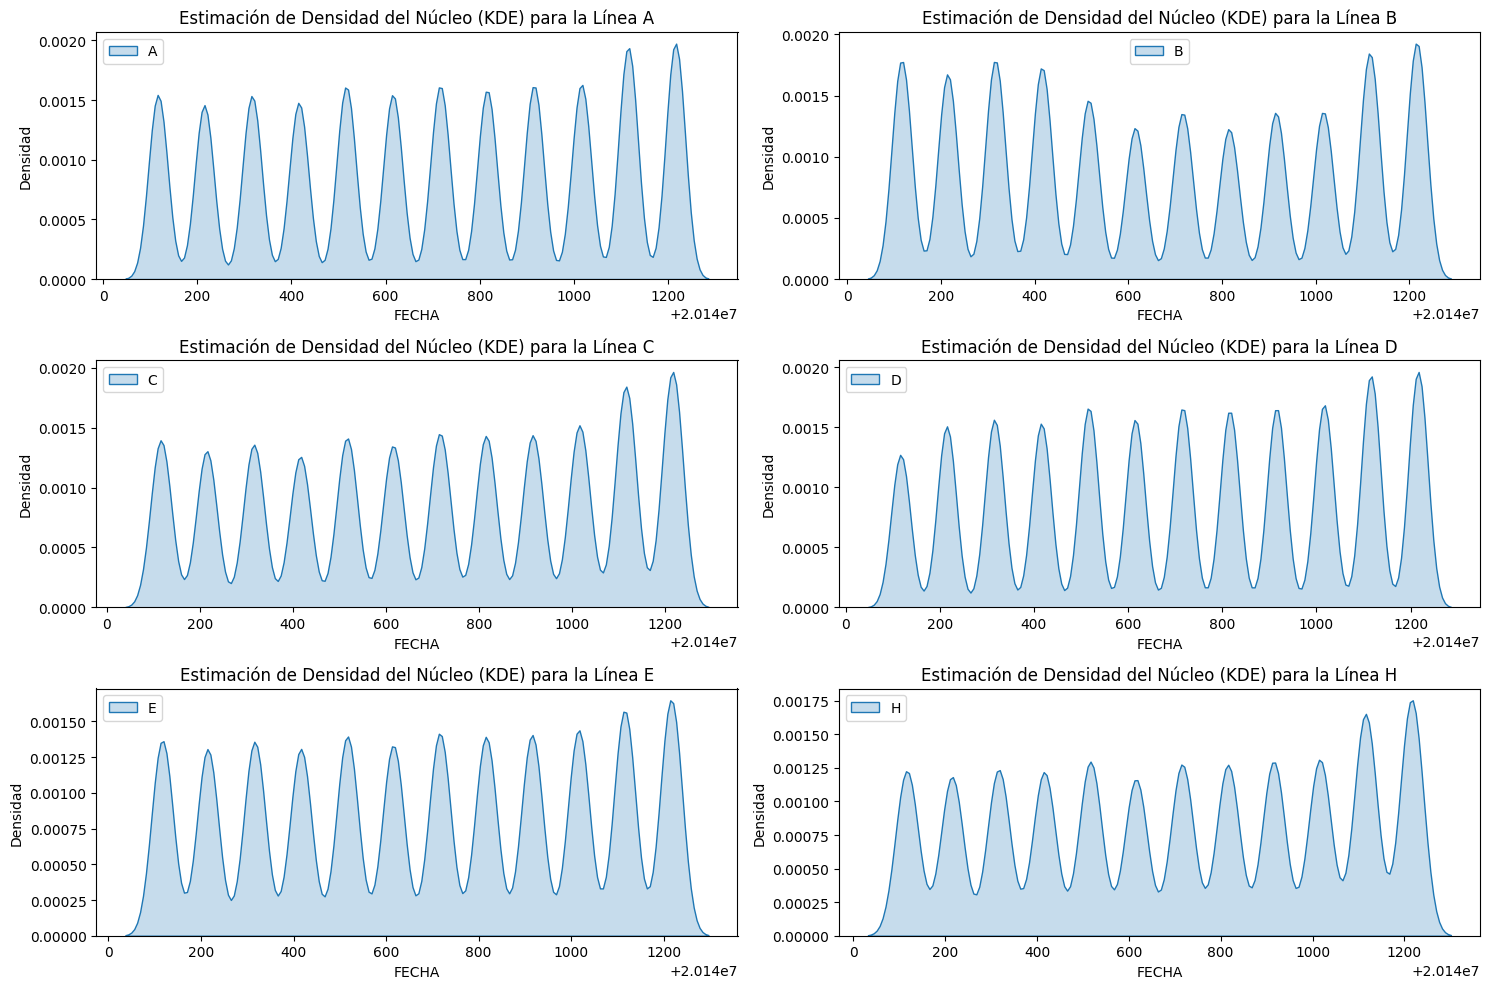

In [66]:
LINEAS = ['A','B','C','D','E','H']

fig, axs = plt.subplots(3, 2, figsize=(15, 10))  # Crea una figura con 3x2 subfiguras

for i, LINEA in enumerate(LINEAS):  # Itera sobre las líneas
    subset = dfanalisis[dfanalisis['LINEA'] == LINEA]  # Filtra los datos para la línea actual
    
    ax = axs[i // 2, i % 2]  # Selecciona la subfigura actual
    
    sns.kdeplot(subset['FECHA_NUMERICA'], fill=True, label=LINEA, ax=ax)  # Crea el KDE para la línea
    
    ax.set_title(f'Estimación de Densidad del Núcleo (KDE) para la Línea {LINEA}')  # Título para cada subfigura
    ax.set_xlabel('FECHA')  # Etiqueta para el eje x
    ax.set_ylabel('Densidad')  # Etiqueta para el eje y
    ax.legend()  # Muestra la leyenda con las líneas

plt.tight_layout()  # Ajusta el espacio entre las subfiguras
plt.show()  # Muestra la figura


**SE PUEDE OBSERVAR QUE DURANTE EL AñO, LOS VIAJES SON BASTANTE UNIFORMES.
EN ESTE AñO EN PARTICULAR (2014), LA DEMANDA SE MANTUVO CONSTANTE. EN TODAS LAS LINEAS SE VE UN AUMENTO EN LOS VIAJES HACIA FIN DE AñO**

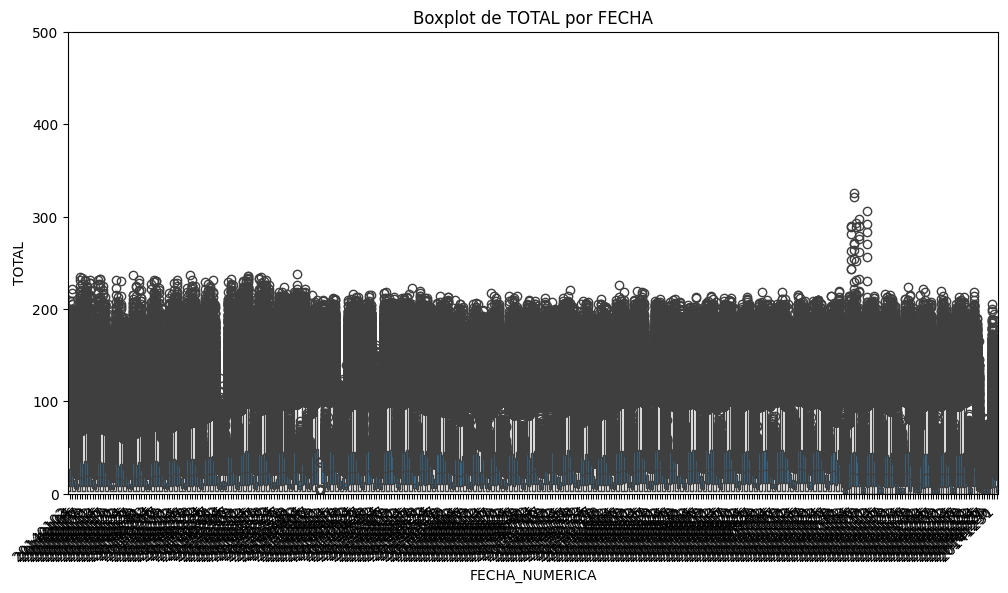

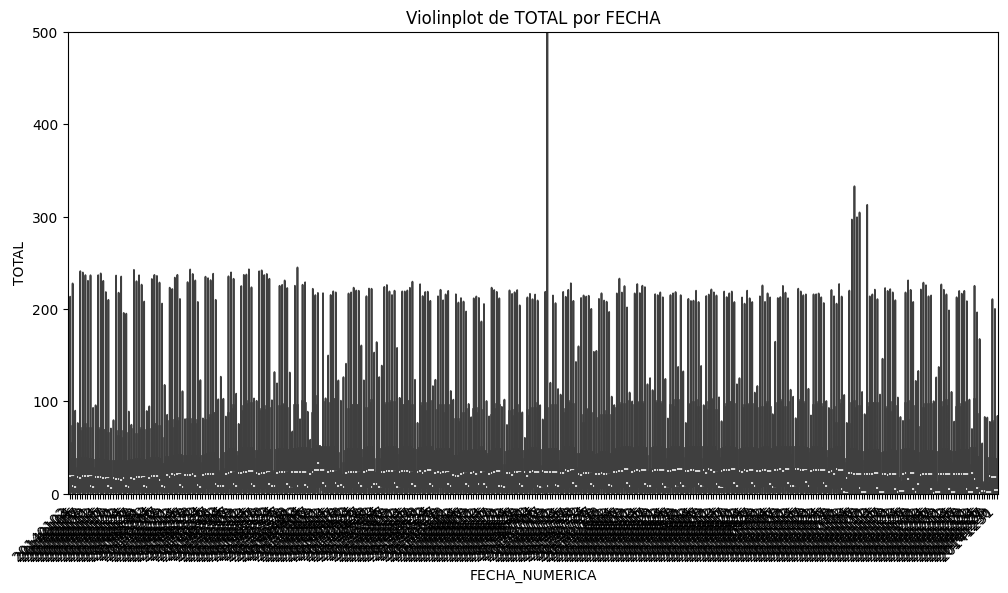

In [67]:
# CREO UN BOXPLOT PARA VISUALIZAR LOS OUTLIERS
plt.figure(figsize=(12, 6))  # Ajusta el tamaño según sea necesario
sns.boxplot(data=dfanalisis, x='FECHA_NUMERICA', y='TOTAL')
plt.title('Boxplot de TOTAL por FECHA')
plt.xticks(rotation=45, ha='right')  # Rota las etiquetas del eje X para mejor legibilidad
plt.ylim(0, 500)
plt.show() 

# CREO UN VIOlINPLOT PARA VISUALIZAR LOS OUTLIERS
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfanalisis, x='FECHA_NUMERICA', y='TOTAL')
plt.title('Violinplot de TOTAL por FECHA')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 500)
plt.show() 

- Se observa que el comportamiento de los viajes se distribuye de forma relativamente uniforme a lo largo de los meses del año, con una marcada desviación en el centro del gráfico, correspondiente al mes de julio. 
- Esta anomalía se debe al outlier previamente identificado.

- Todas estas visualizaciones permiten identificar con claridad la presencia del outlier, el cual fue detectado y analizado en detalle mediante código en la línea 128 del script. 
- Este valor atípico impacta significativamente en la distribución general de los datos.

**Inicio el proceso de preparación del DataFrame con el objetivo de utilizarlo en la fase de prueba de modelos de predicción.**

**Esta etapa incluye la selección de variables relevantes, limpieza de datos y adaptación del formato para garantizar su compatibilidad con algoritmos de aprendizaje automático**

- El DataFrame "dfnumerico" fue generado como resultado de un proceso de transformación en el cual todas las columnas originales fueron convertidas a formato numérico. 
- Esto incluye la codificación de valores alfanuméricos, con el objetivo de adaptar los datos para su utilización en modelos de predicción y análisis automatizado.

In [68]:
#CREO UN NUEVO DATAFRAME PARA ELIMINAR EL OUTLIER, Y LUEGO UTILIZARLO PARA COMENZAR CON LAS PRUEBAS. 
dfsinoutlier = dfnumerico

**ELIMINACION DE OUTLIERS QUE SE DETECTARON EN LA ETAPA ANTERIOR**


In [69]:
#IDENTIFICACION DE OUTLIERS
#INGRESAR LA FEATURE DONDE SE QUIERE IDENTIFICAR EL OUTLIER

feature = 'PAX_PAGO'

max_pax2 = dfsinoutlier[feature].max()
outlier_estacion = dfsinoutlier[dfsinoutlier[feature] == max_pax2]['ESTACION_NUMERICA'].values[0]

print(f"El outlier es: {max_pax2} en la estación {outlier_estacion}")
print()
print()
max_pax2 = dfsinoutlier[feature].max()
outlier_fila = dfsinoutlier[dfsinoutlier[feature] == max_pax2]
print(outlier_fila)

El outlier es: 14537 en la estación 1


              FECHA     DESDE     HASTA LINEA               MOLINETE  \
2569691  2014-07-08  17:00:00  17:14:00     B  LINEA_B_ALEM_N_TURN02   

                ESTACION  PAX_PAGO  PAX_PASES_PAGOS  PAX_FRANQ  PAX_TOTAL  \
2569691  LEANDRO N. ALEM     14537                1          1      14538   

         TOTAL  LINEA_NUMERICA  MOLINETE_NUMERICO  ESTACION_NUMERICA  \
2569691  14539               0                126                  1   

         FECHA_NUMERICA  DESDE_NUMERICA  HASTA_NUMERICA  
2569691        20140708            1700            1714  


In [70]:
#LO ORDENO DE MAYOR A MENOR
dfsinoutlier = dfsinoutlier.sort_values(by=feature, ascending=False)

In [71]:
#ME ASEGURO DE QUE ESE SEA EL UNICO OUTLIER O HAY ALGUNO MAS.
dfsinoutlier[[feature]].head(10)


,PAX_PAGO
2569691,14537
5845761,317
5845760,316
5885983,303
5861850,295
5853805,292
5861852,287
5885984,287
5837714,286
5837716,285


- El siguiente código, permite visualizar en detalle los registros con los valores más altos de un DataFrame, con el objetivo de verificar si existen otros posibles outliers además del previamente identificado.
- La variable outliers define cuántos de estos valores extremos se desean analizar. 
- Esto ayuda a validar la limpieza del conjunto de datos antes de entrenar modelos predictivos.

In [72]:

#PARA ASEGURARME DE QUE NO HAYA MAS OUTLIERS, VOY A TOMAR LOS 3 MAS ALTOS.

#INGRESAR LA CANTIDAD DE OUTLIERS QUE SE DESEAN VER EN DETALLE.
outliers = 1

outliers_mas_altos = dfsinoutlier.head(outliers)
print(outliers_mas_altos)

              FECHA     DESDE     HASTA LINEA               MOLINETE  \
2569691  2014-07-08  17:00:00  17:14:00     B  LINEA_B_ALEM_N_TURN02   

                ESTACION  PAX_PAGO  PAX_PASES_PAGOS  PAX_FRANQ  PAX_TOTAL  \
2569691  LEANDRO N. ALEM     14537                1          1      14538   

         TOTAL  LINEA_NUMERICA  MOLINETE_NUMERICO  ESTACION_NUMERICA  \
2569691  14539               0                126                  1   

         FECHA_NUMERICA  DESDE_NUMERICA  HASTA_NUMERICA  
2569691        20140708            1700            1714  


In [73]:
#LOS IDENTIFICO NUEVAMENTE PARA VER SI SON LOS MISMOS
rmax = dfsinoutlier.nlargest(outliers,feature)
rmax.head()

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
2569691,2014-07-08,17:00:00,17:14:00,B,LINEA_B_ALEM_N_TURN02,LEANDRO N. ALEM,14537,1,1,14538,14539,0,126,1,20140708,1700,1714


In [74]:
dfsinoutlier.head(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
2569691,2014-07-08,17:00:00,17:14:00,B,LINEA_B_ALEM_N_TURN02,LEANDRO N. ALEM,14537,1,1,14538,14539,0,126,1,20140708,1700,1714
5845761,2014-11-05,08:30:00,08:44:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,317,2,2,321,321,0,46,7,20141105,830,844
5845760,2014-11-05,08:15:00,08:29:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,316,3,7,326,326,0,46,7,20141105,815,829
5885983,2014-11-10,08:00:00,08:14:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,303,0,3,306,306,0,46,7,20141110,800,814
5861850,2014-11-07,08:15:00,08:29:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,295,1,2,298,298,0,46,7,20141107,815,829


**ELIMINACION DE LOS OUTLIERS Y CREACION DE UN NUEVO DATASET ("dfentrenamiento")** 

**ESTE DATASET NUEVO ES EL QUE VOY A UTILIZAR PARA REALIZAR LOS ENTRENAMIENTOS Y PREDICIONES CON LOS DISTINTOS MODELOS**

In [75]:
#CREO UN NUEVO DATAFRAME EL CUAL VA A SER EL QUE SE UTILIZARA PARA LOS MODELOS DE PREDICCION DE MACHINE LEARNING Y LUEGO DEEP LEARNING.

#ELIMINO LOS OUTLIERS MAS ALTOS DETECTADOS EN EL PUNTO ANTERIOR.
dfsinoutlierok = dfsinoutlier.drop(outliers_mas_altos.index)

In [76]:
dfsinoutlierok.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'PAX_PAGO',
       'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA'],
      dtype='object')

In [77]:
#CREO EL DATAFRAME dfentrenamiento, EL CUAL SE VA A UTILIZAR PARA LOS MODELOS DE PREDICCION.
dfentrenamiento = dfsinoutlierok

In [78]:
#COMPRUEBO QUE SE HAYAN ELIMINADO LOS OUTLIERS.
dfentrenamiento = dfentrenamiento.sort_values(by=feature, ascending=False)
dfentrenamiento[['FECHA_NUMERICA','PAX_PAGO','PAX_PASES_PAGOS','PAX_FRANQ','TOTAL']].head(5)

,FECHA_NUMERICA,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,TOTAL
5845761,20141105,317,2,2,321
5845760,20141105,316,3,7,326
5885983,20141110,303,0,3,306
5861850,20141107,295,1,2,298
5853805,20141106,292,0,1,293


In [79]:
#Selecciono las columnas que me interesan para el analisis.
#ESTAS COLUMNAS (FEATURESSON LAS MISMAS QUE SELECCIONO EN TODOS LOS DATASETS PARA PODER UNIFICAR LOS CRITERIOS DE ANALISIS.)
dfentrenamiento = dfentrenamiento[['PAX_PAGO','PAX_PASES_PAGOS','PAX_FRANQ','TOTAL','LINEA_NUMERICA','MOLINETE_NUMERICO','ESTACION_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA']]

In [80]:
#GRABO EL NUEVO DATASET YA PREPARADO CON TODOS SUS DATOS EN FORMA NUMERICA PARA UTILIZAR EN LOS MODELOS DE PRUEBA Y TAMBIEN EN DEEP LEARNING.
dfentrenamiento.to_csv('dfentrenamiento2014.csv', index=False)

**Una vez finalizado el proceso de limpieza, normalización y preparación de los datos del DataFrame, el conjunto está listo para ser utilizado en la fase de análisis exploratorio y en la obtención de conclusiones significativas.**

**Esto garantiza la calidad y consistencia necesarias para una interpretación fiable de los resultados.**

**ETAPA DE ANALISIS Y VISUALIZACION DE DATOS** 

**RANKINGS, TOP 10 Y GRAFICOS**

In [81]:
dfentrenamiento.columns

Index(['PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA'],
      dtype='object')

In [82]:
#dfentrenamiento = dfentrenamiento.rename(columns={'LINEA_NUMERICA':'LINEA', 'MOLINETE_NUMERICO':'MOLINETE', 'ESTACION_NUMERICA':'ESTACION', 'FECHA_NUMERICA':'FECHA', 'DESDE_NUMERICA':'DESDE', 'HASTA_NUMERICA':'HASTA'})

In [83]:
dfentrenamiento.columns

Index(['PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA'],
      dtype='object')

- El siguiente codigo, agrupa los datos por línea (LINEA_NUMERICA) y calcula el total de viajes por cada una. 
- Luego, muestra el ranking de las 10 líneas más utilizadas, tanto en formato tabular como gráfico (torta).
- El gráfico resalta la línea con mayor cantidad de viajes mediante una explosión en el sector correspondiente, facilitando su identificación visual.

Ranking TOTAL Pasajes (TOTAL) por LINEA
LINEA_NUMERICA
0    76871984
2    73380862
5    53945973
1    44459232
3    20534867
4     9702752
Name: TOTAL, dtype: int64
B:0, C:1, D:2, E:3, H:4, A:5


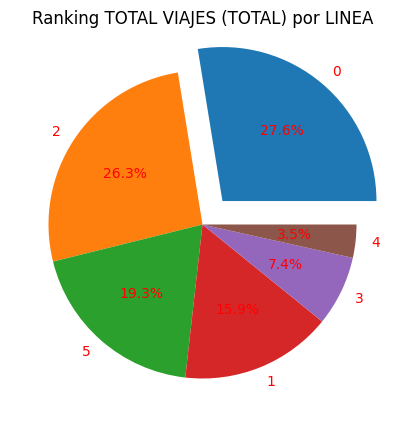

In [84]:
#CREO UN RANKING POR LINEA CON MAYOR CANTIDAD DE VIAJES.
paxpago=dfentrenamiento.groupby('LINEA_NUMERICA')['TOTAL'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Ranking TOTAL Pasajes (TOTAL) por LINEA')
print(paxpago)



plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(paxpago))]
plt.pie(paxpago,labels=paxpago.index,autopct='%1.1f%%', startangle=0,explode=explosion ,textprops={'color':"red"})
plt.title('Ranking TOTAL VIAJES (TOTAL) por LINEA')

print('B:0, C:1, D:2, E:3, H:4, A:5')

In [85]:
dfanalisis['TOTAL'].sum()

278910209

- EL siguiente codigo, genera un ranking por línea con mayor cantidad de viajes pagos (PAX_PAGO), agrupando por LINEA_NUMERICA y sumando los registros.
- Luego, representa visualmente los resultados mediante un gráfico de torta, destacando la línea más utilizada al desplazar su sector.
- Esto permite identificar de forma rápida qué líneas concentran mayor uso en términos de pasajes pagos.

Ranking de VIAJES PAGOS (PAX_PAGOS) por LINEA
LINEA_NUMERICA
0    69436839
2    66164206
5    46540492
1    40005238
3    17522157
4     7675738
Name: PAX_PAGO, dtype: int64
B:0, C:1, D:2, E:3, H:4, A:5


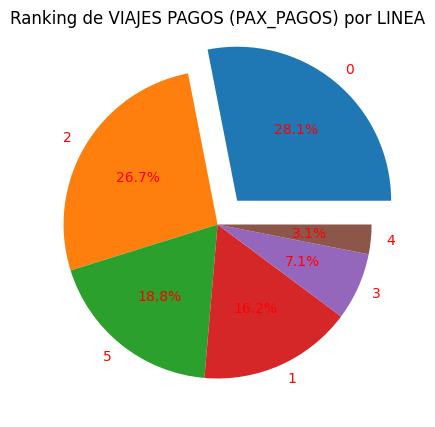

In [86]:
#CREO UN RANKING POR LINEA CON MAYOR CANTIDAD DE VIAJES PAGOS.
paxpago=dfentrenamiento.groupby('LINEA_NUMERICA')['PAX_PAGO'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Ranking de VIAJES PAGOS (PAX_PAGOS) por LINEA')
print(paxpago)

plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(paxpago))]
plt.pie(paxpago,labels=paxpago.index,autopct='%1.1f%%', startangle=0,explode=explosion ,textprops={'color':"red"})
plt.title('Ranking de VIAJES PAGOS (PAX_PAGOS) por LINEA')

print('B:0, C:1, D:2, E:3, H:4, A:5')

- El siguiente codigo, genera un ranking por línea con mayor cantidad de (PAX_PASES_PAGOS) y se representa gráficamente mediante una torta con énfasis en la línea líder, facilitando la interpretación visual del dominio de uso por pases.

Ranking de PASES PAGOS (PAX_PASES_PAGOS) por LINEA
LINEA_NUMERICA
5    2524146
2    2431782
0    2394245
1    1383197
3    1040186
4     727808
Name: PAX_PASES_PAGOS, dtype: int64
B:0, C:1, D:2, E:3, H:4, A:5


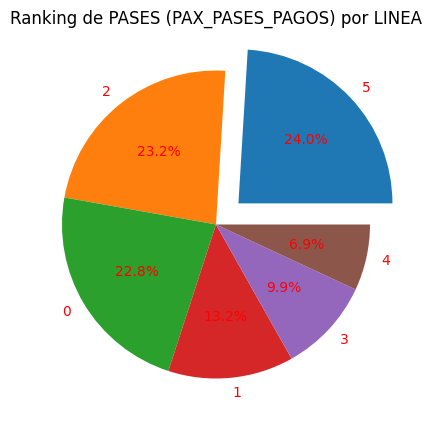

In [87]:
#CREO UN RANKING POR LINEA CON MAYOR CANTIDAD DE PASES.
paxpago=dfentrenamiento.groupby('LINEA_NUMERICA')['PAX_PASES_PAGOS'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Ranking de PASES PAGOS (PAX_PASES_PAGOS) por LINEA')
print(paxpago)

plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(paxpago))]
plt.pie(paxpago,labels=paxpago.index,autopct='%1.1f%%', startangle=0,explode=explosion ,textprops={'color':"red"})
plt.title('Ranking de PASES (PAX_PASES_PAGOS) por LINEA')

print('B:0, C:1, D:2, E:3, H:4, A:5')


- El siguiente codigo, genera un ranking por línea con mayor cantidad de (PASES FRANQUICIADOS) y se representa gráficamente mediante una torta con énfasis en la línea líder, facilitando la interpretación visual del dominio de uso por pases.

Ranking de PASES FRANQUICIADOS (PAX_FRANQ) por LINEA
LINEA_NUMERICA
0    5040900
5    4881335
2    4784874
1    3070797
3    1972524
4    1299206
Name: PAX_FRANQ, dtype: int64
B:0, C:1, D:2, E:3, H:4, A:5


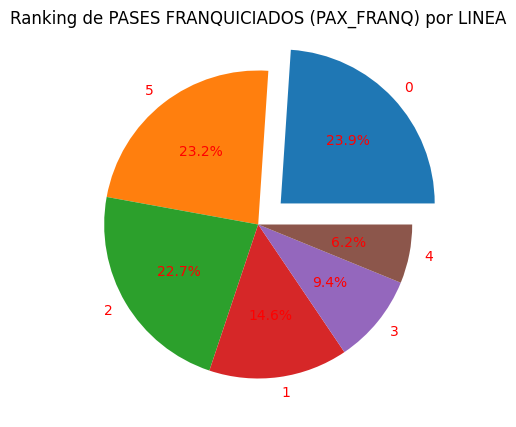

In [88]:
#CREO UN RANKING POR LINEA CON MAYOR CANTIDAD DE PASES FRANQUICIADOS.
paxpago=dfentrenamiento.groupby('LINEA_NUMERICA')['PAX_FRANQ'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('Ranking de PASES FRANQUICIADOS (PAX_FRANQ) por LINEA')
print(paxpago)

plt.figure(figsize=(10,5))
explosion = [0.2 if i==0 else 0 for i in range(len(paxpago))]
plt.pie(paxpago,labels=paxpago.index,autopct='%1.1f%%', startangle=0,explode=explosion ,textprops={'color':"red"})
plt.title('Ranking de PASES FRANQUICIADOS (PAX_FRANQ) por LINEA')

print('B:0, C:1, D:2, E:3, H:4, A:5')

- El siguiente codigo, genera un gráfico de barras GLOBAL que permite comparar visualmente el volumen total de cada tipo de viaje por línea, facilitando el análisis de comportamiento de los pasajeros según el tipo de acceso.

<Figure size 1000x600 with 0 Axes>

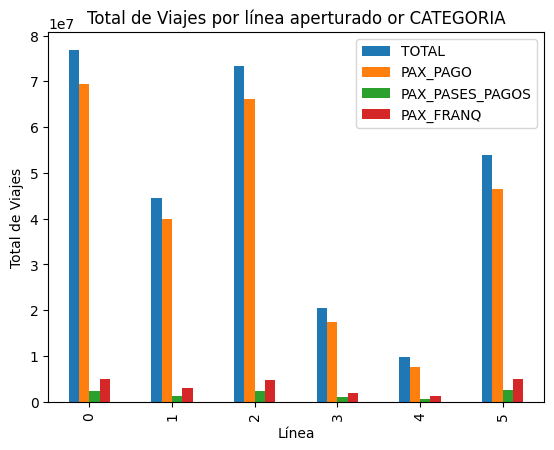

B:0, C:1, D:2, E:3, H:4, A:5


In [89]:
# Agrupa los datos por LINEA y calcula el total de PAX_PAGO, PAX_PASES_PAGOS y PAX_FRANQ
df_grupo = dfentrenamiento.groupby("LINEA_NUMERICA")[["TOTAL","PAX_PAGO", "PAX_PASES_PAGOS", "PAX_FRANQ"]].sum()

# Crea un gráfico de barras
plt.figure(figsize=(10, 6))
df_grupo.plot(kind="bar")
plt.xlabel("Línea")
plt.ylabel("Total de Viajes")
plt.title("Total de Viajes por línea aperturado or CATEGORIA")
plt.legend()
plt.show()

print('B:0, C:1, D:2, E:3, H:4, A:5')

- El siguiente codigo, genera un gráfico de barras POR LINEA que permite comparar visualmente el volumen total de cada tipo de viaje por línea, facilitando el análisis de comportamiento de los pasajeros según el tipo de acceso.

Apertura Total CATEGORIAS de viajes por Linea


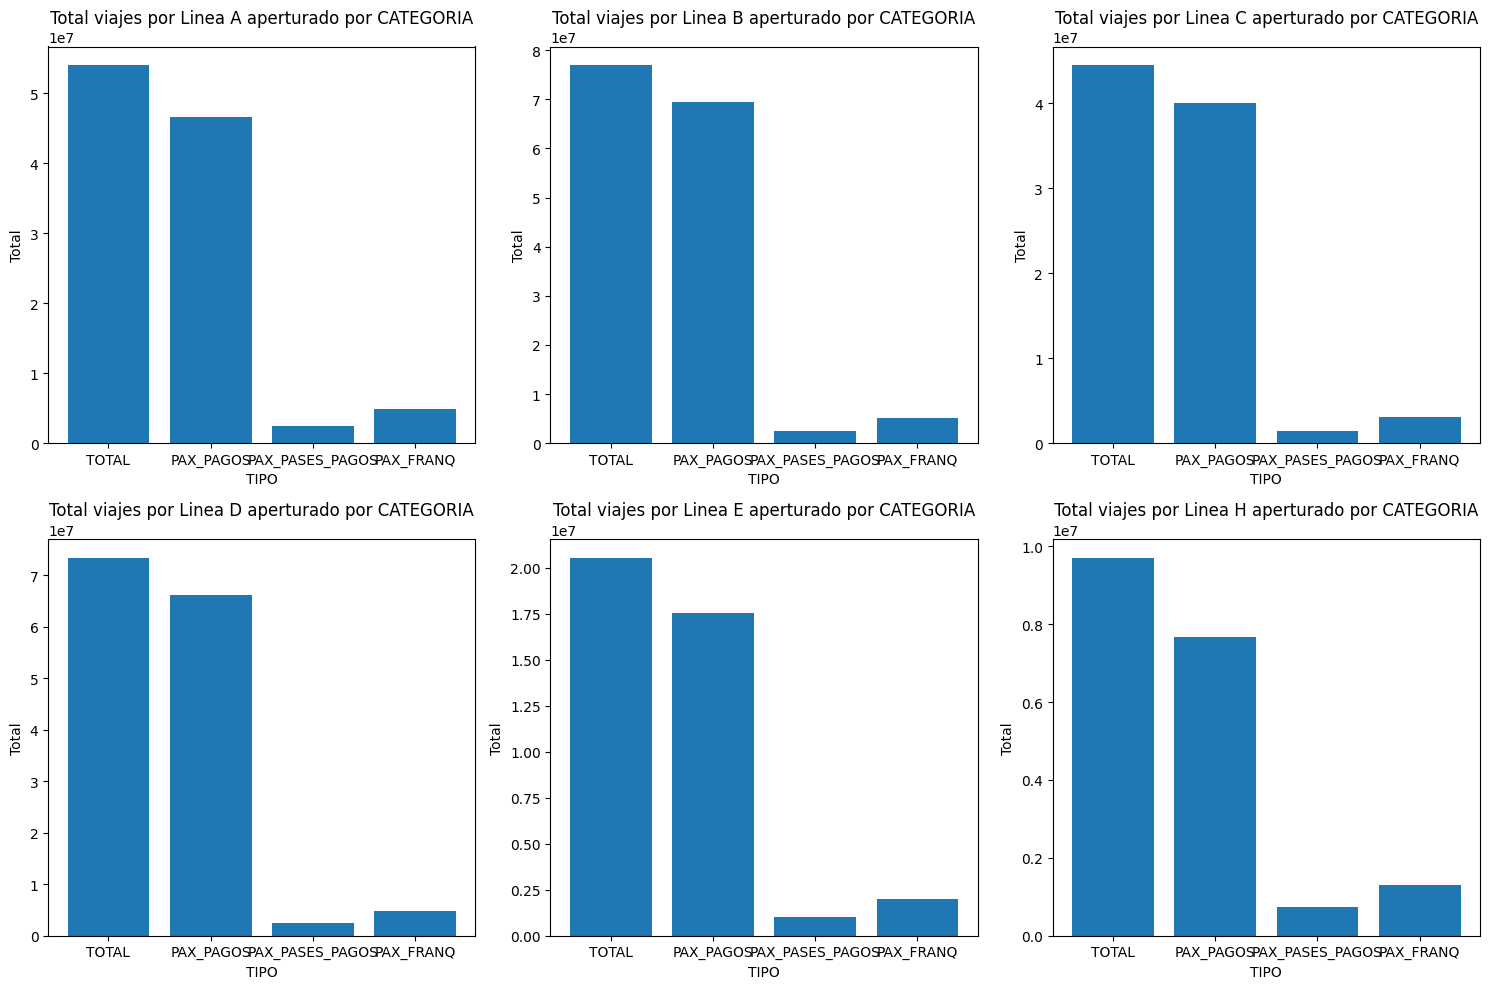

B:0, C:1, D:2, E:3, H:4, A:5


In [90]:
#AHORA LO VISUALIZO POR LINEA
fig,axs = plt.subplots(2,3, figsize=(15,10), sharey=False, sharex=False)
LINEAS = ['A','B','C','D','E','H']
for i, LINEA in enumerate(LINEAS):
        ax = axs[i // 3, i%3]
        pax_total = dfanalisis.loc[dfanalisis['LINEA'] == LINEA, 'TOTAL'].sum()
        pax_pago = dfanalisis.loc[dfanalisis['LINEA'] == LINEA, 'PAX_PAGO'].sum()
        pax_pases_pagos = dfanalisis.loc[dfanalisis['LINEA'] == LINEA, 'PAX_PASES_PAGOS'].sum()
        pax_franq = dfanalisis.loc[dfanalisis['LINEA'] == LINEA, 'PAX_FRANQ'].sum()
        
        ax.bar(['TOTAL','PAX_PAGOS','PAX_PASES_PAGOS','PAX_FRANQ'],[pax_total,pax_pago,pax_pases_pagos,pax_franq])
        ax.set_title(f'Total viajes por Linea {LINEA} aperturado por CATEGORIA')
        ax.set_xlabel('TIPO')
        ax.set_ylabel('Total')
print('Apertura Total CATEGORIAS de viajes por Linea')
plt.tight_layout()
plt.show()

print('B:0, C:1, D:2, E:3, H:4, A:5')

SE PUEDE OBSERVAR COMO LA LINEA H TIENE EL MAYOR % DE PASAJES FRANQUICIADOS CON RESPECTO AL TOTAL DE OS VIAJES.

**ANALISIS POR ESTACION**

- El siguiente código genera cuatro rankings (Top 10 MAX ) que permiten analizar el comportamiento de los pasajeros en las diferentes estaciones, segmentando los resultados según el tipo de boleto o pase utilizado.

In [91]:
#CREO UN TOP 10 DE ESTACIONES CON MAYOR CANTIDAD DE VIAJES POR CATAGORIA
print('MAXIMOS ANUALES DE VIAJES X ESTACION')

paxpagototal=dfanalisis.groupby('ESTACION')['TOTAL'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MAYOR cantidad de VIAJES  (TOTAL)')
print(paxpagototal)

paxpago=dfanalisis.groupby('ESTACION')['PAX_PAGO'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MAYOR cantidad de VIAJES PAGOS (PAX_PAGOS)')
print(paxpago)

paxpasespago=dfanalisis.groupby('ESTACION')['PAX_PASES_PAGOS'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MAYOR cantidad de VIAJES PASES PAGOS (PAX_PASES_PAGOS)')
print(paxpasespago)

paxfranq=dfanalisis.groupby('ESTACION')['PAX_FRANQ'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MAYOR cantidad de VIAJES FRANQUICIADOS (PAX_FRANQ)')
print(paxfranq)


MAXIMOS ANUALES DE VIAJES X ESTACION
TOP 10 ESTACIONES con MAYOR cantidad de VIAJES  (TOTAL)
ESTACION
CONSTITUCION           19210416
RETIRO                 10443189
CONGRESO DE TUCUMAN    10261465
CATEDRAL                9849774
FEDERICO LACROZE        8632751
LEANDRO N. ALEM         6688742
SAN PEDRITO             6290745
ROSAS                   6254428
FLORIDA                 6006446
CARLOS PELLEGRINI       5493824
Name: TOTAL, dtype: int64
TOP 10 ESTACIONES con MAYOR cantidad de VIAJES PAGOS (PAX_PAGOS)
ESTACION
CONSTITUCION           17533695
RETIRO                  9572551
CONGRESO DE TUCUMAN     9306560
CATEDRAL                9033135
FEDERICO LACROZE        7530906
LEANDRO N. ALEM         6283712
ROSAS                   5728118
SAN PEDRITO             5657491
FLORIDA                 5583161
CARLOS PELLEGRINI       5031727
Name: PAX_PAGO, dtype: int64
TOP 10 ESTACIONES con MAYOR cantidad de VIAJES PASES PAGOS (PAX_PASES_PAGOS)
ESTACION
CONSTITUCION           467733
FEDERICO LACR

- El siguiente código genera cuatro rankings (Top 10 MIN ) que permiten analizar el comportamiento de los pasajeros en las diferentes estaciones, segmentando los resultados según el tipo de boleto o pase utilizado.

In [92]:
#CREO UN TOP 10 DE ESTACIONES CON MENOR CANTIDAD DE VIAJES POR CATAGORIA

print('MINIMOS ANUALES DE VIAJES X ESTACION')

paxpagototal=dfanalisis.groupby('ESTACION')['TOTAL'].sum().nsmallest(10).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MENOR cantidad de VIAJES  (TOTAL)')
print(paxpagototal)

paxpago=dfanalisis.groupby('ESTACION')['PAX_PAGO'].sum().nsmallest(10).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MENOR cantidad de VIAJES PAGOS (PAX_PAGOS)')
print(paxpago)

paxpasespago=dfanalisis.groupby('ESTACION')['PAX_PASES_PAGOS'].sum().nsmallest(10).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MENOR cantidad de VIAJES PASES PAGOS (PAX_PASES_PAGOS)')
print(paxpasespago)

paxfranq=dfanalisis.groupby('ESTACION')['PAX_FRANQ'].sum().nsmallest(10).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 ESTACIONES con MENOR cantidad de VIAJES FRANQUICIADOS (PAX_FRANQ)')
print(paxfranq)

MINIMOS ANUALES DE VIAJES X ESTACION
TOP 10 ESTACIONES con MENOR cantidad de VIAJES  (TOTAL)
ESTACION
SAN JOSE              666286
MEDALLA MILAGROSA     678840
VARELA                735843
PICHINCHA             756624
INCLAN                842227
GENERAL BELGRANO      877617
JUJUY                 894610
HUMBERTO I            931100
URQUIZA               963767
VENEZUELA            1014379
Name: TOTAL, dtype: int64
TOP 10 ESTACIONES con MENOR cantidad de VIAJES PAGOS (PAX_PAGOS)
ESTACION
MEDALLA MILAGROSA    519095
SAN JOSE             539169
PICHINCHA            574588
VARELA               609258
INCLAN               647138
JUJUY                697186
HUMBERTO I           733286
GENERAL BELGRANO     751447
VENEZUELA            776679
URQUIZA              777696
Name: PAX_PAGO, dtype: int64
TOP 10 ESTACIONES con MENOR cantidad de VIAJES PASES PAGOS (PAX_PASES_PAGOS)
ESTACION
GENERAL BELGRANO     43519
SAN JOSE             44411
VARELA               45649
EMILIO MITRE         46684
JOSE 

**ANALISIS POR MOLINETE**

In [93]:
#CREO UN TOP 10 DE MOLINETES CON MAYOR CANTIDAD DE VIAJES POR CATAGORIA

print('MAXIMOS ANUALES DE VIAJES X MOLINETE')

paxpagototal=dfanalisis.groupby('MOLINETE')['TOTAL'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MAYOR cantidad de VIAJES  (TOTAL)')
print(paxpagototal)

paxpago=dfanalisis.groupby('MOLINETE')['PAX_PAGO'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MAYOR cantidad de VIAJES PAGOS (PAX_PAGOS)')
print(paxpago)

paxpasespago=dfanalisis.groupby('MOLINETE')['PAX_PASES_PAGOS'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MAYOR cantidad de VIAJES PASES PAGOS (PAX_PASES_PAGOS)')
print(paxpasespago)

paxfranq=dfanalisis.groupby('MOLINETE')['PAX_FRANQ'].sum().nlargest(10).sort_values(ascending=False)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MAYOR cantidad de VIAJES FRANQUICIADOS (PAX_FRANQ)')
print(paxfranq)

MAXIMOS ANUALES DE VIAJES X MOLINETE
TOP 10 MOLINETES con MAYOR cantidad de VIAJES  (TOTAL)
MOLINETE
LINEA_C_RETIRO_TURN10          1463868
LINEA_D_PUEYRREDON_TURN02      1390327
LINEA_C_RETIRO_TURN11          1382462
LINEA_C_CONSTITUCION_TURN31    1329184
LINEA_D_PUEYRREDON_TURN03      1322683
LINEA_C_CONSTITUCION_TURN30    1310314
LINEA_A_CONGRESO_S_TURN03      1300588
LINEA_C_RETIRO_TURN09          1293907
LINEA_B_MALABIA_N_TURN04       1289164
LINEA_D_PALERMO_TURN01         1255777
Name: TOTAL, dtype: int64
TOP 10 MOLINETES con MAYOR cantidad de VIAJES PAGOS (PAX_PAGOS)
MOLINETE
LINEA_C_RETIRO_TURN10          1382727
LINEA_D_PUEYRREDON_TURN02      1304492
LINEA_C_RETIRO_TURN11          1300185
LINEA_C_CONSTITUCION_TURN31    1232864
LINEA_B_MALABIA_N_TURN04       1226873
LINEA_D_PUEYRREDON_TURN03      1225016
LINEA_C_CONSTITUCION_TURN30    1224186
LINEA_C_RETIRO_TURN09          1218423
LINEA_A_CONGRESO_S_TURN03      1200125
LINEA_B_ALEM_S_TURN01          1181423
Name: PAX_PAGO, dtyp

In [94]:
#CREO UN TOP 10 DE MOLINETES CON MENOR CANTIDAD DE VIAJES POR CATAGORIA

print('MINIMOS ANUALES DE VIAJES X MOLINETE')

paxpagototal=dfanalisis.groupby('MOLINETE')['TOTAL'].sum().nsmallest(20).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MENOR cantidad de VIAJES  (TOTAL)')
print(paxpagototal)

paxpago=dfanalisis.groupby('MOLINETE')['PAX_PAGO'].sum().nsmallest(20).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MENOR cantidad de VIAJES PAGOS (PAX_PAGOS)')
print(paxpago)

paxpasespago=dfanalisis.groupby('MOLINETE')['PAX_PASES_PAGOS'].sum().nsmallest(20).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MENOR cantidad de VIAJES PASES PAGOS (PAX_PASES_PAGOS)')
print(paxpasespago)

paxfranq=dfanalisis.groupby('MOLINETE')['PAX_FRANQ'].sum().nsmallest(20).sort_values(ascending=True)
pd.set_option('display.max_rows',None)
print('TOP 10 MOLINETES con MENOR cantidad de VIAJES FRANQUICIADOS (PAX_FRANQ)')
print(paxfranq)

MINIMOS ANUALES DE VIAJES X MOLINETE
TOP 10 MOLINETES con MENOR cantidad de VIAJES  (TOTAL)
MOLINETE
LineaA_Miserere_Q_NO_Turn04      539
LineaA_Miserere_Q_NO_Turn03      831
LineaE_Virreyes_O_Turn04        1553
LineaE_Virreyes_O_Turn03        1577
LineaA_Miserere_Q_NO_Turn01     1833
LineaA_Miserere_Q_NO_Turn02     2972
LINEA_D_FMEDICINA_N_ASC01       8042
LINEA_A_LORIA_N_ASC01          13745
LINEA_B_URUGUAY_S_ASC01        21992
LINEA_D_FMEDICINA_S_ASC01      24753
LINEA_D_CALLAOD_E_ASC01        25553
LINEA_B_URUGUAY_N_ASC01        36323
LINEA_A_ACOYTE_S_ASC01         37498
LINEA_A_PERU_S_ASC01           42988
LINEA_C_CONSTITUCION_TURN05    46623
LINEA_D_TRIBUNA_O_ASC01        49044
LINEA_A_ACOYTE_N_ASC01         51586
LINEA_A_CONGRESO_N_ASC01       54380
LINEA_A_PERU_N_ASC01           54715
LineaC_Constitucion_Turn08     58103
Name: TOTAL, dtype: int64
TOP 10 MOLINETES con MENOR cantidad de VIAJES PAGOS (PAX_PAGOS)
MOLINETE
LineaA_Miserere_Q_NO_Turn04      500
LineaA_Miserere_Q_NO_Tu

In [95]:
#MOLINETE CON MENOR CANTIDAD DE VIAJES
#BASANDOSE EN EL RANKING ANTERIOR, A CONTINUACION, INGRESAR SOLO EL NOMBRE EXACTO DE MOLINETE, y el TIPO DE PASAJERO QUE SE DESEA ANALIZAR. (ENTRE LAS COMILLAS)
molinete_para_analizar = 'LineaA_Miserere'
tipo_de_pasajero = 'TOTAL'

print(f'MOLINETE de "{molinete_para_analizar}" CON MENOR CANTIDAD DE PASAJEROS')

totalmenor = dfanalisis[dfanalisis['MOLINETE'].str.contains(molinete_para_analizar)].groupby('MOLINETE')[tipo_de_pasajero].sum().nsmallest(1).sort_values(ascending=True)
print('Total:')
print(totalmenor)

MOLINETE de "LineaA_Miserere" CON MENOR CANTIDAD DE PASAJEROS
Total:
MOLINETE
LineaA_Miserere_Q_NO_Turn04    539
Name: TOTAL, dtype: int64


## En esta etapa, los datos ya se encuentran debidamente preparados, por lo que estamos en condiciones de comenzar a trabajar con los distintos modelos de predicción.

**UTILIZO EL DATASET "dfentrenamiento.cvs" PARA COMENZAR CON LAS PRUEBAS CON LOS DISTINTOS MODELOS DE ENTRENAMIENTO**

In [96]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib import transforms
from sklearn.preprocessing import MinMaxScaler, minmax_scale
from sklearn.preprocessing import StandardScaler
from sklearn. feature_selection import SelectKBest
from sklearn. linear_model import Ridge
from sklearn.model_selection import cross_val_score
import scipy.stats as stats


In [97]:
dfentrenamiento.head(5)

,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
5845761,317,2,2,321,0,46,7,20141105,830,844
5845760,316,3,7,326,0,46,7,20141105,815,829
5885983,303,0,3,306,0,46,7,20141110,800,814
5861850,295,1,2,298,0,46,7,20141107,815,829
5853805,292,0,1,293,0,46,7,20141106,815,829


In [98]:
dfentrenamiento.columns

Index(['PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA'],
      dtype='object')

In [99]:
print('B:0, C:1, D:2, E:3, H:4, A:5')

B:0, C:1, D:2, E:3, H:4, A:5


**PREDICCIÓN DE VIAJES SEGÚN LÍNEA Y FECHA**

- 	•	Seleccionar una línea (valores posibles: 0, 1, 2, 3, 4, 5).
-   •	Ingresar una fecha dentro del año 2014 en formato YYYYMMDD (por ejemplo: 20140710).
-   •	El cuadro de ingreso de datos se mostrará en el margen superior a medida que el código lo solicite.


**¿Cuántos pasajeros se espera que transporte la red de Subte en un día típico?**

- Predicción de la cantidad total de viajes según línea y fecha específica (año 2014)

- El siguiente codigo, permite al usuario ingresar una línea del subte y una fecha del año 2014 para predecir la cantidad total de viajes realizados ese día en la línea seleccionada. 
- Utiliza un modelo de regresión lineal entrenado con datos previamente limpiados y normalizados. 
- La predicción se basa en variables como tipo de boleto, estación, molinete, franjas horarias y fecha.

In [100]:
# Selecciono la línea y la fecha para realizar la predicción
linea_seleccionada = int(input("Ingrese el numero de la línea B:0, C:1, D:2, E:3, H:4, A:5 = "))
fecha_seleccionada = int(input("Ingrese la fecha numérica (YYYYMMDD): "))

# Divido los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(dfsinoutlierok[['PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'LINEA_NUMERICA', 'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA', 'DESDE_NUMERICA', 'HASTA_NUMERICA']], dfentrenamiento['TOTAL'], test_size=0.2, random_state=42)

print('Division de Datos de Entrenamiento (train) y Prueba (test)')
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)


# Entreno el modelo de regresión lineal
modelesc = linear_model.LinearRegression()
modelesc.fit(X_train, y_train)

# Selecciono los datos correspondientes a la línea y la fecha seleccionadas
datos_seleccionados = dfentrenamiento[(dfentrenamiento['LINEA_NUMERICA'] == linea_seleccionada) & (dfentrenamiento['FECHA_NUMERICA'] == fecha_seleccionada)]


# Calculo el total de viajes para la línea y fecha seleccionadas
total_viajes = datos_seleccionados[['PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ']].sum()

# Creo un registro con el total de viajes
registro_total = pd.DataFrame({'PAX_PAGO': [total_viajes['PAX_PAGO']], 
                                 'PAX_PASES_PAGOS': [total_viajes['PAX_PASES_PAGOS']], 
                                 'PAX_FRANQ': [total_viajes['PAX_FRANQ']], 
                                 'LINEA_NUMERICA': [linea_seleccionada], 
                                 'MOLINETE_NUMERICO': [datos_seleccionados['MOLINETE_NUMERICO'].iloc[0]], 
                                 'ESTACION_NUMERICA': [datos_seleccionados['ESTACION_NUMERICA'].iloc[0]], 
                                 'FECHA_NUMERICA': [fecha_seleccionada], 
                                 'DESDE_NUMERICA': [datos_seleccionados['DESDE_NUMERICA'].iloc[0]], 
                                 'HASTA_NUMERICA': [datos_seleccionados['HASTA_NUMERICA'].iloc[0]]})


# Realiza la predicción para el total de viajes
prediccion_total = modelesc.predict(registro_total)


print("Predicción para la línea {} y fecha {}: {}".format(linea_seleccionada, fecha_seleccionada, int(prediccion_total[0])))
print('Equivalencias Lineas = B:0, C:1, D:2, E:3, H:4, A:5')


Division de Datos de Entrenamiento (train) y Prueba (test)
(8685794, 9) (2171449, 9) (8685794,) (2171449,)
Predicción para la línea 0 y fecha 20141212: 304630
Equivalencias Lineas = B:0, C:1, D:2, E:3, H:4, A:5


In [101]:
dfsinoutlierok.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
5941618,2014-11-17,09:15:00,09:29:00,B,LINEA_B_PASTEUR_S_TURN02,PASTEUR,28,1,0,28,29,0,36,5,20141117,915,929
340987,2014-04-12,21:00:00,21:14:00,D,LINEA_D_CARRANZA_TURN03,MINISTRO CARRANZA,11,1,2,11,14,2,256,28,20140412,2100,2114
9935733,2014-03-05,13:00:00,13:14:00,B,LINEA_B_LACROZE_S_TURN02,FEDERICO LACROZE,1,1,2,1,4,0,122,16,20140305,1300,1314
10602441,2014-04-01,17:30:00,17:44:00,A,LINEA_A_ACOYTE_N_TURN04,ACOYTE,27,1,2,27,30,5,418,68,20140401,1730,1744
4833589,2014-09-26,21:00:00,21:14:00,E,LINEA_E_ERIOS_TURN01,ENTRE RIOS,3,1,1,4,5,3,346,48,20140926,2100,2114


**¿Cuáles son los grupos de estaciones que presentan patrones de uso similares?**

El siguiente código implementa K-Means clustering sobre el conjunto de datos "dfsinoutlierok" para identificar patrones de comportamiento en las estaciones de subte, basado en la cantidad de viajes (TOTAL), el horario (DESDE_NUMERICA) y la estación (ESTACION_NUMERICA).

- Análisis de Clustering sobre Estaciones de Subte.

- Este procedimiento aplica un modelo de K-Means para segmentar las estaciones según su comportamiento en términos de cantidad de viajes, horarios de uso y ubicación (codificada). 
- Las variables se estandarizan previamente para garantizar una mejor calidad del agrupamiento. 
- El número de clusters puede ajustarse manualmente para explorar distintas segmentaciones. 
- El resultado permite identificar grupos de estaciones con patrones similares de uso.

In [102]:
# Importar bibliotecas necesarias
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Seleccionar variables relevantes para el clustering
X = dfsinoutlierok[['TOTAL', 'DESDE_NUMERICA', 'ESTACION_NUMERICA']]

# Escalar variables utilizando StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [103]:
# Crear modelo de clustering K-Means
#INGRESAR EL NUMER ODE CLUSTERS QUE SE DESEA ANALIZAR.
clusters = 8
kmeans = KMeans(n_clusters=clusters, random_state=42)



In [104]:
# Entrenar modelo
kmeans.fit(X_scaled)



KMeans(random_state=42)

In [105]:
# Asignar etiquetas de cluster a cada estación
dfsinoutlierok['cluster'] = kmeans.labels_



In [106]:
# Visualizar clusters utilizando matplotlib
#plt.scatter(dfsinoutlierok['ESTACION_NUMERICA'], dfsinoutlierok['TOTAL'], c=dfsinoutlierok['cluster'])
#plt.xlabel('Ubicación de la estación')
#plt.ylabel('Pasajeros promedio')
#plt.title('Clusters de estaciones')
#plt.show()

In [107]:
import seaborn as sns
palette = sns.color_palette("husl", clusters)

Text(0.5, 1.0, 'Clusters de estaciones')

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


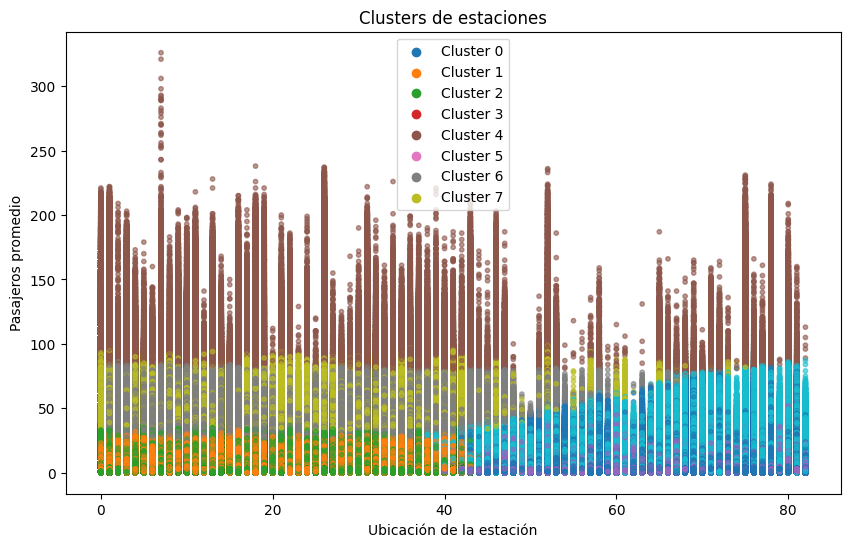

In [108]:
plt.figure(figsize=(10, 6))
plt.scatter(
    dfsinoutlierok['ESTACION_NUMERICA'], 
    dfsinoutlierok['TOTAL'], 
    c=dfsinoutlierok['cluster'], 
    cmap='tab10', 
    s=10, 
    alpha=0.6
)
for i in range(clusters):
    plt.scatter([], [], label=f'Cluster {i}', color=plt.cm.tab10(i / clusters))
plt.legend()
plt.xlabel('Ubicación de la estación')
plt.ylabel('Pasajeros promedio')
plt.title('Clusters de estaciones')

- El siguiente código muestra, de manera clara, las estaciones agrupadas dentro de cada cluster, permitiendo interpretar la segmentación realizada por el modelo K-Means.

In [109]:
# Mostrar nombres de estaciones por cluster
for cluster_num in sorted(dfsinoutlierok['cluster'].unique()):
    estaciones_en_cluster = dfsinoutlierok[dfsinoutlierok['cluster'] == cluster_num]['ESTACION'].unique()
    print(f"Cluster {cluster_num}: {', '.join(estaciones_en_cluster)}")


Cluster 0: PUAN, SAN PEDRITO, RIO DE JANEIRO, FLORES, CASTRO BARROS, CARABOBO, ACOYTE, PRIMERA JUNTA, PLAZA MISERERE, LORIA, CONGRESO, PLAZA DE MAYO, VENEZUELA, PERU, PATRICIOS, ONCE, HUMBERTO I, HOSPITALES, INCLAN, CASEROS, URQUIZA, JOSE MARIA MORENO, MEDALLA MILAGROSA, SAENZ PE<d1>A, PASCO, SAN JOSE, VARELA, INDEPENDENCIA., ENTRE RIOS, PICHINCHA, EMILIO MITRE, JUJUY, LIMA, BOEDO, ALBERTI, PZA. DE LOS VIRREYES, AVENIDA LA PLATA, CORRIENTES, BOLIVAR, PIEDRAS, CALLAO., BULNES, TRIBUNALES, GENERAL BELGRANO, SCALABRINI ORTIZ
Cluster 1: CONSTITUCION, ROSAS, LEANDRO N. ALEM, RETIRO, CARLOS PELLEGRINI, FEDERICO LACROZE, CONGRESO DE TUCUMAN, MEDRANO, DORREGO, LOS INCAS, MALABIA, ECHEVERRIA, 9 DE JULIO, MINISTRO CARRANZA, ANGEL GALLARDO, CARLOS GARDEL, CALLAO, CATEDRAL, JURAMENTO, PALERMO, JOSE HERNANDEZ, TRONADOR, OLLEROS, PLAZA ITALIA, PASTEUR, PUEYRREDON., AGUERO, SCALABRINI ORTIZ, BULNES, INDEPENDENCIA, SAN JUAN, PUEYRREDON, FACULTAD DE MEDICINA, GENERAL SAN MARTIN, CALLAO., URUGUAY, MARIA

**¿Cómo influye la variación de tarifas en la demanda de viajes?**


In [110]:
#CREO UN NUEVO DATAFRAME DENOMINADO dftarifa, AL CUAL LE VAMOS A AGRGAR UNA COLUMNA CON LOS PRECIOS DEL BOLETO MENSUALES.
#DE ESTA MANERA PODREMOS LUEGO COLOCAR UN NUEVO PRECIO Y PREDECIR CUAL VA A SER EL COMPORTAMIENTO DE LOS VIAJES.
dftarifa = dfsinoutlierok

In [111]:
#CREO UNA NUEVA FEATURE O COLUMNA CON EL NOMBRE FECHA_DATETIME Y CONVIERTO FECHA A FORMATO DATETIME, PARA PODER REALIZAR EL ANALISIS POSTERIOR.
dftarifa['FECHA_DATETIME'] = pd.to_datetime(dftarifa['FECHA'])

In [112]:
dftarifa.sample(3)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA,cluster,FECHA_DATETIME
4765664,2014-09-04,07:00:00,07:14:00,E,LINEA_E_VARELA_TURN01,VARELA,31,3,2,34,36,3,341,51,20140904,700,714,0,2014-09-04
6028010,2014-11-28,17:15:00,17:29:00,B,LINEA_B_ALEM_N_TURN03,LEANDRO N. ALEM,160,1,6,167,167,0,8,1,20141128,1715,1729,4,2014-11-28
6665402,2014-11-13,05:15:00,05:29:00,D,LINEA_D_OLLEROS_OESTE_TURN01,OLLEROS,0,1,2,0,3,2,274,33,20141113,515,529,1,2014-11-13


- El siguiente código tiene como objetivo vincular la información histórica de tarifas del subte con la fecha de cada viaje, para así analizar cómo la variación en el precio del boleto impactó en la demanda.

- Se asigna una tarifa mensual correspondiente al año 2014 a cada registro del DataFrame dftarifa, creando una nueva columna llamada “TARIFA”. 
- Esto permite evaluar la relación entre el precio del boleto y la cantidad de viajes realizados.

In [113]:
#CARGO LAS TARIFAS PARA EL AñO 2014. ESTE DATO SURJE DEL DATASET "registro historico precio del boleto".
#tarifa =[('ENERO',3.50),('FEBRERO',3.50), ('MARZO',4.50), ('ABRIL',4.50) , ('MAYO',4.50) ,('JUNIO',4.50), ('JULIO',4.50), ('AGOSTO',4.50 ),('SEPTIEMBRE',4.50), ('OCTUBRE',4.50) ,('NOVIEMBRE',4.50),('DICIEMBRE',4.50)]  
tarifadict ={1:3.50, 2:3.50, 3:4.50, 4:4.50 , 5:4.50 ,6:4.50, 7:4.50, 8:4.50, 9:4.50, 10:4.50, 11:4.50,12:4.50} 
#AGREGO UNA NUEVA FEATURE O COLUMNA CON EL NOMBRE "TARIFA", EL CUAL VA A TENER TODAS LAS TARIFAS ADAPTADAS A LAS FECHAS DEL DATAGRAME.
dftarifa['TARIFA'] = dftarifa['FECHA_DATETIME'].dt.month.map(tarifadict)

In [114]:
print(dftarifa.loc[dftarifa.sample(10).index, ['FECHA', 'TARIFA']])

               FECHA  TARIFA
1342671   2014-05-10     4.5
10608831  2014-04-02     4.5
8284630   2014-01-18     3.5
4868441   2014-09-11     4.5
8234917   2014-01-11     3.5
6994305   2014-12-14     4.5
6143297   2014-11-12     4.5
5087633   2014-10-26     4.5
148888    2014-04-29     4.5
5283349   2014-10-28     4.5


A continuación, realizo un codigo para poder visulizar y analizar cómo influye la tarifa en la cantidad de viajes mensuales (TOTAL):

In [115]:
# Extraer el mes como número
dftarifa['MES'] = dftarifa['FECHA_DATETIME'].dt.month

# Agrupar por mes y tarifa, y sumar los viajes
viajes_por_mes = dftarifa.groupby(['MES', 'TARIFA'])['TOTAL'].sum().reset_index()

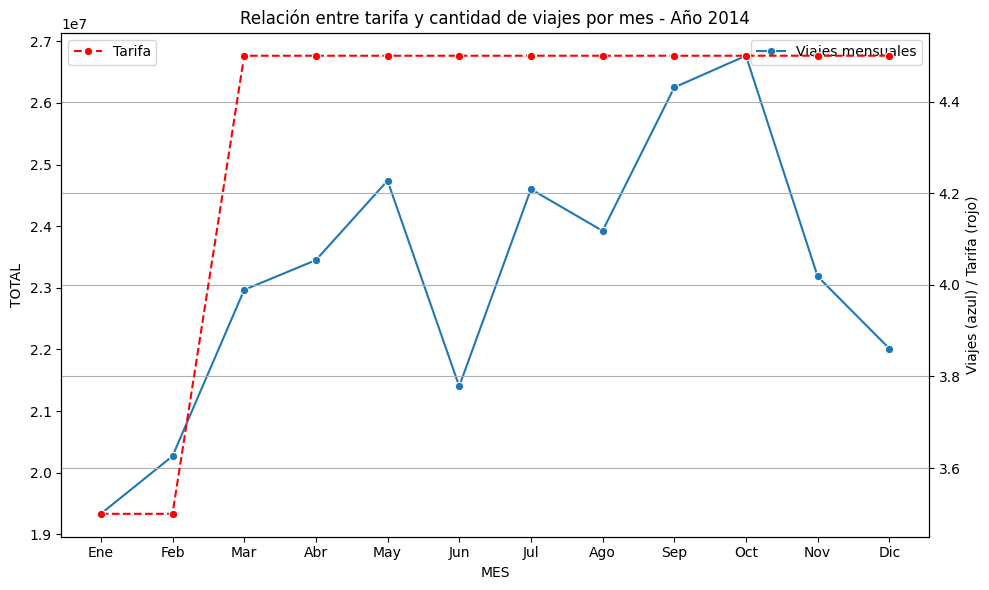

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=viajes_por_mes, x='MES', y='TOTAL', marker='o', label='Viajes mensuales')
plt.twinx()  # Crear segundo eje Y para mostrar tarifa
sns.lineplot(data=viajes_por_mes, x='MES', y='TARIFA', color='red', marker='o', label='Tarifa', linestyle='--')

plt.title('Relación entre tarifa y cantidad de viajes por mes - Año 2014')
plt.xlabel('Mes')
plt.ylabel('Viajes (azul) / Tarifa (rojo)')
plt.xticks(range(1,13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left')
plt.show()

In [117]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

- Preparado de datos para un modelo de regresión logística para analizar la probabilidad de que haya al menos un viaje (VIAJE = 1) en función de la tarifa aplicada.

In [118]:


# 1. Preparo los Datos
df_2014 = dftarifa[pd.to_datetime(dftarifa['FECHA']).dt.year == 2014]

# Me aseguro de que 'TARIFA' sea numérico
df_2014['TARIFA'] = pd.to_numeric(df_2014['TARIFA'], errors='coerce')

# Elimino filas con valores nulos en 'TARIFA'
df_2014 = df_2014.dropna(subset=['TARIFA'])





In [119]:
df_2014['VIAJE'] = (df_2014['TOTAL'] > 0).astype(int)

In [120]:
# Crear el modelo de regresión
model = LogisticRegression()

In [121]:
df_2014.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'PAX_PAGO',
       'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL', 'TOTAL', 'LINEA_NUMERICA',
       'MOLINETE_NUMERICO', 'ESTACION_NUMERICA', 'FECHA_NUMERICA',
       'DESDE_NUMERICA', 'HASTA_NUMERICA', 'cluster', 'FECHA_DATETIME',
       'TARIFA', 'MES', 'VIAJE'],
      dtype='object')

Este modelo permite analizar si la tarifa influye (positiva o negativamente) en la probabilidad de que una estación registre al menos un viaje en un determinado registro horario.

In [122]:
# Entrenar el modelo
model.fit(df_2014[['TARIFA']], df_2014['VIAJE'])

LogisticRegression()

El siguiente código predice la probabilidad de que se haga al menos un viaje si la tarifa del boleto es de $5.


- ¿Cómo lo hace?
- Usa un modelo de regresión logística ya entrenado.
- Le pasa como entrada la tarifa ($5 en este caso).
- Devuelve la probabilidad de que con esa tarifa ocurra al menos un viaje.


In [123]:
# 2. Realizar la Predicción
tarifa_prediccion = 5
prediccion_viajes = model.predict_proba([[tarifa_prediccion]])[:, 1]

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


- El siguiente codigo, muestra la probabilidad (en porcentaje) de que un usuario realice un viaje si la tarifa cuesta $5.

- Por ejemplo, para este caso, la salida es 0.83, lo que significa que hay un 83% de probabilidad de que con una tarifa de $5 alguien haga un viaje.

- Finalmente, agrupa todos los viajes del año 2014 por mes y suma la cantidad total de viajes realizados cada mes.

In [124]:
print(f"Probabilidad de que un usuario realice un viaje con tarifa $ {tarifa_prediccion}: {prediccion_viajes[0]:.2f}")

# 3. Analizar los Resultados
total_mensual_2014 = df_2014.groupby(pd.to_datetime(df_2014['FECHA']).dt.to_period('M'))['TOTAL'].sum()

print("\nTotal de viajes por mes en 2014:")
print(total_mensual_2014)

Probabilidad de que un usuario realice un viaje con tarifa $ 5: 0.83

Total de viajes por mes en 2014:
FECHA
2014-01    19333217
2014-02    20269210
2014-03    22966708
2014-04    23448607
2014-05    24737926
2014-06    21402004
2014-07    24599680
2014-08    23923808
2014-09    26250522
2014-10    26764577
2014-11    23184632
2014-12    22014779
Freq: M, Name: TOTAL, dtype: int64


/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


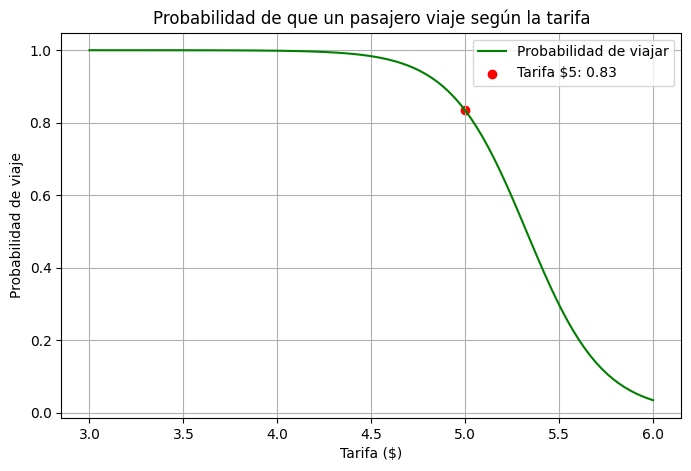

In [125]:

# Crear rango de tarifas simuladas (por si querés ver cómo varía la probabilidad con distintos precios)
tarifas_simuladas = np.linspace(3.0, 6.0, 100).reshape(-1, 1)
probabilidades_simuladas = model.predict_proba(tarifas_simuladas)[:, 1]

# Visualizar la curva de probabilidad
plt.figure(figsize=(8, 5))
plt.plot(tarifas_simuladas, probabilidades_simuladas, label="Probabilidad de viajar", color='green')
plt.scatter([5], [prediccion_viajes[0]], color='red', label=f'Tarifa $5: {prediccion_viajes[0]:.2f}')
plt.title("Probabilidad de que un pasajero viaje según la tarifa")
plt.xlabel("Tarifa ($)")
plt.ylabel("Probabilidad de viaje")
plt.legend()
plt.grid(True)
plt.show()

Podemps observar como la linea cae a partir de la tarifa $5.
Esto se debe a que el modelo solo vio dos valores de tarifa en los datos de entrenamiento.

	•	$3.50 en enero y febrero
	•	$4.50 desde marzo hasta diciembre

Por lo tanto, el modelo de regresión logística solo aprendió a distinguir entre tarifas de $3.50 y $4.50.

In [126]:
# Comparar con el total real (por ejemplo, el último mes de 2014)
ultimo_mes_2014 = total_mensual_2014.index[-1]
total_real_ultimo_mes = total_mensual_2014.iloc[-1]

In [127]:
# Simular el cambio de tarifa y predecir el impacto en el último mes
df_ultimo_mes = df_2014[pd.to_datetime(df_2014['FECHA']).dt.to_period('M') == ultimo_mes_2014]
df_ultimo_mes.loc[:,'TARIFA'] = tarifa_prediccion
prediccion_ultimo_mes = model.predict(df_ultimo_mes[['TARIFA']])

total_predicho_ultimo_mes = prediccion_ultimo_mes.sum()

print(f"\nTotal real de viajes en {ultimo_mes_2014}: {total_real_ultimo_mes}")
print(f"Total predicho de viajes en {ultimo_mes_2014} con tarifa {tarifa_prediccion}: {total_predicho_ultimo_mes:.2f}")

if total_predicho_ultimo_mes > total_real_ultimo_mes:
    print(f"Con la tarifa {tarifa_prediccion}, se predice un aumento de viajes.")
else:
    print(f"Con la tarifa {tarifa_prediccion}, se predice una disminución de viajes.")


Total real de viajes en 2014-12: 22014779
Total predicho de viajes en 2014-12 con tarifa 5: 1121107.00
Con la tarifa 5, se predice una disminución de viajes.


**Preparo la tabla con la probabilidad y los viajes predichos vs. los datos reales por mes.**

In [128]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Crear la base con los meses del 2014
meses = range(1, 13)
tarifa_dict = {1:3.50, 2:3.50, 3:4.50, 4:4.50, 5:4.50, 6:4.50, 7:4.50, 8:4.50, 9:4.50, 10:4.50, 11:4.50, 12:4.50}

# Agrupar los viajes reales por mes
viajes_reales = df_2014.groupby(pd.to_datetime(df_2014['FECHA']).dt.month)['TOTAL'].sum()

# Crear tabla para visualizar
tabla_resultados = pd.DataFrame({
    'MES': meses,
    'TARIFA': [tarifa_dict[m] for m in meses],
    'TOTAL_VIAJES_REALES': [viajes_reales.get(m, 0) for m in meses]
})

# Predecir probabilidad con el modelo entrenado
tabla_resultados['PROB_PREDICHA'] = model.predict_proba(tabla_resultados[['TARIFA']])[:,1]

tabla_resultados['VIAJES_PREDICHOS'] = tabla_resultados['PROB_PREDICHA'] * tabla_resultados['TOTAL_VIAJES_REALES']
tabla_resultados['VIAJES_PREDICHOS'] = tabla_resultados['VIAJES_PREDICHOS'].round().astype(int)

# Mostrar la tabla
print(tabla_resultados)

    MES  TARIFA  TOTAL_VIAJES_REALES  PROB_PREDICHA  VIAJES_PREDICHOS
0     1     3.5             19333217       0.999880          19330902
1     2     3.5             20269210       0.999880          20266783
2     3     4.5             22966708       0.983465          22586958
3     4     4.5             23448607       0.983465          23060889
4     5     4.5             24737926       0.983465          24328889
5     6     4.5             21402004       0.983465          21048126
6     7     4.5             24599680       0.983465          24192929
7     8     4.5             23923808       0.983465          23528232
8     9     4.5             26250522       0.983465          25816475
9    10     4.5             26764577       0.983465          26322030
10   11     4.5             23184632       0.983465          22801279
11   12     4.5             22014779       0.983465          21650769


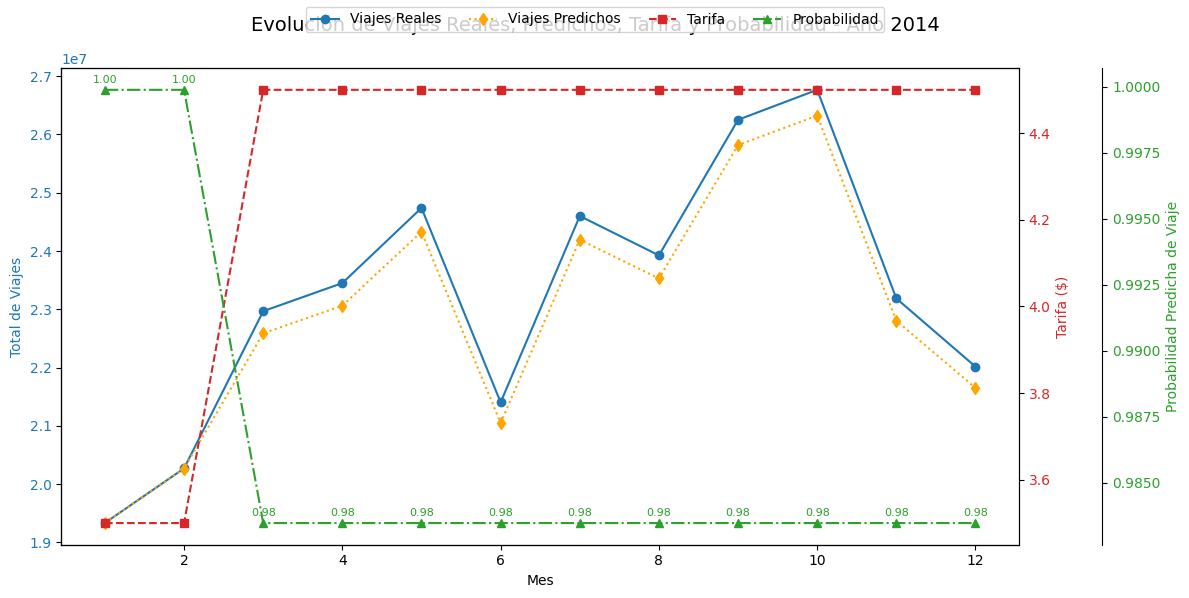

In [129]:


fig, ax1 = plt.subplots(figsize=(12, 6))

# Primer eje: Total de viajes reales
color1 = 'tab:blue'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Total de Viajes', color=color1)
ax1.plot(tabla_resultados['MES'], tabla_resultados['TOTAL_VIAJES_REALES'], 
         color=color1, marker='o', label='Viajes Reales')
ax1.plot(tabla_resultados['MES'], tabla_resultados['VIAJES_PREDICHOS'], 
         color='orange', linestyle=':', marker='d', label='Viajes Predichos')
ax1.tick_params(axis='y', labelcolor=color1)

# Segundo eje: Tarifa
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Tarifa ($)', color=color2)
ax2.plot(tabla_resultados['MES'], tabla_resultados['TARIFA'], 
         color=color2, linestyle='--', marker='s', label='Tarifa')
ax2.tick_params(axis='y', labelcolor=color2)

# Tercer eje: Probabilidad predicha
ax3 = ax1.twinx()
color3 = 'tab:green'
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Probabilidad Predicha de Viaje', color=color3)
ax3.plot(tabla_resultados['MES'], tabla_resultados['PROB_PREDICHA'], 
         color=color3, linestyle='-.', marker='^', label='Probabilidad')
ax3.tick_params(axis='y', labelcolor=color3)

# Título y leyenda
fig.suptitle('Evolución de Viajes Reales, Predichos, Tarifa y Probabilidad - Año 2014', fontsize=14)
fig.tight_layout()

for i, prob in enumerate(tabla_resultados['PROB_PREDICHA']):
    ax3.annotate(f"{prob:.2f}", 
                 (tabla_resultados['MES'][i], prob),
                 textcoords="offset points",
                 xytext=(0,5), 
                 ha='center',
                 fontsize=8,
                 color=color3)

# Agregar leyendas manualmente
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2, ax3]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
fig.legend(lines, labels, loc='upper center', ncol=4)

plt.show()

Este gráfico permite ver de forma clara:
1. •	Cuántos viajes reales se realizaron por mes. LINEA AZUL
2. •	Cómo fue evolucionando la tarifa. LINEA ROJA
3. •	Cómo respondió el modelo ante los cambios de tarifa. LINEA VERDE
4. •	Viajes predichos por el modelo. LINEA NARANJA

- Tambien, podemos observar como la línea verde de probabilidad predicha se mantiene plana a partir del mes 3.

- Esto se debe a que a partir de ese punto la tarifa deja de cambiar.

In [130]:
dftarifa.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,...,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA,cluster,FECHA_DATETIME,TARIFA,MES
982773,2014-05-06,18:00:00,18:14:00,A,LINEA_A_LIMA_N_TURN01,LIMA,48,1,2,48,...,5,486,73,20140506,1800,1814,7,2014-05-06,4.5,5
189963,2014-04-08,21:00:00,21:14:00,C,LINEA_C_CONSTITUCION_TURN24,CONSTITUCION,4,1,2,4,...,1,156,18,20140408,2100,2114,2,2014-04-08,4.5,4
4206135,2014-09-24,17:45:00,17:59:00,A,LINEA_A_PMAYO_E_TURN04,PLAZA DE MAYO,98,1,2,99,...,5,534,75,20140924,1745,1759,4,2014-09-24,4.5,9
759489,2014-05-01,15:45:00,15:59:00,B,LINEA_B_DORREGO_N_TURN02,DORREGO,2,1,2,2,...,0,92,14,20140501,1545,1559,2,2014-05-01,4.5,5
6269902,2014-11-26,12:00:00,12:14:00,A,LINEA_A_SNZPENA_S_TURN03,SAENZ PE<d1>A,42,1,5,47,...,5,479,77,20141126,1200,1214,7,2014-11-26,4.5,11


- El siguiente código, permite realizar una predicción personalizada del volumen de viajes esperados en función de condiciones específicas seleccionadas por el usuario. 

- Descripción del código:
Este modelo toma como entrada cinco variables clave que afectan la demanda de viajes:
	1.	Tarifa actual ($)
	2.	Mes del año (1 a 12)
	3.	Día de la semana (0=Lunes, 6=Domingo)
	4.	Hora del día (rango de 0 a 23)
	5.	Estación (identificada por su código numérico según el dataset dftarifa)

Estas variables son transformadas mediante un StandardScaler (para escalar los datos de forma coherente con el entrenamiento del modelo) y luego se pasan al modelo predictivo previamente entrenado.

El resultado es una estimación de la cantidad de viajes que se espera bajo las condiciones ingresadas.

- Este enfoque multivariable permite capturar patrones temporales y espaciales del comportamiento de los usuarios, y evaluar cómo responden ante cambios tarifarios en distintos contextos operativos.

In [131]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Preparar los datos
df_2014 = dftarifa[pd.to_datetime(dftarifa['FECHA']).dt.year == 2014]
df_2014['TARIFA'] = pd.to_numeric(df_2014['TARIFA'], errors='coerce')
df_2014 = df_2014.dropna(subset=['TARIFA'])
df_2014['MES'] = pd.to_datetime(df_2014['FECHA']).dt.month
df_2014['DIA_SEMANA'] = pd.to_datetime(df_2014['FECHA']).dt.dayofweek
df_2014['HORA_DIA'] = pd.to_datetime(df_2014['FECHA']).dt.hour

# Definir las variables independientes y dependiente
X = df_2014[['TARIFA', 'MES', 'DIA_SEMANA', 'HORA_DIA', 'ESTACION_NUMERICA']]
y = df_2014['TOTAL']

# Escalar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)




In [132]:
# Entrenar el modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

In [133]:
# Realizar predicciones
y_pred = model.predict(X_test)



In [134]:
# Evaluar el modelo
reg_score=r2_score(y_test,y_pred)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_pred)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)



R2 (Coeficiente de Determinacion): 0.23159552500838332
MSE (Error Cuadratico Medio): 556.4277348743232
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 23.58872050100054


In [135]:
# INGRESAR VARIABLES PARA REALIZAR LA PREDICCION
# Ingresar la tarifa, mes, día de la semana, hora del día y estación (EN NUMERO: VISUALIZAR del DATADSET dftarifa PREVIAMENTE) para realizar la predicción
tarifa_prediccion = int(input("Ingrese la tarifa de predicción: "))
mes_prediccion = int(input("Ingrese el mes de predicción (1-12): "))
dia_semana_prediccion = int(input("Ingrese el día de la semana de predicción (0-6): "))
hora_dia_prediccion = int(input("Ingrese la hora del día de predicción (0-23): "))
estacion_prediccion = int(input("Ingrese la estación (NUMERO) de predicción : "))

# Realizar la predicción
prediccion_viajes = model.predict(scaler.transform([[tarifa_prediccion, mes_prediccion, dia_semana_prediccion, hora_dia_prediccion, estacion_prediccion]]))

# Imprimir la predicción
print(f'Predicción de viajes para la tarifa ${tarifa_prediccion} en el mes {mes_prediccion}, día {dia_semana_prediccion}, hora {hora_dia_prediccion} y estación {estacion_prediccion}: {prediccion_viajes[0]}')

Predicción de viajes para la tarifa $8 en el mes 4, día 3, hora 9 y estación 32: 33.321754750166924


/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


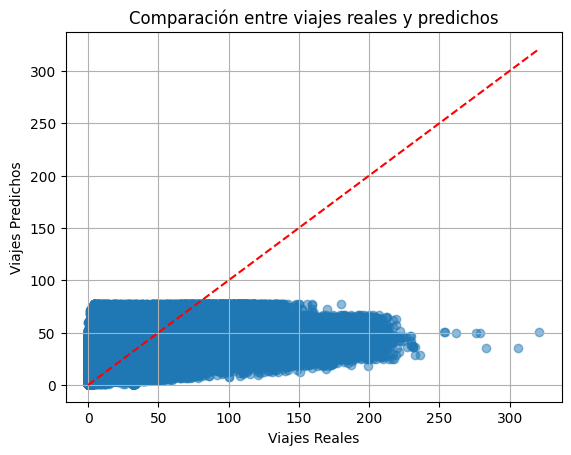

In [136]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Viajes Reales")
plt.ylabel("Viajes Predichos")
plt.title("Comparación entre viajes reales y predichos")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()

In [137]:
dftarifa.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,...,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA,cluster,FECHA_DATETIME,TARIFA,MES
6054138,2014-11-01,03:00:00,03:14:00,A,LINEA_A_ACOYTE_N_TURN03,ACOYTE,31,1,1,1,...,5,481,68,20141101,300,314,0,2014-11-01,4.5,11
3600437,2014-08-11,13:15:00,13:29:00,C,LINEA_C_AVMAYO_N_TURN02,AVENIDA DE MAYO,27,1,2,29,...,1,191,23,20140811,1315,1329,5,2014-08-11,4.5,8
5779264,2014-10-18,20:30:00,20:44:00,H,LINEA_H_VENEZUELA_NORTE_TURN01,VENEZUELA,2,1,2,2,...,4,396,64,20141018,2030,2044,3,2014-10-18,4.5,10
380331,2014-04-19,09:00:00,09:14:00,D,LINEA_D_CONGRESOTUC_S_TURN02,CONGRESO DE TUCUMAN,16,1,2,16,...,2,321,31,20140419,900,914,1,2014-04-19,4.5,4
9223677,2014-02-23,11:00:00,11:14:00,B,LINEA_B_MEDRANO_N_TURN03,MEDRANO,1,1,2,1,...,0,29,4,20140223,1100,1114,1,2014-02-23,3.5,2


In [138]:
#DECIDO GRABAR EL DATAFRAME "dftarifa" PARA PODER UTILIZAROLO EN FUTUROS ANALISIS.
dftarifa.to_csv('dftarifa.csv', index=False)

# PRUEBA DE DISTINTOS MODELOS DE PREDICCION.

**OBJETIVO: PREDECIR EL TOTAL DE PASAJEROS QUE VAN A UTILIZAR EL SUBTERANEO EN FUNCION A TODAS LAS OTRAS VARIABLES DEL DATAFRAME**


- **Interpretacion de los resultados.**

1. *R2 (Coeficiente de Determinación)*:

    - Mide la proporción de varianza en la variable dependiente que es explicada por el modelo.
    - Valores de R2:

    - 1: El modelo explica perfectamente la varianza en la variable dependiente.
    - 0: El modelo no explica nada de la varianza en la variable dependiente.
    - Menores a 0: El modelo es peor que uno que simplemente utilice la media de la variable dependiente.

2. *MSE (Error Cuadrático Medio)*:

    - Mide la cantidad promedio de error en las predicciones del modelo.
    - Se calcula como la suma de los errores al cuadrado dividida por el número de observaciones.
    - Valores de MSE:

    - 0: El modelo hace predicciones perfectas.
    - Mayores a 0: El modelo comete errores en sus predicciones.

3. *RMSE (Raíz Cuadrada del Error Cuadrático Medio)*:

    - Es la raíz cuadrada del MSE.
    - Mide la cantidad promedio de error en las predicciones del modelo en las mismas unidades que la variable dependiente.
    - Valores de RMSE:

    - 0: El modelo hace predicciones perfectas.
    - Mayores a 0: El modelo comete errores en sus predicciones.


# MODELO: "LinearRegression" 

- A continuacion, defino las variables predictoras (X) y la variable objetivo (y) para entrenar un modelo de aprendizaje automático.
1. •	Variable objetivo (y): corresponde a 'PAX_PAGO', que representa la cantidad de pasajeros que abonaron su pasaje. Es la variable que el modelo intentará predecir.
2. •	Variables predictoras (x): se seleccionan solo aquellas columnas que no están derivadas directamente de 'PAX_PAGO', para evitar sesgos o sobreajuste. 
- Estas variables incluyen información numérica sobre:
- 	LINEA_NUMERICA: la línea del subterráneo (codificada numéricamente)
- 	MOLINETE_NUMERICO: el identificador del molinete
- 	ESTACION_NUMERICA: el identificador de la estación
- 	FECHA_NUMERICA: la fecha del registro, transformada a un valor numérico
- 	DESDE_NUMERICA y HASTA_NUMERICA: intervalos horarios codificados

In [139]:
# Redefinir variables predictoras sin columnas derivadas directamente del target
x = dfentrenamiento[['LINEA_NUMERICA','MOLINETE_NUMERICO','ESTACION_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA']]
y = dfentrenamiento['PAX_PAGO']

- En el siguiente código, divido el conjunto de datos en dos partes: entrenamiento y prueba.

In [140]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(8685794, 6) (2171449, 6) (8685794,) (2171449,)


- En el siguiente codigo, entreno el modelo de regresión lineal utilizando el conjunto de datos de entrenamiento.
- Este modelo servirá luego para hacer predicciones sobre nuevos datos y evaluar su rendimiento.

In [141]:


modelesc = linear_model.LinearRegression()
modelesc.fit(X_train, y_train)



LinearRegression()

- El siguiente codigo, realizo las predicciones usando los datos que no se usaron durante el entrenamiento (X_test).

- 	•	El resultado (y_predLR) es un arreglo con los valores estimados de PAX_PAGO para cada muestra del conjunto de prueba.

- Estas predicciones se compararán luego con los valores reales (y_test) para evaluar el rendimiento del modelo.

In [142]:
#Realizo la prediccion
y_predLR= modelesc.predict(X_test)

- Metricas de rendmiento.
- . Se evalúa el rendimiento del modelo entrenado.

In [143]:
# Evaluo el modelo
reg_score=r2_score(y_test,y_predLR)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_predLR)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

R2 (Coeficiente de Determinacion): 0.04349629184324699
MSE (Error Cuadratico Medio): 667.8683429318809
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 25.843148858679758


**Validacion Cruzada**

- La validación cruzada nos permite obtener una evaluación más robusta y realista del rendimiento del modelo al considerar diferentes particiones del conjunto de datos.
- Esto reduce el riesgo de sobreajuste.

In [144]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error
import numpy as np

# Definir el modelo
modelesc = linear_model.LinearRegression()

# Realizar cross-validation utilizando K-Folds (por ejemplo, 5 folds)
scores = cross_val_score(modelesc, X_train, y_train, cv=5, scoring='r2')  # Evaluar con R²

# Imprimir el rendimiento de R² en cada fold
print(f'R² en cada fold: {scores}')
print(f'Media de R²: {np.mean(scores)}')

# Predicciones utilizando cross-validation
y_pred_cv = cross_val_predict(modelesc, X_train, y_train, cv=5)

# Calcular MSE y RMSE
mse_cv = mean_squared_error(y_train, y_pred_cv)
rmse_cv = np.sqrt(mse_cv)

# Imprimir resultados de evaluación
print(f'MSE (Error Cuadrático Medio) con Cross-Validation: {mse_cv}')
print(f'RMSE (Raíz Cuadrada del Error Cuadrático Medio) con Cross-Validation: {rmse_cv}')

R² en cada fold: [0.04304713 0.0435152  0.04333217 0.04340118 0.0442256 ]
Media de R²: 0.0435042537512413
MSE (Error Cuadrático Medio) con Cross-Validation: 666.0595927248944
RMSE (Raíz Cuadrada del Error Cuadrático Medio) con Cross-Validation: 25.808130360893916


**GRAFICOS DE VISALIZACION DE RESUTADOS**

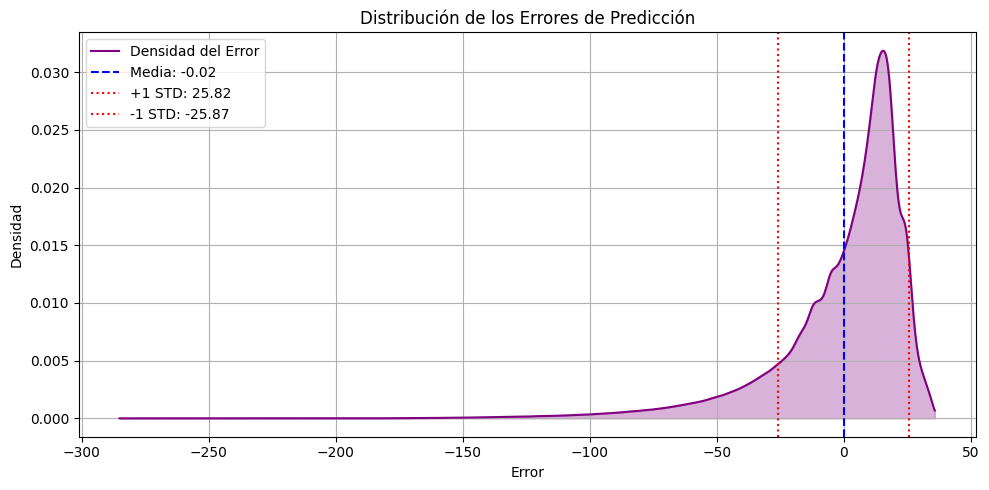

In [145]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Calcular los errores
errores = y_predLR - y_test

# Estadísticas
media_error = np.mean(errores)
std_error = np.std(errores)

# KDE (curva de densidad)
kde = gaussian_kde(errores)
x_vals = np.linspace(min(errores), max(errores), 1000)
densidad = kde(x_vals)

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(x_vals, densidad, color='purple', label='Densidad del Error')
plt.fill_between(x_vals, densidad, alpha=0.3, color='purple')

# Líneas de media y desviaciones estándar
plt.axvline(media_error, color='blue', linestyle='--', label=f'Media: {media_error:.2f}')
plt.axvline(media_error + std_error, color='red', linestyle=':', label=f'+1 STD: {media_error + std_error:.2f}')
plt.axvline(media_error - std_error, color='red', linestyle=':', label=f'-1 STD: {media_error - std_error:.2f}')

# Detalles del gráfico
plt.title('Distribución de los Errores de Predicción')
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Este grafico nos muestra la curva de densidad de los errores (predicción - valor real). 
- Si la curva está centrada en 0 y es simétrica, indica que los errores están equilibrados (ni sobreestima ni subestima sistemáticamente). 
- Si está sesgada hacia un lado, podría indicar un sesgo del modelo.

- Por otro lado, nos muestra que tan centrados estan los errores( ideal cerca de 0 ) y cuanta dispersion hay en torno a la media ( desviacion estandar)


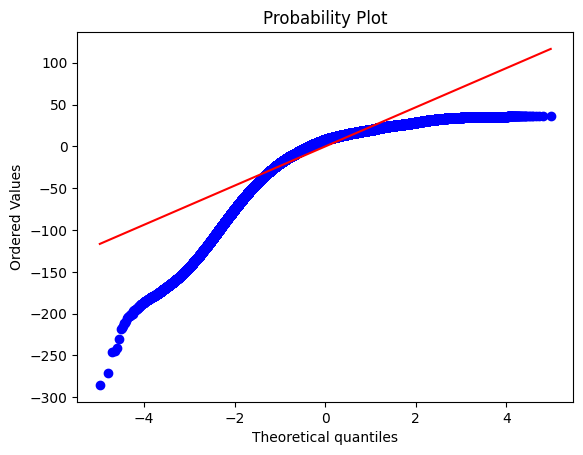

In [146]:
errores = y_predLR - y_test
stats.probplot(errores, dist="norm", plot=plt)
plt.show()

El grafico se interpreta de la siguiente manera:
1. •	Línea diagonal: representa la distribución normal teórica.

2. •	Puntos:
- •	Si siguen la línea, los errores tienen una distribución aproximadamente normal (ideal para muchos modelos).
- •	Si se desvían mucho, especialmente en los extremos, indica que hay colas pesadas o asimetrías, lo cual puede afectar el rendimiento del modelo o la validez de ciertas métricas estadísticas.

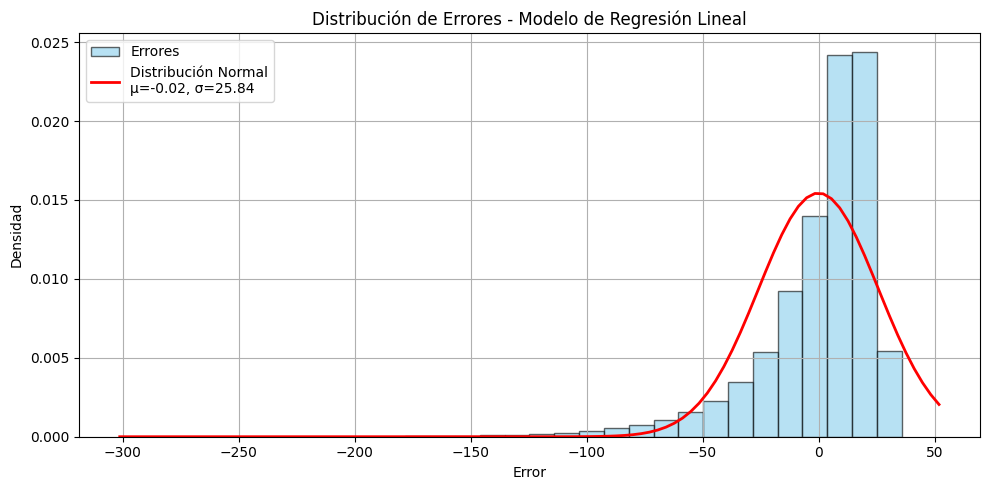

In [147]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Calcular errores
errores = y_predLR - y_test

# Crear histograma
plt.figure(figsize=(10, 5))
n, bins, patches = plt.hist(errores, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Errores')

# Ajustar una distribución normal
mu, std = norm.fit(errores)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# Superponer curva normal
plt.plot(x, p, 'r', linewidth=2, label=f'Distribución Normal\nμ={mu:.2f}, σ={std:.2f}')
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.title('Distribución de Errores - Modelo de Regresión Lineal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Este gráfico te ayuda a visualizar qué tan bien se ajustan los errores a una distribución normal. Si la curva roja se alinea bien con el histograma, es una buena señal.

- Tabla comparativa entre las primeras 10 predicciones del modelo y los valores reales correspondientes de "PAX_PAGO".

In [148]:
target = "PAX_PAGO"

# Resetear el índice para poder hacer join correctamente
X_test_reset = X_test.reset_index()
y_test_reset = y_test.reset_index()
y_pred_series = pd.Series(y_predLR, name='PREDICCION')

# Combinar todo en una sola tabla
tabla_comparacion = pd.concat([y_test_reset, y_pred_series], axis=1)

# Agregar columna de diferencia absoluta
tabla_comparacion['DIFERENCIA'] = abs(tabla_comparacion['PREDICCION'] - tabla_comparacion[target])

# Agregar las columnas de contexto desde X_test
tabla_comparacion['FECHA_NUMERICA'] = X_test_reset['FECHA_NUMERICA']
tabla_comparacion['LINEA_NUMERICA'] = X_test_reset['LINEA_NUMERICA']

# Mostrar solo las primeras 10 filas
print(tabla_comparacion[['PREDICCION', target, 'DIFERENCIA', 'FECHA_NUMERICA', 'LINEA_NUMERICA']].head(10))

   PREDICCION  PAX_PAGO  DIFERENCIA  FECHA_NUMERICA  LINEA_NUMERICA
0   27.150686        33    5.849314        20140108               0
1   26.069113        13   13.069113        20141203               1
2   25.144175         6   19.144175        20140109               0
3   34.929495        16   18.929495        20140117               0
4   23.168274         1   22.168274        20141017               2
5   20.819968        45   24.180032        20140514               3
6   14.358759        10    4.358759        20140521               5
7   14.084853        11    3.084853        20140727               5
8   20.056288        15    5.056288        20140623               4
9   16.436376         3   13.436376        20141220               5


**CONCLUSIONES DEL MODELO**

- El modelo de regresión lineal muestra bajo poder predictivo (R² ≈ 0.0435), explicando apenas el 4.35% de la variabilidad en PAX_PAGO. 
- El RMSE de ~25.8 indica errores significativos en las predicciones. 
- Los resultados son consistentes entre los folds, pero el modelo es débil. 
- Las variables actuales podrían no ser suficientes o no capturar relaciones no lineales. 
- Se recomienda probar modelos más complejos e incorporar nuevas variables para mejorar el rendimiento.

In [149]:
#Algunas Pruebas de conversiones de timestamp a fecha

timestamp = 1417564800000000000  
fecha = pd.to_datetime(timestamp, unit='ns')
print(fecha)

timestamp = 1741595400000000000  
time = pd.to_datetime(timestamp, unit='ns')
print(time)



2014-12-03 00:00:00
2025-03-10 08:30:00


# Modelo : "Ridge"

In [150]:
from sklearn.preprocessing import LabelEncoder

In [151]:
#CREO ESTE NUEVO DATASET df3 PARA UTILIZARLO EN EL MODELO RIDGE.
df3=dfentrenamiento


In [152]:
df3.columns
df3.head(10)

,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,TOTAL,LINEA_NUMERICA,MOLINETE_NUMERICO,ESTACION_NUMERICA,FECHA_NUMERICA,DESDE_NUMERICA,HASTA_NUMERICA
5845761,317,2,2,321,0,46,7,20141105,830,844
5845760,316,3,7,326,0,46,7,20141105,815,829
5885983,303,0,3,306,0,46,7,20141110,800,814
5861850,295,1,2,298,0,46,7,20141107,815,829
5853805,292,0,1,293,0,46,7,20141106,815,829
5861852,287,3,0,290,0,46,7,20141107,845,859
5885984,287,2,3,292,0,46,7,20141110,815,829
5837714,286,2,2,290,0,46,7,20141104,800,814
5837716,285,2,2,289,0,46,7,20141104,830,844
5853804,284,3,2,289,0,46,7,20141106,800,814


**DETERMINO Y=TARGET A ANALIZAR Y X=FEATURES RESTANTES DEL DATASET (dfentrenamiento) PREPARADO CON TODOS SUS VALORES NUMERICOS**

In [153]:


#DETERMINO EL TARGET
target='PAX_PAGO'


#SELECCIONO LAS COLUMNAS QUE ME INTERESAN INCORPORAR AL ANALISIS
df3=df3[['PAX_PAGO', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'TOTAL','LINEA_NUMERICA','MOLINETE_NUMERICO','ESTACION_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA']]
x=df3[['PAX_PASES_PAGOS', 'PAX_FRANQ', 'TOTAL','LINEA_NUMERICA','MOLINETE_NUMERICO','ESTACION_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA']]
y=df3[target]

- En el siguiente codigo, primero, divido el dataset en un 80% para entrenamiento y un 20% para prueba utilizando train_test_split. 


In [154]:
#DIVIDO EL DATASET EN TRAIN Y TEST
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

- Luego, aplico la clase StandardScaler para normalizar las variables predictoras, ajustándolas para que tengan media 0 y desviación estándar 1. 
- Esta normalización se realiza con "fit_transform" sobre el conjunto de entrenamiento y con "transform" sobre el conjunto de prueba, asegurando así consistencia en la escala de los datos.

## X_train_scaled & X_test_scaled
**Conjunto de datos que se van a utilizar para los siguietes modelos de prediccion.**

In [155]:


#Utilizo la clasa StandardScaler para escalar los datos de manera que tengan una media 0 y una desviación estándar 1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- El siguiente codigo, "print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)" muestra las dimensiones de los conjuntos de datos utilizados para entrenar (X_train) y probar (X_test) el modelo.

- Esto permite verificar que la división y la forma de los datos se haya realizado correctamente.

In [156]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(8685794, 9) (2171449, 9) (8685794,) (2171449,)


- En el siguiente codigo, utilizo el modelo SelectKBest para realizar identificar las variables predictoras más relevantes para el modelo.

1.  Se define la cantidad de características a seleccionar (k=4).
2. 	Se ajusta el selector a los datos escalados de entrenamiento y se transforman ambos conjuntos (entrenamiento y prueba) conservando solo las 4 características más relevantes.

- Este proceso ayuda a mejorar el rendimiento del modelo al reducir la dimensionalidad y eliminar información irrelevante o redundante.


In [157]:
#UTILIZO EL MODELO SELECTKBEST PARA SELECCIONAR LAS MEJORES CARACTERISTICAS.
# Ingresar la csntidad de caracteristicas que se desean seleccionar.
selectk = 4

selector = SelectKBest(k= selectk)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

- El siguiente codigo, devuelve un array booleano (True / Felse), que indica qué variables fueron seleccionadas por SelectKBest.
1. •	Cada posición del array corresponde a una columna de las variables originales (en este caso, de X_train_scaled).
2. •	El valor será True si esa característica fue seleccionada entre las k mejores (en tu caso, 4), y False si no lo fue.

- Esto permite identificar cuáles columnas originales fueron consideradas más relevantes para predecir la variable objetivo.

In [158]:
#VISUALIZO LAS CARACTERISTICAS SELECCIONADAS 
print(selector.get_support())

[False  True  True False  True False  True False False]


- El siguiente codigo, permite identificar los nombres de las variables seleccionadas por SelectKBest en el codigo anterior.

In [159]:
caracteristicas = selector.get_support()
caracteristicas_selec = X_train.columns[caracteristicas]
print(' Features Seleccionadas por KBest')
print(caracteristicas_selec)

 Features Seleccionadas por KBest
Index(['PAX_FRANQ', 'TOTAL', 'MOLINETE_NUMERICO', 'FECHA_NUMERICA'], dtype='object')


- •	En el siguiente codigo, creo una instancia del modelo Ridge Regression, una variante de la regresión lineal que incorpora regularización L2.
- •	El parámetro alpha=0.1 controla la intensidad de la regularización. 
- Valores más altos penalizan más los coeficientes grandes, lo que puede reducir el sobreajuste y mejorar la generalización del modelo.

- Ridge es especialmente útil cuando hay multicolinealidad entre las variables o cuando se quiere evitar que el modelo se ajuste demasiado a los datos de entrenamiento.
- . La multicolinealidad ocurre cuando dos o más variables predictoras (features) están altamente correlacionadas entre sí.


In [160]:
#CREO EL MODELO RIDGE
ridge = Ridge(alpha=0.1)

- El siguiente codigo, entrena el modelo "Ridge" con los datos ya seleccionados y escalados.

- 	Durante el entrenamiento, el modelo encuentra los coeficientes que mejor predicen PAX_PAGO, aplicando una penalización L2 para controlar el sobreajuste y mitigar la multicolinealidad.

In [161]:
ridge.fit(X_train_selected, y_train)

Ridge(alpha=0.1)

In [162]:
#REALIZO LA PREDICCION
y_predridge = ridge.predict(X_test_selected)

**Metricas de rendmiento.**

- . Se evalúa el rendimiento del modelo entrenado.

In [163]:
# Evaluo el modelo
reg_score=r2_score(y_test,y_predridge)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_predridge)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

R2 (Coeficiente de Determinacion): 0.99972889697765
MSE (Error Cuadratico Medio): 0.18929474580879233
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 0.43508016021049767


In [164]:
print(X_train_selected.shape,X_test_selected.shape,y_train.shape,y_test.shape)

(8685794, 4) (2171449, 4) (8685794,) (2171449,)


**GRAFICOS DE VISALIZACION DE RESUTADOS**

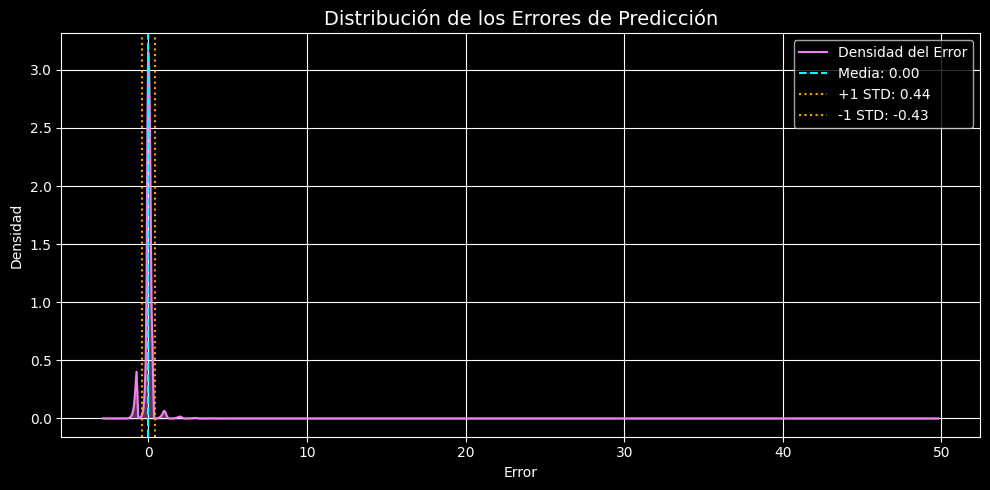

In [165]:
# Calcular los errores
errores = y_predridge - y_test

# Estadísticas
media_error = np.mean(errores)
std_error = np.std(errores)

# KDE (curva de densidad)
kde = gaussian_kde(errores)
x_vals = np.linspace(min(errores), max(errores), 1000)
densidad = kde(x_vals)

# Gráfico
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.plot(x_vals, densidad, color='violet', label='Densidad del Error')
plt.fill_between(x_vals, densidad, alpha=0.4, color='violet')

# Líneas de media y desviaciones estándar
plt.axvline(media_error, color='cyan', linestyle='--', label=f'Media: {media_error:.2f}')
plt.axvline(media_error + std_error, color='orange', linestyle=':', label=f'+1 STD: {media_error + std_error:.2f}')
plt.axvline(media_error - std_error, color='orange', linestyle=':', label=f'-1 STD: {media_error - std_error:.2f}')

# Detalles del gráfico
plt.title('Distribución de los Errores de Predicción', fontsize=14)
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


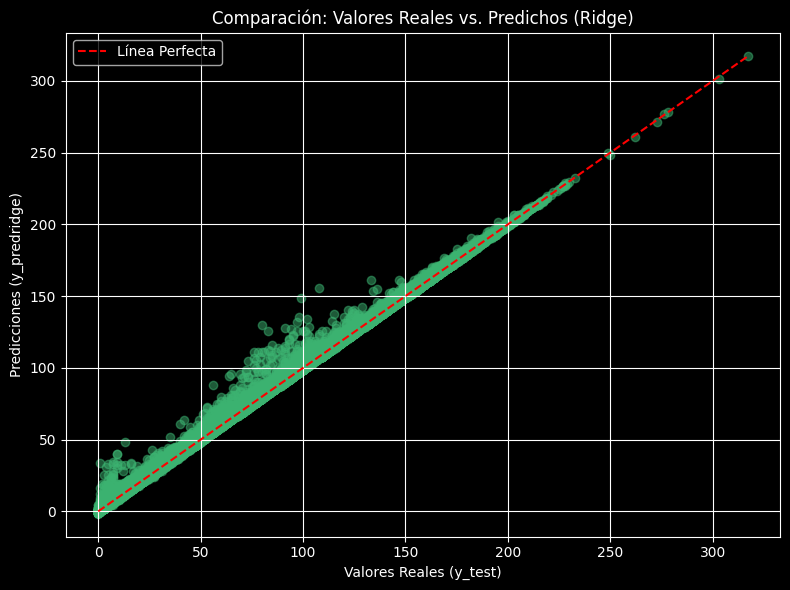

In [166]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predridge, color='mediumseagreen', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Perfecta')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_predridge)')
plt.title('Comparación: Valores Reales vs. Predichos (Ridge)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

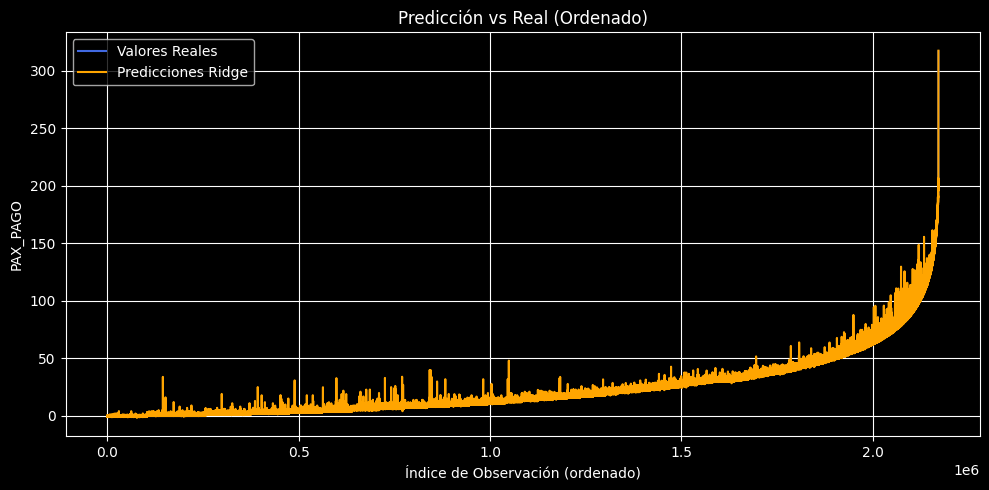

In [167]:
# Ordeno por y_test para que se vean más alineadas las curvas
y_test_sorted = np.array(y_test).flatten()
y_pred_sorted = np.array(y_predridge).flatten()
indices = np.argsort(y_test_sorted)

plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted[indices], label='Valores Reales', color='royalblue')
plt.plot(y_pred_sorted[indices], label='Predicciones Ridge', color='orange')
plt.title('Predicción vs Real (Ordenado)')
plt.xlabel('Índice de Observación (ordenado)')
plt.ylabel('PAX_PAGO')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

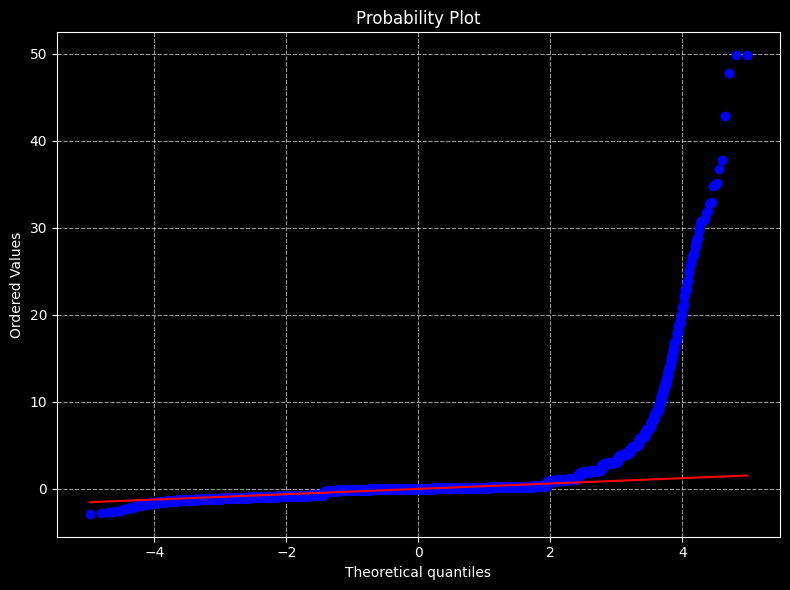

In [168]:

# Cálculo de los errores
errores = y_predridge - y_test
errores = np.array(errores).flatten()

# Estilo visual
plt.figure(figsize=(8, 6))
plt.title("Gráfico Q-Q de los Errores (Modelo Ridge)", fontsize=14)
plt.xlabel("Cuantiles Teóricos (Distribución Normal)")
plt.ylabel("Cuantiles Observados (Errores)")
plt.grid(True, linestyle='--', alpha=0.6)

# Q-Q plot mejorado
stats.probplot(errores, dist="norm", plot=plt)

# Ajuste final
plt.tight_layout()
plt.show()

In [169]:
target = "PAX_PAGO"

# Resetear el índice para poder hacer join correctamente
X_test_reset = X_test.reset_index()
y_test_reset = y_test.reset_index()
y_pred_series = pd.Series(y_predridge, name='PREDICCION')

# Combinar todo en una sola tabla
tabla_comparacion = pd.concat([y_test_reset, y_pred_series], axis=1)

# Agregar columna de diferencia absoluta
tabla_comparacion['DIFERENCIA'] = abs(tabla_comparacion['PREDICCION'] - tabla_comparacion[target])

# Agregar las columnas de contexto desde X_test
tabla_comparacion['FECHA_NUMERICA'] = X_test_reset['FECHA_NUMERICA']
tabla_comparacion['LINEA_NUMERICA'] = X_test_reset['LINEA_NUMERICA']

# Mostrar solo las primeras 10 filas
print(tabla_comparacion[['PREDICCION', target, 'DIFERENCIA', 'FECHA_NUMERICA', 'LINEA_NUMERICA']].head(10))

   PREDICCION  PAX_PAGO  DIFERENCIA  FECHA_NUMERICA  LINEA_NUMERICA
0   32.891617        33    0.108383        20140108               0
1   13.259220        13    0.259220        20141203               1
2    5.872984         6    0.127016        20140109               0
3   15.940521        16    0.059479        20140117               0
4    1.158333         1    0.158333        20141017               2
5   44.896332        45    0.103668        20140514               3
6   10.024676        10    0.024676        20140521               5
7   11.037894        11    0.037894        20140727               5
8   15.055307        15    0.055307        20140623               4
9    3.247637         3    0.247637        20141220               5


**EL MODELO RIDGE FUE BASTANTE EFICIENTE Y EXACTO CON SUS PREDICCIONES**

**Conclusión General:**
- Evaluación del modelo Ridge

1. R² (Coeficiente de determinación): 0.9997
- •	Indica que el modelo explica el 99.97% de la variabilidad en PAX_PAGO.
- •	Es un resultado muy alto, lo que sugiere un excelente ajuste del modelo a los datos de prueba.

2. MSE (Error Cuadrático Medio): 0.1893
- •	Es el promedio del cuadrado de los errores entre las predicciones y los valores reales.
- •	Cuanto menor, mejor. Un valor bajo como este indica que los errores son pequeños.

3. RMSE (Raíz del Error Cuadrático Medio): 0.4351
- •	Es más interpretable porque está en las mismas unidades que PAX_PAGO.
- •	Un RMSE bajo confirma que las predicciones son muy cercanas a los valores reales.

- El modelo Ridge con selección de características está funcionando de manera sobresaliente. 
- Si los datos no están sobreajustados (es decir, si se repite el rendimiento con otros subconjuntos), este modelo puede considerarse muy confiable para predicciones.

# Modelo : "DecisionTreeRegressor"

In [170]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

-  En el siguiente codigo, creo un Árbol de Decisión para regresión con una profundidad máxima de 5, lo que ayuda a controlar el sobreajuste.

- Árbol de Decisión Regressor
	1.	Modelo creado: DecisionTreeRegressor(max_depth=5)
	•	El parámetro max_depth=5 limita la profundidad del árbol a 5 niveles.
	•	Esto equilibra la capacidad de aprendizaje del modelo con su capacidad de generalización (evita sobreajuste).
	2.	Entrenamiento:
	•	Se entrena con los datos escalados X_train_scaled y y_train.
	3.	Predicción:
	•	Se generan predicciones (y_predsDTR) sobre el conjunto de prueba escalado.

In [171]:
#DETERMINO EL MAXIMO DE PROFUNDIDAD DEL ARBOL DE DECISION.
#INGRESAR EL NUMERO DE PROFUNDIDAD QUE SE DESEA ANALIZAR.
maxdepthDTR = 5

tree_mod=DecisionTreeRegressor(max_depth=maxdepthDTR)
tree_mod.fit(X_train_scaled,y_train)

y_predsDTR=tree_mod.predict(X_test_scaled)



**Metricas de rendmiento.**

- . Se evalúa el rendimiento del modelo entrenado.

In [172]:
reg_score=r2_score(y_test,y_predsDTR)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_predsDTR)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

R2 (Coeficiente de Determinacion): 0.9950843323341713
MSE (Error Cuadratico Medio): 3.4323116474974147
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 1.8526498987929194


**GRAFICOS DE VISALIZACION DE RESUTADOS**

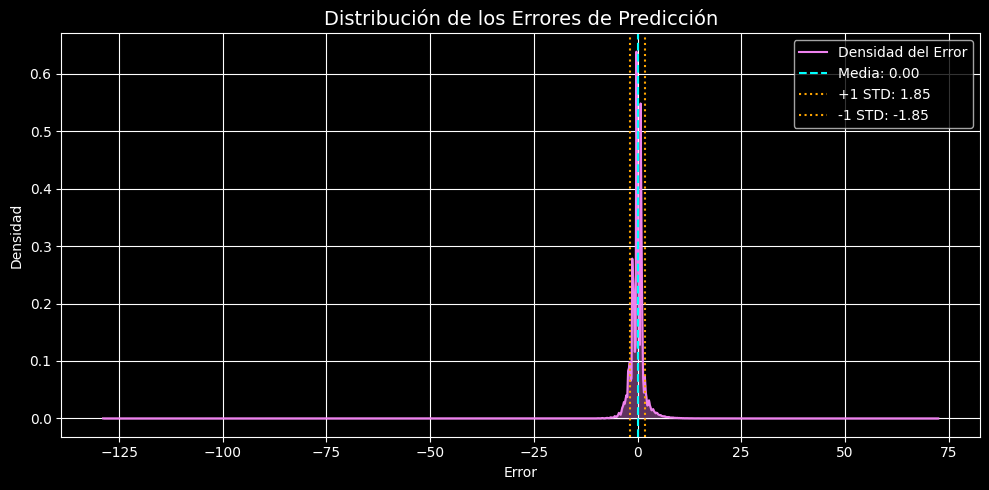

In [173]:
# Calcular los errores
errores = y_predsDTR - y_test

# Estadísticas
media_error = np.mean(errores)
std_error = np.std(errores)

# KDE (curva de densidad)
kde = gaussian_kde(errores)
x_vals = np.linspace(min(errores), max(errores), 1000)
densidad = kde(x_vals)

# Gráfico
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.plot(x_vals, densidad, color='violet', label='Densidad del Error')
plt.fill_between(x_vals, densidad, alpha=0.4, color='violet')

# Líneas de media y desviaciones estándar
plt.axvline(media_error, color='cyan', linestyle='--', label=f'Media: {media_error:.2f}')
plt.axvline(media_error + std_error, color='orange', linestyle=':', label=f'+1 STD: {media_error + std_error:.2f}')
plt.axvline(media_error - std_error, color='orange', linestyle=':', label=f'-1 STD: {media_error - std_error:.2f}')

# Detalles del gráfico
plt.title('Distribución de los Errores de Predicción', fontsize=14)
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


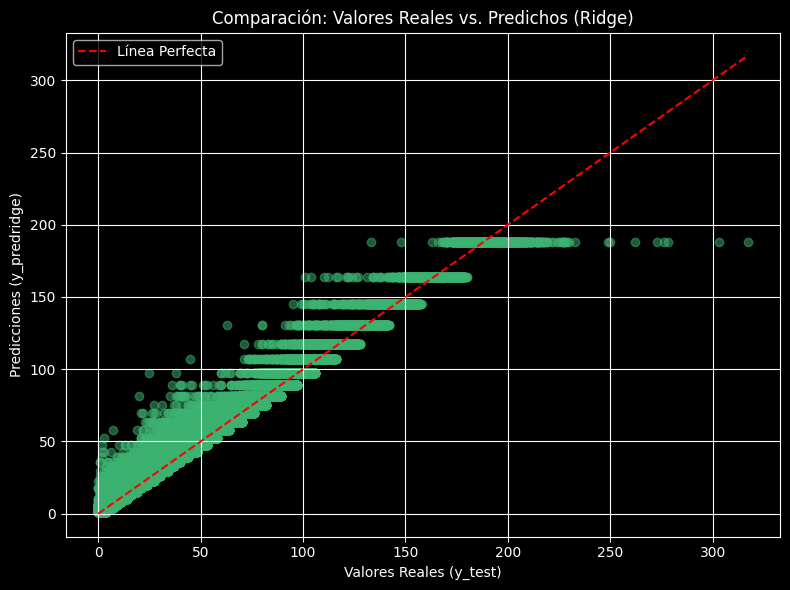

In [174]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predsDTR, color='mediumseagreen', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Perfecta')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_predridge)')
plt.title('Comparación: Valores Reales vs. Predichos (Ridge)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

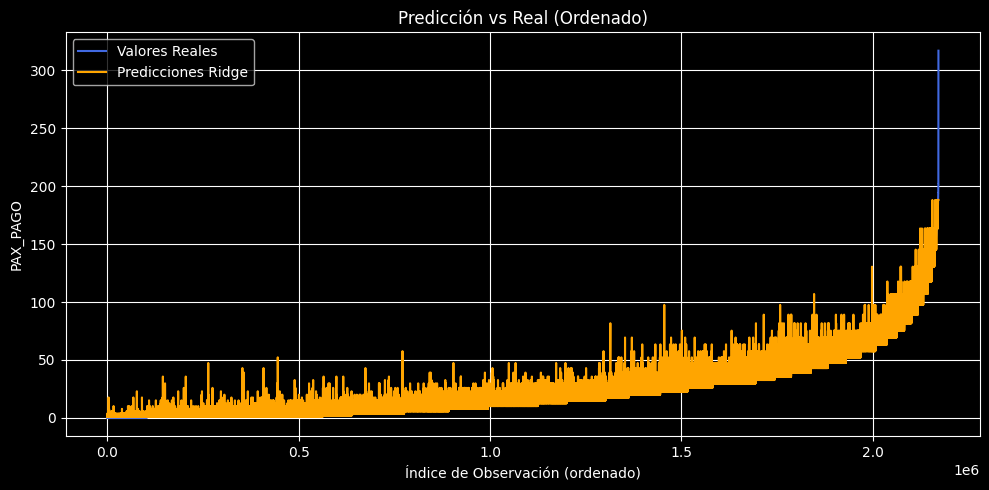

In [175]:
# Ordeno por y_test para que se vean más alineadas las curvas
y_test_sorted = np.array(y_test).flatten()
y_pred_sorted = np.array(y_predsDTR).flatten()
indices = np.argsort(y_test_sorted)

plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted[indices], label='Valores Reales', color='royalblue')
plt.plot(y_pred_sorted[indices], label='Predicciones Ridge', color='orange')
plt.title('Predicción vs Real (Ordenado)')
plt.xlabel('Índice de Observación (ordenado)')
plt.ylabel('PAX_PAGO')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



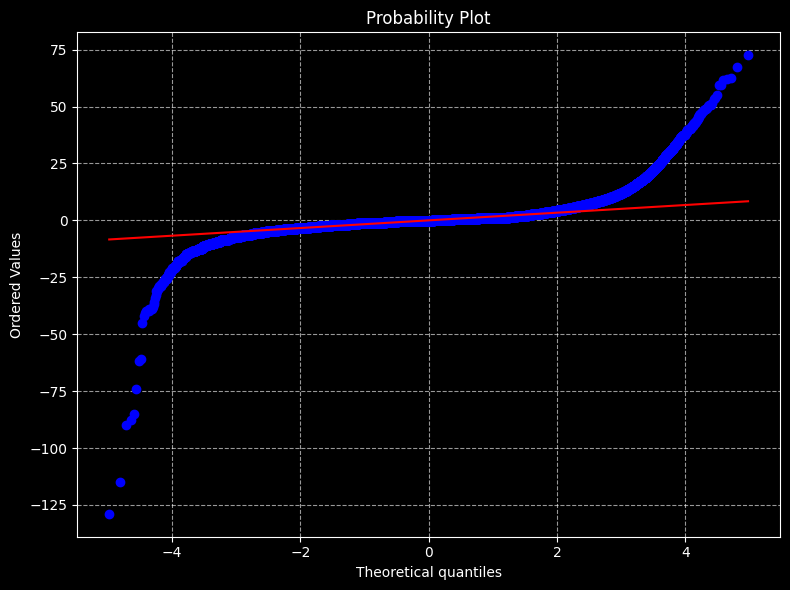

In [176]:
# Cálculo de los errores
errores = y_predsDTR - y_test
errores = np.array(errores).flatten()

# Estilo visual
plt.figure(figsize=(8, 6))
plt.title("Gráfico Q-Q de los Errores (Modelo Ridge)", fontsize=14)
plt.xlabel("Cuantiles Teóricos (Distribución Normal)")
plt.ylabel("Cuantiles Observados (Errores)")
plt.grid(True, linestyle='--', alpha=0.6)

# Q-Q plot mejorado
stats.probplot(errores, dist="norm", plot=plt)

# Ajuste final
plt.tight_layout()
plt.show()

In [177]:

target = "PAX_PAGO"

# Resetear el índice para poder hacer join correctamente
X_test_reset = X_test.reset_index()
y_test_reset = y_test.reset_index()
y_pred_series = pd.Series(y_predsDTR, name='PREDICCION')

# Combinar todo en una sola tabla
tabla_comparacion = pd.concat([y_test_reset, y_pred_series], axis=1)

# Agregar columna de diferencia absoluta
tabla_comparacion['DIFERENCIA'] = abs(tabla_comparacion['PREDICCION'] - tabla_comparacion[target])

# Agregar las columnas de contexto desde X_test
tabla_comparacion['FECHA_NUMERICA'] = X_test_reset['FECHA_NUMERICA']
tabla_comparacion['LINEA_NUMERICA'] = X_test_reset['LINEA_NUMERICA']

# Mostrar solo las primeras 10 filas
print(tabla_comparacion[['PREDICCION', target, 'DIFERENCIA', 'FECHA_NUMERICA', 'LINEA_NUMERICA']].head(10))

   PREDICCION  PAX_PAGO  DIFERENCIA  FECHA_NUMERICA  LINEA_NUMERICA
0   32.686623        33    0.313377        20140108               0
1   10.203430        13    2.796570        20141203               1
2    7.763553         6    1.763553        20140109               0
3   15.125497        16    0.874503        20140117               0
4    0.847022         1    0.152978        20141017               2
5   47.381477        45    2.381477        20140514               3
6   10.203430        10    0.203430        20140521               5
7   10.203430        11    0.796570        20140727               5
8   15.125497        15    0.125497        20140623               4
9    0.847022         3    2.152978        20141220               5


**GRAFICO DE ARBOL DE DECISION**

1.  Se construyó un modelo de regresión usando un Árbol de Decisión con una profundidad máxima definida por maxdepthDTR. 

2. Este parámetro limita cuántos niveles puede crecer el árbol, ayudando a evitar el sobreajuste. 

3. Luego, el modelo se entrenó con los datos escalados de entrenamiento (X_train_scaled, y_train). 

4. Finalmente, se usó para predecir los valores del conjunto de prueba (X_test_scaled).

In [178]:
tree_mod=DecisionTreeRegressor()


In [179]:
tree_mod=DecisionTreeRegressor(max_depth=maxdepthDTR)
tree_mod.fit(X_train_scaled,y_train)

DecisionTreeRegressor(max_depth=5)

In [180]:
y_predsDTR=tree_mod.predict(X_test_scaled)

- El siguiente gráfico muestra la estructura del árbol de decisión entrenado, incluyendo las decisiones tomadas en cada nodo y los valores predichos. 
- Es útil para interpretar cómo el modelo toma decisiones y qué variables son más relevantes.

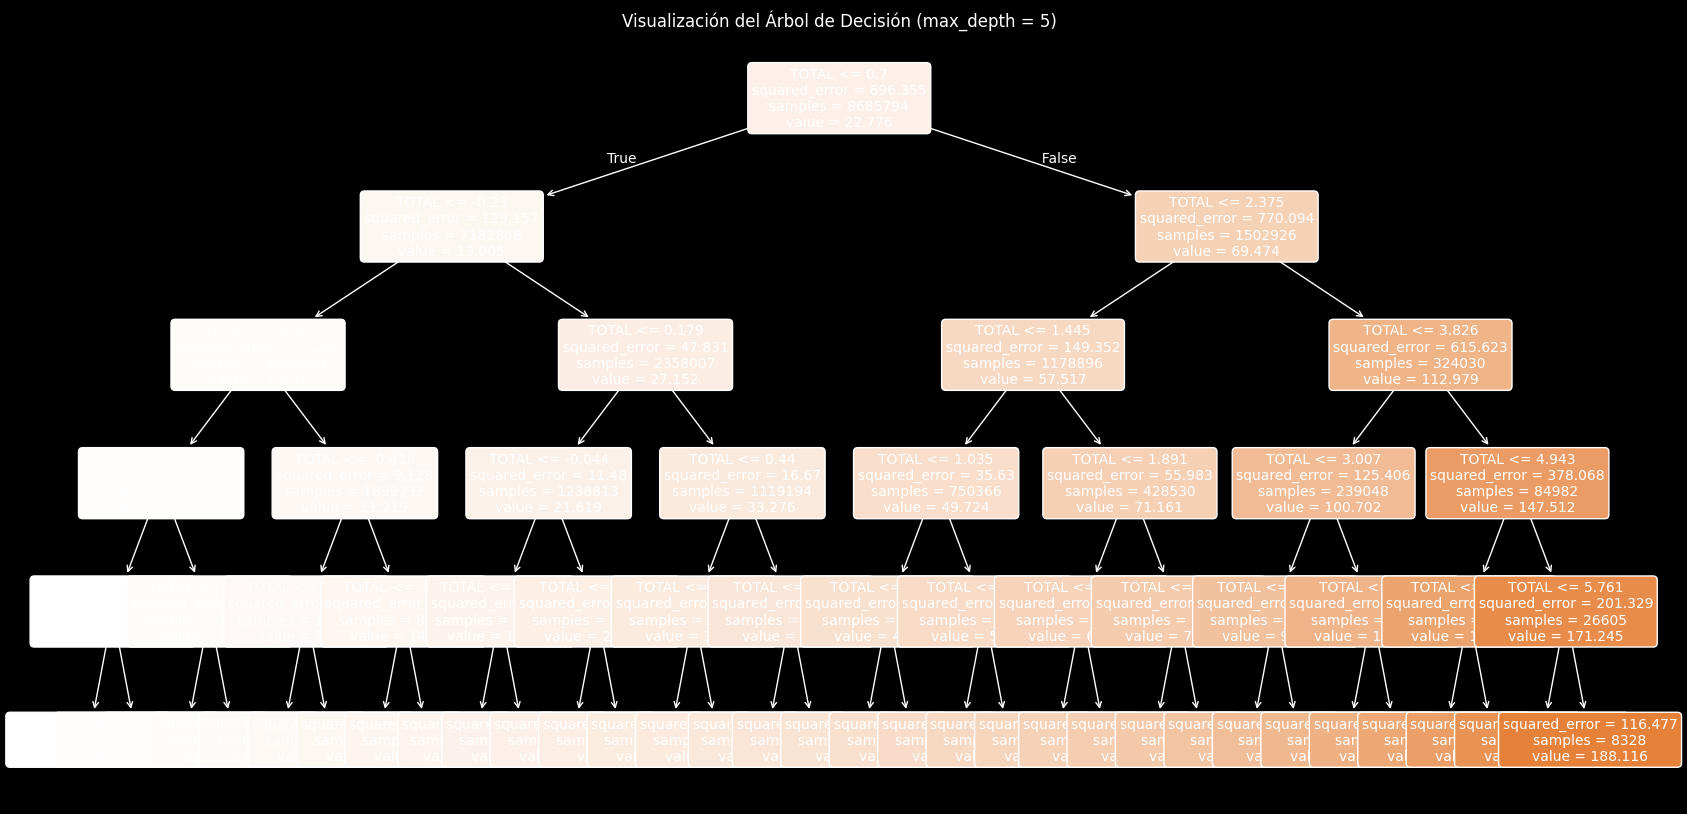

In [181]:

plt.figure(figsize=(20, 10))
plot_tree(tree_mod, 
          filled=True, 
          feature_names=X_train.columns, 
          rounded=True, 
          fontsize=10)

plt.title(f'Visualización del Árbol de Decisión (max_depth = {maxdepthDTR})')
plt.show()

**EL MODELO "DecisionTreeRegressor" FUE BASTANTE EFICIENTE Y PERO NO MUY EXACTO CON SUS PREDICCIONES**

**Conclusión General:**
- El modelo de Árbol de Decisión (DTR) alcanzó un R² de 0.995, lo que indica que explica el 99.5% de la variabilidad de los datos, un valor excelente. 
- Sin embargo, el RMSE de 1.85 muestra que, aunque el ajuste global es muy bueno, el modelo comete errores promedio mayores que otros modelos como Ridge. 
- Esto sugiere que el árbol puede estar capturando bien patrones generales, pero es sensible a pequeñas variaciones, especialmente si la profundidad está limitada. 

- En resumen, DTR es un modelo interpretativo y preciso, aunque podría beneficiarse de un ajuste fino de hiperparámetros o el uso de ensamblados como Random Forest para mejorar la estabilidad.


In [182]:
#from sklearn.svm import SVR

In [183]:
#c = 1

#model=SVR(C=c, kernel='linear')

In [184]:
#model.fit(X_train,y_train)

In [185]:
#y_predsSVR=model.predict(X_test_scaled)

In [186]:
#reg_score=r2_score(y_test,y_predsSVR)
#print(reg_score)

#mse=mean_squared_error(y_test,y_predsSVR)
#print(mse)

#rmse=mse**0.5
#print(rmse*100)


# Modelo : "RandomForestRegressor"

In [187]:
from sklearn.ensemble import RandomForestRegressor

- En el siguiete codigo, defino un modelo predictivo para estimar la cantidad total de pasajeros pagos (TOTAL) utilizando múltiples variables explicativas: estación, línea, fecha, franja horaria (DESDE y HASTA) y molinete.
- Esta selección abarca aspectos espaciales, temporales y operativos del sistema.
- Luego, se dividió el dataset en entrenamiento y prueba en una proporción 80/20 para evaluar el rendimiento generalizado del modelo.


In [188]:
# EN ESTE CASO, VOY A PREDECIR LA CANTIDAD DE PASAJEROS PAGOS (TOTAL DE PASAJEROS) EN FUNCION DE LAS DEMAS VARIABLES.
X_train, X_test, y_train, y_test = train_test_split(dfentrenamiento[['ESTACION_NUMERICA','LINEA_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA','MOLINETE_NUMERICO']], dfentrenamiento['TOTAL'], test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)


(8685794, 6) (2171449, 6) (8685794,) (2171449,)


- En el siguiente codigo, defino el modelo de Random Forest Regressor con una profundidad máxima de max_depth=2, lo que limita la complejidad del árbol y ayuda a evitar el sobreajuste

In [189]:
#INGRESAR EL NUMERO DE PROFUNDIDAD QUE SE DESEA ANALIZAR.
maxdepthRFR = 2

model=RandomForestRegressor(max_depth=maxdepthRFR)
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=2)

- En el siguente codigo, genero las predicciones del modelo Random Forest Regressor en el conjunto de prueba (X_test).

In [190]:
#REALIZO LA PREDICCION
y_predsRFR=model.predict(X_test)

**Metricas de rendmiento.**

- . Se evalúa el rendimiento del modelo entrenado.

In [191]:
reg_score=r2_score(y_test,y_predsRFR)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_predsRFR)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)

R2 (Coeficiente de Determinacion): 0.07542720123718871
MSE (Error Cuadratico Medio): 669.4731098542919
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 25.87417843824789


**GRAFICOS DE VISALIZACION DE RESUTADOS**

- El siguiente codigo calcula los errores de predicción de un modelo (en este caso, una regresión con Random Forest), restando los valores reales (y_test) a las predicciones (y_predsRFR). 
- Luego, grafica la distribución de esos errores usando un gráfico de densidad (KDE) con Seaborn.

El gráfico ayuda a entender si los errores están centrados en cero (lo ideal), si hay sesgos, o si los errores están muy dispersos. Cuanto más estrecha y centrada sea la curva, mejor está funcionando el modelo.


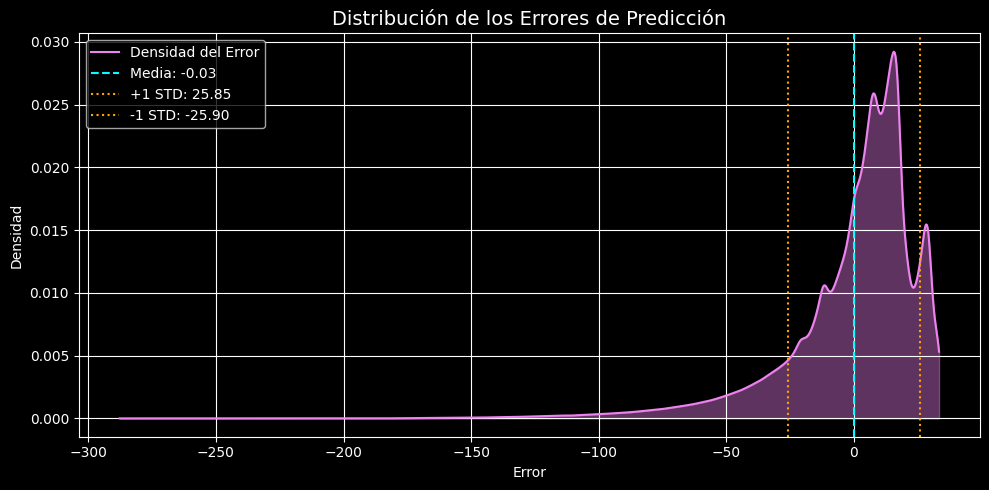

In [192]:
# Calcular los errores
errores = y_predsRFR - y_test

# Estadísticas
media_error = np.mean(errores)
std_error = np.std(errores)

# KDE (curva de densidad)
kde = gaussian_kde(errores)
x_vals = np.linspace(min(errores), max(errores), 1000)
densidad = kde(x_vals)

# Gráfico
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.plot(x_vals, densidad, color='violet', label='Densidad del Error')
plt.fill_between(x_vals, densidad, alpha=0.4, color='violet')

# Líneas de media y desviaciones estándar
plt.axvline(media_error, color='cyan', linestyle='--', label=f'Media: {media_error:.2f}')
plt.axvline(media_error + std_error, color='orange', linestyle=':', label=f'+1 STD: {media_error + std_error:.2f}')
plt.axvline(media_error - std_error, color='orange', linestyle=':', label=f'-1 STD: {media_error - std_error:.2f}')

# Detalles del gráfico
plt.title('Distribución de los Errores de Predicción', fontsize=14)
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



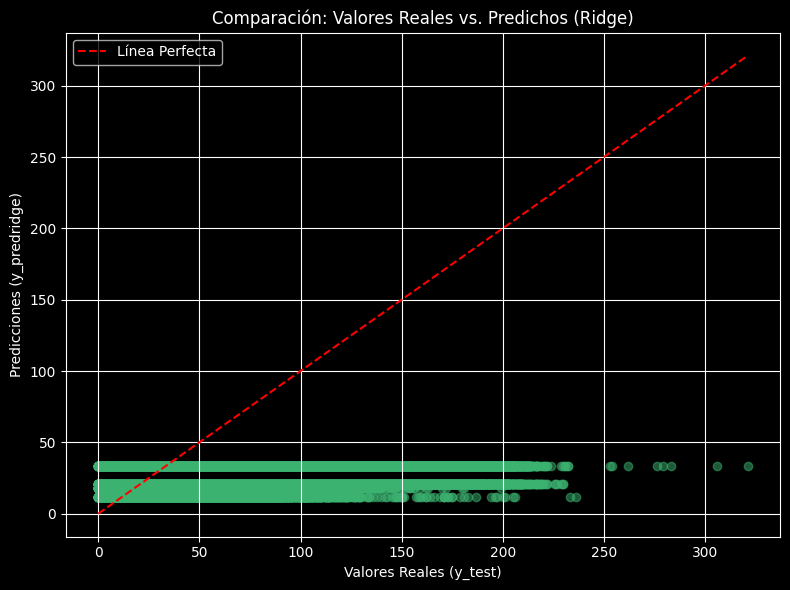

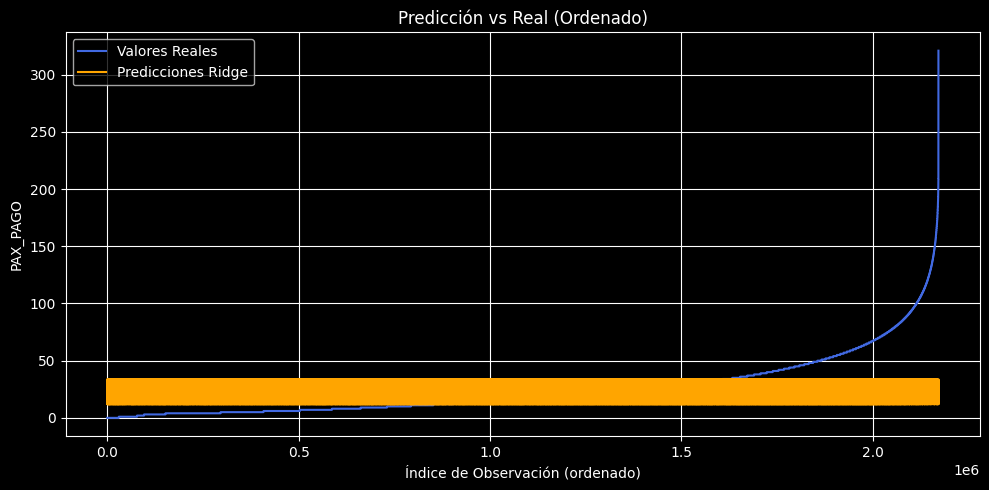

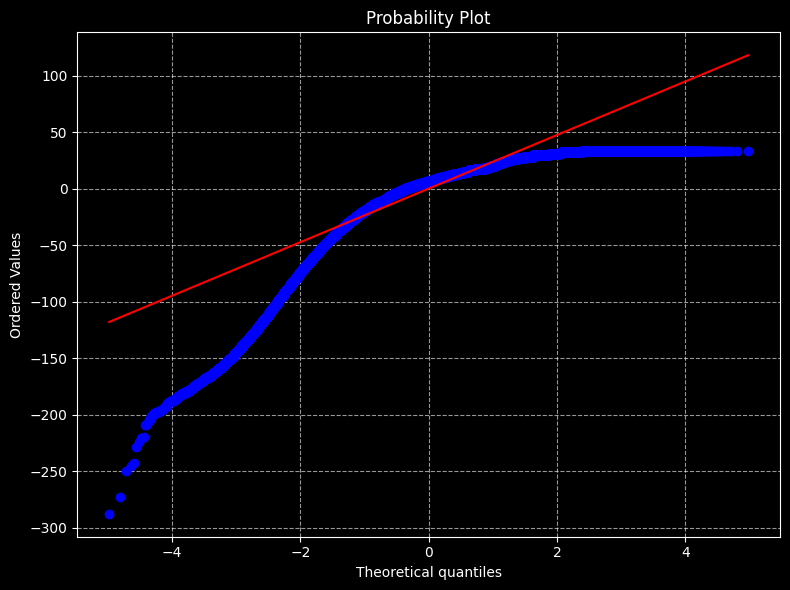

In [193]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predsRFR, color='mediumseagreen', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Perfecta')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_predridge)')
plt.title('Comparación: Valores Reales vs. Predichos (Ridge)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Ordeno por y_test para que se vean más alineadas las curvas
y_test_sorted = np.array(y_test).flatten()
y_pred_sorted = np.array(y_predsRFR).flatten()
indices = np.argsort(y_test_sorted)

plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted[indices], label='Valores Reales', color='royalblue')
plt.plot(y_pred_sorted[indices], label='Predicciones Ridge', color='orange')
plt.title('Predicción vs Real (Ordenado)')
plt.xlabel('Índice de Observación (ordenado)')
plt.ylabel('PAX_PAGO')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Cálculo de los errores
errores = y_predsRFR - y_test
errores = np.array(errores).flatten()

# Estilo visual
plt.figure(figsize=(8, 6))
plt.title("Gráfico Q-Q de los Errores (Modelo Ridge)", fontsize=14)
plt.xlabel("Cuantiles Teóricos (Distribución Normal)")
plt.ylabel("Cuantiles Observados (Errores)")
plt.grid(True, linestyle='--', alpha=0.6)

# Q-Q plot mejorado
stats.probplot(errores, dist="norm", plot=plt)

# Ajuste final
plt.tight_layout()
plt.show()



In [194]:
target = "TOTAL"

# Resetear el índice para poder hacer join correctamente
X_test_reset = X_test.reset_index()
y_test_reset = y_test.reset_index()
y_pred_series = pd.Series(y_predsRFR, name='PREDICCION')

# Combinar todo en una sola tabla
tabla_comparacion = pd.concat([y_test_reset, y_pred_series], axis=1)

# Agregar columna de diferencia absoluta
tabla_comparacion['DIFERENCIA'] = abs(tabla_comparacion['PREDICCION'] - tabla_comparacion[target])

# Agregar las columnas de contexto desde X_test
tabla_comparacion['FECHA_NUMERICA'] = X_test_reset['FECHA_NUMERICA']
tabla_comparacion['LINEA_NUMERICA'] = X_test_reset['LINEA_NUMERICA']

# Mostrar solo las primeras 10 filas
print(tabla_comparacion[['PREDICCION', target, 'DIFERENCIA', 'FECHA_NUMERICA', 'LINEA_NUMERICA']].head(10))

   PREDICCION  TOTAL  DIFERENCIA  FECHA_NUMERICA  LINEA_NUMERICA
0   33.328897     36    2.671103        20140108               0
1   33.328897     14   19.328897        20141203               1
2   33.328897     11   22.328897        20140109               0
3   33.328897     19   14.328897        20140117               0
4   33.328897      4   29.328897        20141017               2
5   21.095451     49   27.904549        20140514               3
6   21.095451     12    9.095451        20140521               5
7   21.095451     14    7.095451        20140727               5
8   21.095451     17    4.095451        20140623               4
9   21.095451      4   17.095451        20141220               5


**EL MODELO "RandomForestRegressor" FUE BASTANTE INEFICIENTE Y NO MUY EXACTO CON SUS PREDICCIONES**

**Conclusión General:**

El modelo Random Forest Regressor con una profundidad máxima de 2 ha mostrado un rendimiento limitado:
1.	R² = 0.075: Este valor indica que el modelo solo explica el 7.5% de la variabilidad de los datos. 
- Esto sugiere que el modelo no está capturando bien la relación entre las variables explicativas y la cantidad total de pasajeros, lo que podría indicar que la relación es más compleja o que el modelo necesita más profundidad o mayor cantidad de árboles para mejorar su ajuste.
2.	MSE = 669.47 y RMSE = 25.87: Estos valores son relativamente altos, lo que significa que el modelo tiene un error significativo en sus predicciones. 
- Esto puede ser normal si el modelo es demasiado simple o si hay muchas variaciones no capturadas por las variables actuales.

Posibles mejoras:
- •	Ajustar la profundidad del árbol (max_depth): Un valor de 2 es bastante limitado. 
- Aumentar este parámetro podría permitir que el modelo capture relaciones más complejas.
- •	Aumentar el número de árboles: Usar más árboles en el Random Forest puede mejorar la precisión general.
- •	Incluir más características: Incorporar variables adicionales, como eventos especiales, clima o patrones históricos de tráfico, podría mejorar el rendimiento.
- •	Validación cruzada: Probar con validación cruzada para asegurarse de que los resultados sean robustos.

**EL MODELO RandomForestRegressor NO FUE EFICIENTE Y ES BASTANTE INEXACTO CON SUS PREDICCIONES**

# Modelo : "XGBRFRegressor".

In [195]:

import xgboost as xgb
from xgboost import XGBRegressor


- En el siguiente codigo, genero un modelo XGBRFRegressor, que combina la robustez de los Random Forests con la eficiencia de XGBoost, aplicando mejoras en la regularización y selección de atributos.

- Detalles del modelo que estás definiendo:
1. • 	n_estimators=100: Se usarán 100 árboles de aprendizaje.
2. •	learning_rate=0.1: Controla el ritmo al que el modelo aprende.
3. •	max_depth=3: Árboles poco profundos, que ayudan a evitar sobreajuste pero pueden limitar la complejidad.
4. •	objective='reg:squarederror': Especifica una función de pérdida para regresión.


In [196]:

X_train, X_test, y_train, y_test = train_test_split(dfentrenamiento[['ESTACION_NUMERICA','LINEA_NUMERICA','FECHA_NUMERICA','DESDE_NUMERICA','HASTA_NUMERICA','MOLINETE_NUMERICO']], dfentrenamiento['TOTAL'], test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(8685794, 6) (2171449, 6) (8685794,) (2171449,)


In [197]:
#INGRESAR EL NUMERO DE ESTIMADORES,QUE SE DESEA ANALIZAR.
estimatorsXGBRFR = 100
#INGRESAR EL LEARNING RATE,QUE SE DESEA ANALIZAR.
learningXGBRFR = 0.1
#INGRESAR EL MAX DE PROFUNDIDAD,QUE SE DESEA ANALIZAR.
maxdepthXGRRFR = 3

model_xgbRFR = xgb.XGBRFRegressor(objective='reg:squarederror',
                                  n_estimators=estimatorsXGBRFR,
                                  learning_rate=learningXGBRFR,
                                  max_depth=maxdepthXGRRFR)



- En el siguiente codigo, entreno el modelo XGBRFRegressor con los datos de entrenamiento. 

In [198]:
model_xgbRFR.fit(X_train,y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror', ...)

- Genero las predicciones de los datos.

In [199]:
#REALIZO LA PREDICCION
y_predsXGBRFR=model_xgbRFR.predict(X_test)

**Metricas de rendmiento.**

- . Se evalúa el rendimiento del modelo entrenado.

In [200]:
reg_score=r2_score(y_test,y_predsXGBRFR)
print('R2 (Coeficiente de Determinacion):', reg_score)

mse=mean_squared_error(y_test,y_predsXGBRFR)
print('MSE (Error Cuadratico Medio):', mse)

rmse=mse**0.5
print('RMSE (Raiz Cuadrada del Error Cuadratico Medio):', rmse)


R2 (Coeficiente de Determinacion): 0.020235896110534668
MSE (Error Cuadratico Medio): 709.4366455078125
RMSE (Raiz Cuadrada del Error Cuadratico Medio): 26.635251932501266


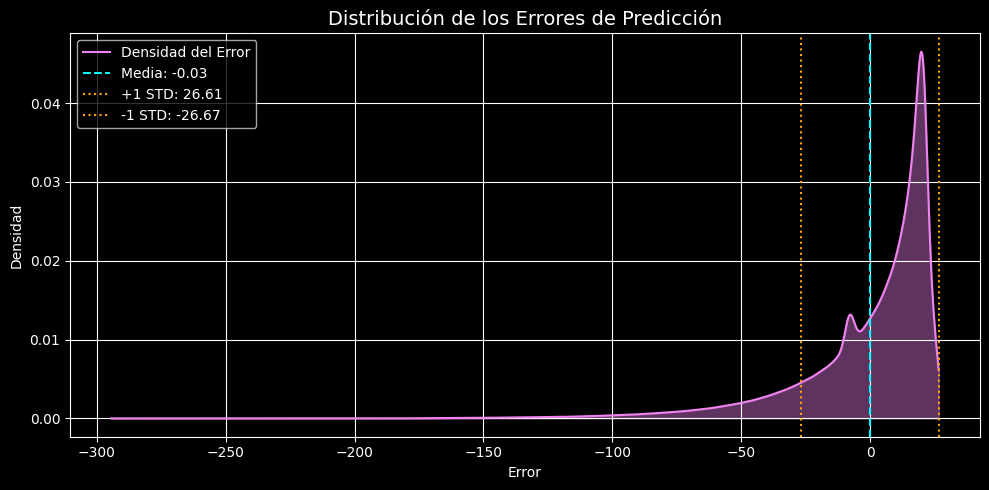

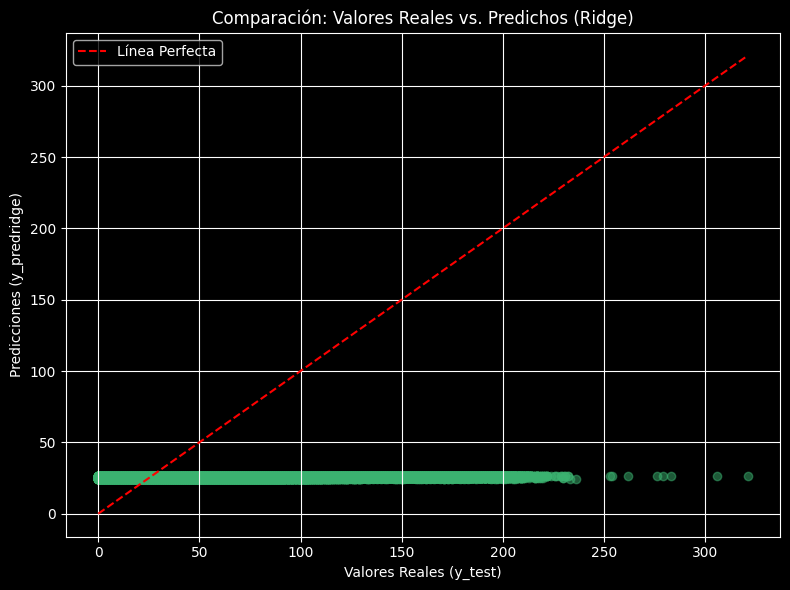

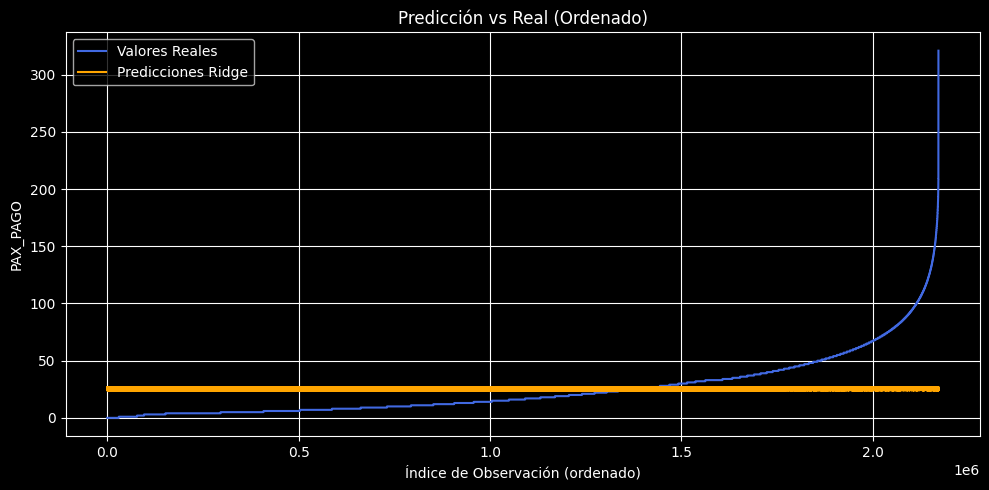

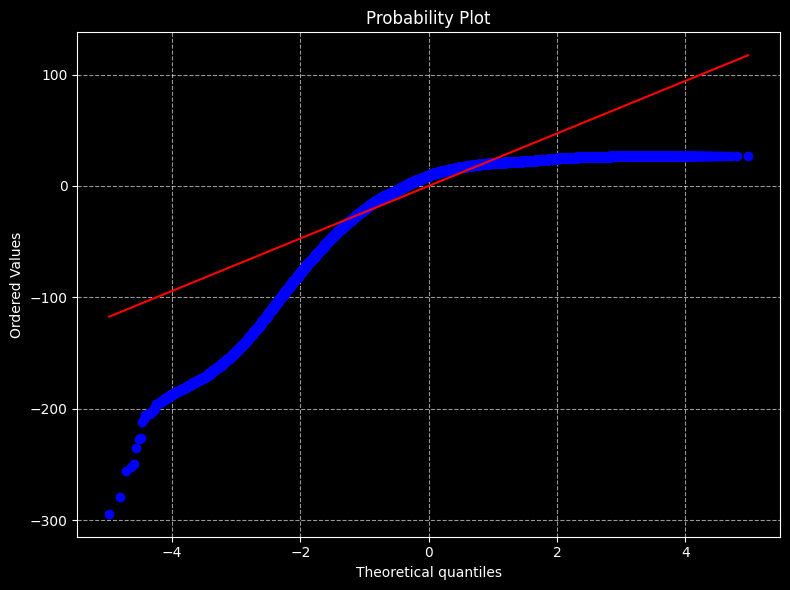

In [201]:
# Calcular los errores
errores = y_predsXGBRFR - y_test

# Estadísticas
media_error = np.mean(errores)
std_error = np.std(errores)

# KDE (curva de densidad)
kde = gaussian_kde(errores)
x_vals = np.linspace(min(errores), max(errores), 1000)
densidad = kde(x_vals)

# Gráfico
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.plot(x_vals, densidad, color='violet', label='Densidad del Error')
plt.fill_between(x_vals, densidad, alpha=0.4, color='violet')

# Líneas de media y desviaciones estándar
plt.axvline(media_error, color='cyan', linestyle='--', label=f'Media: {media_error:.2f}')
plt.axvline(media_error + std_error, color='orange', linestyle=':', label=f'+1 STD: {media_error + std_error:.2f}')
plt.axvline(media_error - std_error, color='orange', linestyle=':', label=f'-1 STD: {media_error - std_error:.2f}')

# Detalles del gráfico
plt.title('Distribución de los Errores de Predicción', fontsize=14)
plt.xlabel('Error')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predsXGBRFR, color='mediumseagreen', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Línea Perfecta')
plt.xlabel('Valores Reales (y_test)')
plt.ylabel('Predicciones (y_predridge)')
plt.title('Comparación: Valores Reales vs. Predichos (Ridge)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Ordeno por y_test para que se vean más alineadas las curvas
y_test_sorted = np.array(y_test).flatten()
y_pred_sorted = np.array(y_predsXGBRFR).flatten()
indices = np.argsort(y_test_sorted)

plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted[indices], label='Valores Reales', color='royalblue')
plt.plot(y_pred_sorted[indices], label='Predicciones Ridge', color='orange')
plt.title('Predicción vs Real (Ordenado)')
plt.xlabel('Índice de Observación (ordenado)')
plt.ylabel('PAX_PAGO')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Cálculo de los errores
errores = y_predsXGBRFR - y_test
errores = np.array(errores).flatten()

# Estilo visual
plt.figure(figsize=(8, 6))
plt.title("Gráfico Q-Q de los Errores (Modelo Ridge)", fontsize=14)
plt.xlabel("Cuantiles Teóricos (Distribución Normal)")
plt.ylabel("Cuantiles Observados (Errores)")
plt.grid(True, linestyle='--', alpha=0.6)

# Q-Q plot mejorado
stats.probplot(errores, dist="norm", plot=plt)

# Ajuste final
plt.tight_layout()
plt.show()




In [202]:
target = "TOTAL"

# Resetear el índice para poder hacer join correctamente
X_test_reset = X_test.reset_index()
y_test_reset = y_test.reset_index()
y_pred_series = pd.Series(y_predsXGBRFR, name='PREDICCION')

# Combinar todo en una sola tabla
tabla_comparacion = pd.concat([y_test_reset, y_pred_series], axis=1)

# Agregar columna de diferencia absoluta
tabla_comparacion['DIFERENCIA'] = abs(tabla_comparacion['PREDICCION'] - tabla_comparacion[target])

# Agregar las columnas de contexto desde X_test
tabla_comparacion['FECHA_NUMERICA'] = X_test_reset['FECHA_NUMERICA']
tabla_comparacion['LINEA_NUMERICA'] = X_test_reset['LINEA_NUMERICA']

# Mostrar solo las primeras 10 filas
print(tabla_comparacion[['PREDICCION', target, 'DIFERENCIA', 'FECHA_NUMERICA', 'LINEA_NUMERICA']].head(10))

   PREDICCION  TOTAL  DIFERENCIA  FECHA_NUMERICA  LINEA_NUMERICA
0   26.606853     36    9.393147        20140108               0
1   26.404705     14   12.404705        20141203               1
2   26.606853     11   15.606853        20140109               0
3   26.621990     19    7.621990        20140117               0
4   24.956715      4   20.956715        20141017               2
5   25.272665     49   23.727335        20140514               3
6   25.272665     12   13.272665        20140521               5
7   25.316408     14   11.316408        20140727               5
8   25.272665     17    8.272665        20140623               4
9   25.272665      4   21.272665        20141220               5


**Conclusión General:**

- El modelo XGBRFRegressor, configurado con 100 estimadores, learning rate de 0.1 y profundidad máxima de 3, mostró un rendimiento muy bajo al predecir la cantidad total de pasajeros:

⸻

**Conclusión General:**

- •	R² = 0.0202: El modelo solo explica el 2% de la variabilidad de los datos. Es decir, su capacidad explicativa es muy limitada, apenas mejor que una predicción constante con la media.
- •	MSE = 709.44 y RMSE ≈ 26.63: Indican un error considerable en las predicciones, mayor incluso que el modelo de Ridge o DTR.

- Posibles causas y sugerencias:
- •	Profundidad baja (max_depth=3): Puede estar limitando demasiado la capacidad del modelo para aprender relaciones complejas.
- •	XGBRFRegressor vs XGBRegressor: Este modelo se comporta como un Random Forest, no como un boosted tree, por lo que no se beneficia del aprendizaje secuencial. Tal vez quieras probar con XGBRegressor, que suele ofrecer mejores resultados en tareas de regresión.
- •	Variables predictoras: Podrían no contener suficiente información para estimar el total de pasajeros con precisión. Sería útil explorar nuevas variables o transformaciones.


**PARA ESTE CASO EN PARTICULAR Y CON LOS PARAMETROS UTILIZADOS, EL MODELO XGBRFRegressor NO FUE EFICIENTE Y ES BASTANTE INEXACTO CON SUS PREDICCIONES**